#Introduction

This project builds a Snowflake-based data pipeline for analyzing the ICC Cricket World Cup data.  
It demonstrates how to load JSON data into Snowflake, transform it into clean tables, and run analytical queries. This dataset was from a youtube channel Data Engineering Simplified.

These are the following steps in order to finish the project:
1. How to load data from location machine to Snowflake stage location.(Small JSON files as well as many JSON files at on go).
2. How to load delta data set from local machine to internal stages?
3. How to use $ notation to query stage file?
4. How to run copy command to load JSON files into tables?
5. How to design different layers & fact/dimension tables?

First Step is to determine what's inside the JSON file for the Cricket data

1. Meta 
2. Info
3. Innings

These data shows what's inside the data of ICC Cricket World Cup Data. These data will also help us to create the necessary Schema, Database, Fact Table and etc to be use

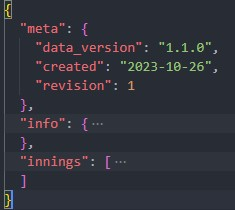


In [ ]:
--After analyzing the data for the dataset, we can start on making Database and Schema for the data
--All of this Shema and Database can be viewed on a DBeaver Application
--SCHEMA CREATION

USE ROLE sysadmin;          --select role
use warehouse compute_wh;   --select compute

--create a database called cricket and 4 schema 

CREATE DATABASE IF NOT EXISTS cricket
CREATE OR REPLACE SCHEMA cricket.land;
CREATE OR REPLACE SCHEMA cricket.raw;
CREATE OR REPLACE SCHEMA cricket.clean;
CREATE OR REPLACE SCHEMA cricket.consumption;

show schemas in database cricket;
--change context
USE SCHEMA cricket.land;

--json file format
CREATE OR REPLACE FILE FORMAT cricket.land.my_json_format
    TYPE = json
    null_if = ('\\n', 'null', '')
    strip_outer_array = true
    comment = 'Json FIle Fromat with outer strip array flag true';

--creating an internal stage
CREATE OR REPLACE STAGE cricket.land.my_stg;

--lets list the internal stage
list @cricket.land.my_stg;

-- check if data is being loaded or not
list @my_stg/cricket/json/;

--quick check if data is coming correctly or not
SELECT
    t.$1:meta::variant as meta,
    t.$1:info::variant as info,
    t.$1:innings::array as innings,
    metadata$filename as file_name,
    metadata$file_row_number int,
    metadata$file_content_key text,
    metadata$file_last_modified stg_modified_ts
FROM @my_stg/cricket/json/1384401.json (file_format => 'my_json_format') t;



In [ ]:
--After creating Database and Schema, we need to create or replace a table for raw data
--CRICKET.RAW

USE ROLE SYSADMIN;
USE WAREHOUSE COMPUTE_WH;
USE SCHEMA CRICKET.RAW;



-- CREATE A TABLE INSIDE THE RAW LAYER
CREATE OR REPLACE transient table cricket.raw.match_raw_tbl(
        meta OBJECT NOT NULL,
        info VARIANT NOT NULL,
        innings ARRAY NOT NULL,
        stg_file_name TEXT NOT NULL,
        stg_file_row_number INT NOT NULL,
        stg_file_hashkey TEXT NOT NULL,
        stg_modified_ts TIMESTAMP NOT NULL
)
comment = 'This is raw table to store all the json data file with root elements extracted';

--Copying the data into cricket.raw.match_raw_tbl

COPY INTO cricket.raw.match_raw_tbl FROM
    (
    SELECT
        t.$1:meta::object as meta,
        t.$1:info::variant as info,
        t.$1:innings::array as innings,
        --CRICKET.LAND.MY_STG
        metadata$filename,
        metadata$file_row_number,
        metadata$file_content_key,
        metadata$file_last_modified
    FROM @cricket.land.my_stg/cricket/json/ (file_format => 'cricket.land.my_json_format') t   
    )
    on_error = continue;
    


In [ ]:
--Next step is for the cleanzone, this is for the cleaning of the data for the neccessary/correct formatting to be use for analysis
--CLEAN ZONE
USE ROLE SYSADMIN;
USE WAREHOUSE COMPUTE_WH;
USE SCHEMA CRICKET.CLEAN;

--step 1
--the meta colum has no real domain value and it just capture the JSON file version, since it is an object data type
--here is the select statement that can extract each element
--extract element from object data type

SELECT 
    meta['data_version']::text as data_version,
    meta['created']::date as created,
    meta['revision']::number as revision
FROM
    cricket.raw.match_raw_tbl

--step 2 
--extract elements from info column that is of variant data type
--it has lot of important infomartion... and need to analyze them

create or replace transient table cricket.clean.match_detail_clean as
select
    info:match_type_number::int as match_type_number, 
    info:event.name::text as event_name,
    case
    when 
        info:event.match_number::text is not null then info:event.match_number::text
    when 
        info:event.stage::text is not null then info:event.stage::text
    else
        'NA'
    end as match_stage,   
    info:dates[0]::date as event_date,
    date_part('year',info:dates[0]::date) as event_year,
    date_part('month',info:dates[0]::date) as event_month,
    date_part('day',info:dates[0]::date) as event_day,
    info:match_type::text as match_type,
    info:season::text as season,
    info:team_type::text as team_type,
    info:overs::text as overs,
    info:city::text as city,
    info:venue::text as venue, 
    info:gender::text as gender,
    info:teams[0]::text as first_team,
    info:teams[1]::text as second_team,
    case 
        when info:outcome.winner is not null then 'Result Declared'
        when info:outcome.result = 'tie' then 'Tie'
        when info:outcome.result = 'no result' then 'No Result'
        else info:outcome.result
    end as matach_result,
    case 
        when info:outcome.winner is not null then info:outcome.winner
        else 'NA'
    end as winner,   

    info:toss.winner::text as toss_winner,
    initcap(info:toss.decision::text) as toss_decision,
    --
    stg_file_name ,
    stg_file_row_number,
    stg_file_hashkey,
    stg_modified_ts
    from 
    cricket.raw.match_raw_tbl;



In [ ]:
--Additional Cleaning of data with validation of it to ensure quality of the data
--CLEAN ZONE 2

USE ROLE SYSADMIN;
USE WAREHOUSE COMPUTE_WH;
USE SCHEMA CRICKET.CLEAN;

--extract players
--version-1

SELECT  
    raw.info:match_type_number::int as match_type_number,
    raw.info:players,
    raw.info:teams
FROM cricket.raw.match_raw_tbl as raw

--version-2
SELECT
    raw.info:match_type_number::int as match_type_number,
    raw.info:players,
    raw.info:teams
FROM cricket.raw.match_raw_tbl as raw
WHERE match_type_number = 4668;

--version-3
SELECT
    raw.info:match_type_number::int as match_type_number,
    p.key::text as country
FROM cricket.raw.match_raw_tbl as raw ,
LATERAL FLATTEN(input => raw.info:players) p
WHERE match_type_number = 4668;

--version-4
SELECT
    raw.info:match_type_number::int as match_type_number,
    p.key::text as country,
    team.value::text as player_name
FROM cricket.raw.match_raw_tbl as raw ,
LATERAL FLATTEN(input => raw.info:players) as p,
LATERAL FLATTEN(input => p.value) as team
WHERE match_type_number = 4668; 

--version-5_
CREATE OR REPLACE TABLE cricket.clean.player_clean_tbl AS
SELECT
    raw.info:match_type_number::int as match_type_number,
    p.key::text as country,
    team.value::text as player_name,
    stg_file_name,
    stg_file_row_number,
    stg_file_hashkey,
    stg_modified_ts
FROM cricket.raw.match_raw_tbl as raw ,
LATERAL FLATTEN(input => raw.info:players) as p,
LATERAL FLATTEN(input => p.value) as team

ALTER TABLE cricket.clean.player_clean_tbl
MODIFY COLUMN match_type_number SET NOT NULL;

ALTER TABLE cricket.clean.player_clean_tbl
MODIFY COLUMN country SET NOT NULL;

ALTER TABLE cricket.clean.player_clean_tbl
MODIFY COLUMN player_name SET NOT NULL;

ALTER TABLE cricket.clean.match_detail_clean
ADD CONSTRAINT pk_match_type_number PRIMARY KEY (match_type_number);

ALTER TABLE cricket.clean.player_clean_tbl
ADD CONSTRAINT fk_match_id
FOREIGN KEY (match_type_number)
REFERENCES cricket.clean.match_detail_clean(match_type_number);

select get_ddl('table','cricket.clean.player_clean_tbl')
SELECT *
FROM cricket.clean.player_clean_tbl

In [ ]:
--CLEAN ZONE 3

USE ROLE SYSADMIN;
USE WAREHOUSE COMPUTE_WH;
USE SCHEMA CRICKET.CLEAN;

--version 1 
--lets extract the elements from the innings array
SELECT 
    m.info:match_type_number::int as match_type_number,
    m.innings
FROM cricket.raw.match_raw_tbl as m
WHERE match_type_number = 4668;

--v2
SELECT 
    m.info:match_type_number::int as match_type_number,
    i.value:team::text as team_name,
    i.*
FROM cricket.raw.match_raw_tbl as m,
lateral flatten(input =>m.innings) i
WHERE match_type_number = 4668;

--v3
SELECT 
    m.info:match_type_number::int as match_type_number,
    i.value:team::text as team_name,
    o.*
FROM cricket.raw.match_raw_tbl as m,
lateral flatten(input =>m.innings) i,
lateral flatten(input =>i.value:overs) o,
lateral flatten(input =>o.value:deliveries) d
WHERE match_type_number = 4668;


-v3

select 
    m.info:match_type_number::int as match_type_number, 
    i.value:team::text as country,
    o.value:over::int as over,
    d.value:bowler::text as bowler,
    d.value:batter::text as batter,
    d.value:non_striker::text as non_striker,
    d.value:runs.batter::text as runs,
    d.value:runs.extras::text as extras,
    d.value:runs.total::text as total,
    e.value::number as extra_runs
    
from cricket.raw.match_raw_tbl m,
lateral flatten (input => m.innings) i,
lateral flatten (input => i.value:overs) o,
lateral flatten (input => o.value:deliveries) d,
lateral flatten (input => d.value:extras, outer => True) e

-v4

create or replace table delivery_clean_tbl as
select 
    m.info:match_type_number::int as match_type_number, 
    i.value:team::text as team_name,
    o.value:over::int as over,
    d.value:bowler::text as bowler,
    d.value:batter::text as batter,
    d.value:non_striker::text as non_striker,
    d.value:runs.batter::text as runs,
    d.value:runs.extras::text as extras,
    d.value:runs.total::text as total,
    e.key::text as extra_type,
    e.value::number as extra_runs,
    w.value:player_out::text as player_out,
    w.value:kind::text as player_out_kind,
    w.value:filders::variant as player_out_fielders,
    m.stg_file_name,
    m.stg_file_row_number,
    m.stg_file_hashkey,
    m.stg_modified_ts
    
from cricket.raw.match_raw_tbl m,
lateral flatten (input => m.innings) i,
lateral flatten (input => i.value:overs) o,
lateral flatten (input => o.value:deliveries) d,
lateral flatten (input => d.value:extras, outer => True) e,
lateral flatten (input => d.value:wickets, outer => True) w


DESC TABLE cricket.clean.delivery_clean_tbl

ALTER TABLE cricket.clean.delivery_clean_tbl
MODIFY COLUMN match_type_number SET NOT NULL;

ALTER TABLE cricket.clean.delivery_clean_tbl
MODIFY COLUMN team_name SET NOT NULL;

ALTER TABLE cricket.clean.delivery_clean_tbl
MODIFY COLUMN over SET NOT NULL;

ALTER TABLE cricket.clean.delivery_clean_tbl
MODIFY COLUMN bowler SET NOT NULL;

ALTER TABLE cricket.clean.delivery_clean_tbl
MODIFY COLUMN batter SET NOT NULL;

ALTER TABLE cricket.clean.delivery_clean_tbl
MODIFY COLUMN batter SET NOT NULL;

ALTER TABLE cricket.clean.delivery_clean_tbl
MODIFY COLUMN non_striker SET NOT NULL;


--fk relationship
ALTER TABLE cricket.clean.delivery_clean_tbl
ADD CONSTRAINT fk_delivery_match_id
FOREIGN KEY (match_type_number) 
REFERENCES CRICKET.CLEAN.MATCH_DETAIL_CLEAN (match_type_number);

select get_ddl('table', 'cricket.clean.delivery_clean_tbl' )

In [ ]:
--DATA QUALITY

--lets quickly validate the data set
--India vs England (2023-oct-29)

select team_name, batter, sum(runs)
FROM DELIVERY_CLEAN_TBL
WHERE match_type_number = 4668
group by team_name, batter
order by sum(runs) DESC




In [ ]:
--Creating a DIM table for the relationship of schemas
--FACT DIM TABLE

USE ROLE SYSADMIN;
USE WAREHOUSE COMPUTE_WH;
USE SCHEMA CRICKET.CONSUMPTION;

CREATE OR REPLACE TABLE date_dim(
    date_id int PRIMARY KEY autoincrement,
    full_dt date,
    day int,
    month int,
    year int,
    quarter int,
    dayofweek int,
    dayofmonth int,
    dayofyear int,
    dayofweekname varchar(3), -- to store day names (e.g., "Mon")
    isweekend boolean -- to indicate if it's a weekend(True/false Sat both falls under weekend)
);


--match_references,reserve_umpires, tv_umpires, filed_umpires
CREATE OR REPLACE TABLE referee_dim(
    referee_id INT PRIMARY KEY AUTOINCREMENT,
    referee_name text not null,
    referee_type text not null
);

--India, Australia..


create or replace table team_dim (
    team_id int primary key autoincrement,
    team_name text not null
);

-- player..
create or replace table player_dim (
    player_id int primary key autoincrement,
    team_id int not null,
    player_name text not null
);

alter table cricket.consumption.player_dim
add constraint fk_team_player_id
foreign key (team_id)
references cricket.consumption.team_dim (team_id);


CREATE OR REPLACE TABLE venue_dim(
    venue_id INT PRIMARY KEY AUTOINCREMENT,
    venue_name TEXT NOT NULL,
    city TEXT NOT NULL,
    state text,
    country text,
    continent text,
    end_names text,
    capacity number,
    pitch text,
    flood_light boolean,
    established_dt date,
    playing_area text,
    other_sports text,
    curator text,
    lattitude number(10,6),
    longitude number(10,6)
);

CREATE OR REPLACE TABLE match_type_dim(
    match_type_id INT PRIMARY KEY AUTOINCREMENT,
    match_type TEXT NOT NULL
)


CREATE OR REPLACE TABLE match_fact(
    match_id INT PRIMARY KEY AUTOINCREMENT,
    date_id INT NOT NULL,
    referee_id INT NOT NULL,
    team_a_id INT NOT NULL,
    team_b_id INT NOT NULL,
    match_type_id INT NOT NULL,
    venue_id INT NOT NULL,
    total_overs number(3),
    balls_per_over number(1),
    overs_played_by_team_a number(2),
    bowls_played_by_team_a number(3),
    extra_bowls_played_by_team_a number(3),
    extra_runs_scored_by_team_a number(3),
    fours_by_team_a number(3),
    sixes_by_team_a number(3),
    total_score_by_team_a number(3),
    wicket_lost_by_team_a number(2),

    overs_played_by_team_b number(2),
    bowls_played_by_team_b number(3),
    extra_bowls_played_by_team_b number(3),
    extra_runs_scored_by_team_b number(3),
    fours_by_team_b number(3),
    sixes_by_team_b number(3),
    total_score_by_team_b number(3),
    wicket_lost_by_team_b number(2),

    toss_winner_team_id int not null, 
    toss_decision text not null, 
    match_result text not null, 
    winner_team_id int not null,

    CONSTRAINT fk_date FOREIGN KEY (date_id) REFERENCES date_dim (date_id),
    CONSTRAINT fk_referee FOREIGN KEY (referee_id) REFERENCES referee_dim (referee_id),
    CONSTRAINT fk_team1 FOREIGN KEY (team_a_id) REFERENCES team_dim (team_id),
    CONSTRAINT fk_team2 FOREIGN KEY (team_b_id) REFERENCES team_dim (team_id),
    CONSTRAINT fk_match_type FOREIGN KEY (match_type_id) REFERENCES match_type_dim (match_type_id),
    CONSTRAINT fk_venue FOREIGN KEY (venue_id) REFERENCES venue_dim (venue_id),

    CONSTRAINT fk_toss_winner_team FOREIGN KEY (toss_winner_team_id) REFERENCES team_dim (team_id),
    CONSTRAINT fk_winner_team FOREIGN KEY (winner_team_id) REFERENCES team_dim (team_id)
)


--lets populate data
--we will extract the dim table data using our detail table from clean layer,
--and it will be based on description field as we don't have any master data set.
--in real world, you may also get master data set as separate entities
-- lets start with the team dim and for simplicity, 
--it is just team name

--v1
SELECT DISTINCT team_name 
FROM(
    SELECT first_team as team_name from cricket.clean.match_detail_clean
    UNION ALL
    SELECT second_team as team_name from cricket.clean.match_detail_clean
);

--v2
INSERT INTO cricket.consumption.team_dim (team_name)
SELECT DISTINCT team_name 
FROM(
    SELECT first_team as team_name from cricket.clean.match_detail_clean
    UNION ALL
    SELECT second_team as team_name from cricket.clean.match_detail_clean
) ORDER BY team_name;

--team player
--v1
SELECT * from cricket.clean.player_clean_tbl
limit 4
--v2
SELECT country, player_name FROM cricket.clean.player_clean_tbl
GROUP BY country,player_name
--v3
select a.country,b.team_id, a.player_name
FROM cricket.clean.player_clean_tbl a 
join cricket.consumption.team_dim b
    on a.country = b.team_name
GROUP BY 
    a.country,b.team_id, a.player_name;

--v4
INSERT INTO cricket.consumption.player_dim (team_id, player_name)
select b.team_id, a.player_name
FROM cricket.clean.player_clean_tbl a 
join cricket.consumption.team_dim b
    on a.country = b.team_name
GROUP BY 
    b.team_id, a.player_name;


SELECT * FROM cricket.consumption.player_dim




--Referee Dimension
--since we have not populated detail in out previous layer
--we will skip it for now, we need to understand it as well
-- before we an design the referee


--v1
select * from cricket.clean.match_detail_clean -- umpires were not available on the table

--v2
select info from cricket.raw.match_raw_tbl limit 1

--v3
SELECT
    info:officials.match_referees[0]::text as match_referee,
    info:officials.reserve_umpires[0]::text as reserve_umpire,
    info:officials.tv_umpires[0]::text as tv_umpires,
    info:officials.umpires[0]::text as first_umpire,
    info:officials.umpires[1]::text as second_umpire
from cricket.raw.match_raw_tbl limit 1;


--Venue Dimension
--v1

SELECT * FROM CRICKET.CLEAN.MATCH_DETAIL_CLEAN LIMIT 2;

--v2
INSERT INTO cricket.consumption.venue_dim (venue_name, city)
select venue, city
FROM (
    SELECT 
        venue,
        case when city is null then 'NA'
        else city 
        end as city
    FROM cricket.clean.match_detail_clean
)
GROUP BY venue, city

--match team dimension
--v1 
select * from cricket.clean.match_detail_clean limit 1;

--v2
INSERT INTO cricket.consumption.match_type_dim (match_type)
select match_type 
from cricket.clean.match_detail_clean 
group by match_type



--Date Dimension
select min(event_date), max(event_date)
FROM cricket.clean.match_detail_clean

CREATE or replace transient TABLE cricket.consumption.date_rnage01 (Date DATE);
insert into cricket.consumption.date_rnage01 (date) values 
('2000-01-01'), ('2000-01-02'), ('2000-01-03'), ('2000-01-04'), ('2000-01-05'), ('2000-01-06'), ('2000-01-07'), ('2000-01-08'), ('2000-01-09'), ('2000-01-10'), ('2000-01-11'), ('2000-01-12'), ('2000-01-13'), ('2000-01-14'), ('2000-01-15'), ('2000-01-16'), ('2000-01-17'), ('2000-01-18'), ('2000-01-19'), ('2000-01-20'), ('2000-01-21'), ('2000-01-22'), ('2000-01-23'), ('2000-01-24'), ('2000-01-25'), ('2000-01-26'), ('2000-01-27'), ('2000-01-28'), ('2000-01-29'), ('2000-01-30'), ('2000-01-31'), ('2000-02-01'), ('2000-02-02'), ('2000-02-03'), ('2000-02-04'), ('2000-02-05'), ('2000-02-06'), ('2000-02-07'), ('2000-02-08'), ('2000-02-09'), ('2000-02-10'), ('2000-02-11'), ('2000-02-12'), ('2000-02-13'), ('2000-02-14'), ('2000-02-15'), ('2000-02-16'), ('2000-02-17'), ('2000-02-18'), ('2000-02-19'), ('2000-02-20'), ('2000-02-21'), ('2000-02-22'), ('2000-02-23'), ('2000-02-24'), ('2000-02-25'), ('2000-02-26'), ('2000-02-27'), ('2000-02-28'), ('2000-02-29'), ('2000-03-01'), ('2000-03-02'), ('2000-03-03'), ('2000-03-04'), ('2000-03-05'), ('2000-03-06'), ('2000-03-07'), ('2000-03-08'), ('2000-03-09'), ('2000-03-10'), ('2000-03-11'), ('2000-03-12'), ('2000-03-13'), ('2000-03-14'), ('2000-03-15'), ('2000-03-16'), ('2000-03-17'), ('2000-03-18'), ('2000-03-19'), ('2000-03-20'), ('2000-03-21'), ('2000-03-22'), ('2000-03-23'), ('2000-03-24'), ('2000-03-25'), ('2000-03-26'), ('2000-03-27'), ('2000-03-28'), ('2000-03-29'), ('2000-03-30'), ('2000-03-31'), ('2000-04-01'), ('2000-04-02'), ('2000-04-03'), ('2000-04-04'), ('2000-04-05'), ('2000-04-06'), ('2000-04-07'), ('2000-04-08'), ('2000-04-09'), ('2000-04-10'), ('2000-04-11'), ('2000-04-12'), ('2000-04-13'), ('2000-04-14'), ('2000-04-15'), ('2000-04-16'), ('2000-04-17'), ('2000-04-18'), ('2000-04-19'), ('2000-04-20'), ('2000-04-21'), ('2000-04-22'), ('2000-04-23'), ('2000-04-24'), ('2000-04-25'), ('2000-04-26'), ('2000-04-27'), ('2000-04-28'), ('2000-04-29'), ('2000-04-30'), ('2000-05-01'), ('2000-05-02'), ('2000-05-03'), ('2000-05-04'), ('2000-05-05'), ('2000-05-06'), ('2000-05-07'), ('2000-05-08'), ('2000-05-09'), ('2000-05-10'), ('2000-05-11'), ('2000-05-12'), ('2000-05-13'), ('2000-05-14'), ('2000-05-15'), ('2000-05-16'), ('2000-05-17'), ('2000-05-18'), ('2000-05-19'), ('2000-05-20'), ('2000-05-21'), ('2000-05-22'), ('2000-05-23'), ('2000-05-24'), ('2000-05-25'), ('2000-05-26'), ('2000-05-27'), ('2000-05-28'), ('2000-05-29'), ('2000-05-30'), ('2000-05-31'), ('2000-06-01'), ('2000-06-02'), ('2000-06-03'), ('2000-06-04'), ('2000-06-05'), ('2000-06-06'), ('2000-06-07'), ('2000-06-08'), ('2000-06-09'), ('2000-06-10'), ('2000-06-11'), ('2000-06-12'), ('2000-06-13'), ('2000-06-14'), ('2000-06-15'), ('2000-06-16'), ('2000-06-17'), ('2000-06-18'), ('2000-06-19'), ('2000-06-20'), ('2000-06-21'), ('2000-06-22'), ('2000-06-23'), ('2000-06-24'), ('2000-06-25'), ('2000-06-26'), ('2000-06-27'), ('2000-06-28'), ('2000-06-29'), ('2000-06-30'), ('2000-07-01'), ('2000-07-02'), ('2000-07-03'), ('2000-07-04'), ('2000-07-05'), ('2000-07-06'), ('2000-07-07'), ('2000-07-08'), ('2000-07-09'), ('2000-07-10'), ('2000-07-11'), ('2000-07-12'), ('2000-07-13'), ('2000-07-14'), ('2000-07-15'), ('2000-07-16'), ('2000-07-17'), ('2000-07-18'), ('2000-07-19'), ('2000-07-20'), ('2000-07-21'), ('2000-07-22'), ('2000-07-23'), ('2000-07-24'), ('2000-07-25'), ('2000-07-26'), ('2000-07-27'), ('2000-07-28'), ('2000-07-29'), ('2000-07-30'), ('2000-07-31'), ('2000-08-01'), ('2000-08-02'), ('2000-08-03'), ('2000-08-04'), ('2000-08-05'), ('2000-08-06'), ('2000-08-07'), ('2000-08-08'), ('2000-08-09'), ('2000-08-10'), ('2000-08-11'), ('2000-08-12'), ('2000-08-13'), ('2000-08-14'), ('2000-08-15'), ('2000-08-16'), ('2000-08-17'), ('2000-08-18'), ('2000-08-19'), ('2000-08-20'), ('2000-08-21'), ('2000-08-22'), ('2000-08-23'), ('2000-08-24'), ('2000-08-25'), ('2000-08-26'), ('2000-08-27'), ('2000-08-28'), ('2000-08-29'), ('2000-08-30'), ('2000-08-31'), ('2000-09-01'), ('2000-09-02'), ('2000-09-03'), ('2000-09-04'), ('2000-09-05'), ('2000-09-06'), ('2000-09-07'), ('2000-09-08'), ('2000-09-09'), ('2000-09-10'), ('2000-09-11'), ('2000-09-12'), ('2000-09-13'), ('2000-09-14'), ('2000-09-15'), ('2000-09-16'), ('2000-09-17'), ('2000-09-18'), ('2000-09-19'), ('2000-09-20'), ('2000-09-21'), ('2000-09-22'), ('2000-09-23'), ('2000-09-24'), ('2000-09-25'), ('2000-09-26'), ('2000-09-27'), ('2000-09-28'), ('2000-09-29'), ('2000-09-30'), ('2000-10-01'), ('2000-10-02'), ('2000-10-03'), ('2000-10-04'), ('2000-10-05'), ('2000-10-06'), ('2000-10-07'), ('2000-10-08'), ('2000-10-09'), ('2000-10-10'), ('2000-10-11'), ('2000-10-12'), ('2000-10-13'), ('2000-10-14'), ('2000-10-15'), ('2000-10-16'), ('2000-10-17'), ('2000-10-18'), ('2000-10-19'), ('2000-10-20'), ('2000-10-21'), ('2000-10-22'), ('2000-10-23'), ('2000-10-24'), ('2000-10-25'), ('2000-10-26'), ('2000-10-27'), ('2000-10-28'), ('2000-10-29'), ('2000-10-30'), ('2000-10-31'), ('2000-11-01'), ('2000-11-02'), ('2000-11-03'), ('2000-11-04'), ('2000-11-05'), ('2000-11-06'), ('2000-11-07'), ('2000-11-08'), ('2000-11-09'), ('2000-11-10'), ('2000-11-11'), ('2000-11-12'), ('2000-11-13'), ('2000-11-14'), ('2000-11-15'), ('2000-11-16'), ('2000-11-17'), ('2000-11-18'), ('2000-11-19'), ('2000-11-20'), ('2000-11-21'), ('2000-11-22'), ('2000-11-23'), ('2000-11-24'), ('2000-11-25'), ('2000-11-26'), ('2000-11-27'), ('2000-11-28'), ('2000-11-29'), ('2000-11-30'), ('2000-12-01'), ('2000-12-02'), ('2000-12-03'), ('2000-12-04'), ('2000-12-05'), ('2000-12-06'), ('2000-12-07'), ('2000-12-08'), ('2000-12-09'), ('2000-12-10'), ('2000-12-11'), ('2000-12-12'), ('2000-12-13'), ('2000-12-14'), ('2000-12-15'), ('2000-12-16'), ('2000-12-17'), ('2000-12-18'), ('2000-12-19'), ('2000-12-20'), ('2000-12-21'), ('2000-12-22'), ('2000-12-23'), ('2000-12-24'), ('2000-12-25'), ('2000-12-26'), ('2000-12-27'), ('2000-12-28'), ('2000-12-29'), ('2000-12-30'), ('2000-12-31'), ('2001-01-01'), ('2001-01-02'), ('2001-01-03'), ('2001-01-04'), ('2001-01-05'), ('2001-01-06'), ('2001-01-07'), ('2001-01-08'), ('2001-01-09'), ('2001-01-10'), ('2001-01-11'), ('2001-01-12'), ('2001-01-13'), ('2001-01-14'), ('2001-01-15'), ('2001-01-16'), ('2001-01-17'), ('2001-01-18'), ('2001-01-19'), ('2001-01-20'), ('2001-01-21'), ('2001-01-22'), ('2001-01-23'), ('2001-01-24'), ('2001-01-25'), ('2001-01-26'), ('2001-01-27'), ('2001-01-28'), ('2001-01-29'), ('2001-01-30'), ('2001-01-31'), ('2001-02-01'), ('2001-02-02'), ('2001-02-03'), ('2001-02-04'), ('2001-02-05'), ('2001-02-06'), ('2001-02-07'), ('2001-02-08'), ('2001-02-09'), ('2001-02-10'), ('2001-02-11'), ('2001-02-12'), ('2001-02-13'), ('2001-02-14'), ('2001-02-15'), ('2001-02-16'), ('2001-02-17'), ('2001-02-18'), ('2001-02-19'), ('2001-02-20'), ('2001-02-21'), ('2001-02-22'), ('2001-02-23'), ('2001-02-24'), ('2001-02-25'), ('2001-02-26'), ('2001-02-27'), ('2001-02-28'), ('2001-03-01'), ('2001-03-02'), ('2001-03-03'), ('2001-03-04'), ('2001-03-05'), ('2001-03-06'), ('2001-03-07'), ('2001-03-08'), ('2001-03-09'), ('2001-03-10'), ('2001-03-11'), ('2001-03-12'), ('2001-03-13'), ('2001-03-14'), ('2001-03-15'), ('2001-03-16'), ('2001-03-17'), ('2001-03-18'), ('2001-03-19'), ('2001-03-20'), ('2001-03-21'), ('2001-03-22'), ('2001-03-23'), ('2001-03-24'), ('2001-03-25'), ('2001-03-26'), ('2001-03-27'), ('2001-03-28'), ('2001-03-29'), ('2001-03-30'), ('2001-03-31'), ('2001-04-01'), ('2001-04-02'), ('2001-04-03'), ('2001-04-04'), ('2001-04-05'), ('2001-04-06'), ('2001-04-07'), ('2001-04-08'), ('2001-04-09'), ('2001-04-10'), ('2001-04-11'), ('2001-04-12'), ('2001-04-13'), ('2001-04-14'), ('2001-04-15'), ('2001-04-16'), ('2001-04-17'), ('2001-04-18'), ('2001-04-19'), ('2001-04-20'), ('2001-04-21'), ('2001-04-22'), ('2001-04-23'), ('2001-04-24'), ('2001-04-25'), ('2001-04-26'), ('2001-04-27'), ('2001-04-28'), ('2001-04-29'), ('2001-04-30'), ('2001-05-01'), ('2001-05-02'), ('2001-05-03'), ('2001-05-04'), ('2001-05-05'), ('2001-05-06'), ('2001-05-07'), ('2001-05-08'), ('2001-05-09'), ('2001-05-10'), ('2001-05-11'), ('2001-05-12'), ('2001-05-13'), ('2001-05-14'), ('2001-05-15'), ('2001-05-16'), ('2001-05-17'), ('2001-05-18'), ('2001-05-19'), ('2001-05-20'), ('2001-05-21'), ('2001-05-22'), ('2001-05-23'), ('2001-05-24'), ('2001-05-25'), ('2001-05-26'), ('2001-05-27'), ('2001-05-28'), ('2001-05-29'), ('2001-05-30'), ('2001-05-31'), ('2001-06-01'), ('2001-06-02'), ('2001-06-03'), ('2001-06-04'), ('2001-06-05'), ('2001-06-06'), ('2001-06-07'), ('2001-06-08'), ('2001-06-09'), ('2001-06-10'), ('2001-06-11'), ('2001-06-12'), ('2001-06-13'), ('2001-06-14'), ('2001-06-15'), ('2001-06-16'), ('2001-06-17'), ('2001-06-18'), ('2001-06-19'), ('2001-06-20'), ('2001-06-21'), ('2001-06-22'), ('2001-06-23'), ('2001-06-24'), ('2001-06-25'), ('2001-06-26'), ('2001-06-27'), ('2001-06-28'), ('2001-06-29'), ('2001-06-30'), ('2001-07-01'), ('2001-07-02'), ('2001-07-03'), ('2001-07-04'), ('2001-07-05'), ('2001-07-06'), ('2001-07-07'), ('2001-07-08'), ('2001-07-09'), ('2001-07-10'), ('2001-07-11'), ('2001-07-12'), ('2001-07-13'), ('2001-07-14'), ('2001-07-15'), ('2001-07-16'), ('2001-07-17'), ('2001-07-18'), ('2001-07-19'), ('2001-07-20'), ('2001-07-21'), ('2001-07-22'), ('2001-07-23'), ('2001-07-24'), ('2001-07-25'), ('2001-07-26'), ('2001-07-27'), ('2001-07-28'), ('2001-07-29'), ('2001-07-30'), ('2001-07-31'), ('2001-08-01'), ('2001-08-02'), ('2001-08-03'), ('2001-08-04'), ('2001-08-05'), ('2001-08-06'), ('2001-08-07'), ('2001-08-08'), ('2001-08-09'), ('2001-08-10'), ('2001-08-11'), ('2001-08-12'), ('2001-08-13'), ('2001-08-14'), ('2001-08-15'), ('2001-08-16'), ('2001-08-17'), ('2001-08-18'), ('2001-08-19'), ('2001-08-20'), ('2001-08-21'), ('2001-08-22'), ('2001-08-23'), ('2001-08-24'), ('2001-08-25'), ('2001-08-26'), ('2001-08-27'), ('2001-08-28'), ('2001-08-29'), ('2001-08-30'), ('2001-08-31'), ('2001-09-01'), ('2001-09-02'), ('2001-09-03'), ('2001-09-04'), ('2001-09-05'), ('2001-09-06'), ('2001-09-07'), ('2001-09-08'), ('2001-09-09'), ('2001-09-10'), ('2001-09-11'), ('2001-09-12'), ('2001-09-13'), ('2001-09-14'), ('2001-09-15'), ('2001-09-16'), ('2001-09-17'), ('2001-09-18'), ('2001-09-19'), ('2001-09-20'), ('2001-09-21'), ('2001-09-22'), ('2001-09-23'), ('2001-09-24'), ('2001-09-25'), ('2001-09-26'), ('2001-09-27'), ('2001-09-28'), ('2001-09-29'), ('2001-09-30'), ('2001-10-01'), ('2001-10-02'), ('2001-10-03'), ('2001-10-04'), ('2001-10-05'), ('2001-10-06'), ('2001-10-07'), ('2001-10-08'), ('2001-10-09'), ('2001-10-10'), ('2001-10-11'), ('2001-10-12'), ('2001-10-13'), ('2001-10-14'), ('2001-10-15'), ('2001-10-16'), ('2001-10-17'), ('2001-10-18'), ('2001-10-19'), ('2001-10-20'), ('2001-10-21'), ('2001-10-22'), ('2001-10-23'), ('2001-10-24'), ('2001-10-25'), ('2001-10-26'), ('2001-10-27'), ('2001-10-28'), ('2001-10-29'), ('2001-10-30'), ('2001-10-31'), ('2001-11-01'), ('2001-11-02'), ('2001-11-03'), ('2001-11-04'), ('2001-11-05'), ('2001-11-06'), ('2001-11-07'), ('2001-11-08'), ('2001-11-09'), ('2001-11-10'), ('2001-11-11'), ('2001-11-12'), ('2001-11-13'), ('2001-11-14'), ('2001-11-15'), ('2001-11-16'), ('2001-11-17'), ('2001-11-18'), ('2001-11-19'), ('2001-11-20'), ('2001-11-21'), ('2001-11-22'), ('2001-11-23'), ('2001-11-24'), ('2001-11-25'), ('2001-11-26'), ('2001-11-27'), ('2001-11-28'), ('2001-11-29'), ('2001-11-30'), ('2001-12-01'), ('2001-12-02'), ('2001-12-03'), ('2001-12-04'), ('2001-12-05'), ('2001-12-06'), ('2001-12-07'), ('2001-12-08'), ('2001-12-09'), ('2001-12-10'), ('2001-12-11'), ('2001-12-12'), ('2001-12-13'), ('2001-12-14'), ('2001-12-15'), ('2001-12-16'), ('2001-12-17'), ('2001-12-18'), ('2001-12-19'), ('2001-12-20'), ('2001-12-21'), ('2001-12-22'), ('2001-12-23'), ('2001-12-24'), ('2001-12-25'), ('2001-12-26'), ('2001-12-27'), ('2001-12-28'), ('2001-12-29'), ('2001-12-30'), ('2001-12-31'), ('2002-01-01'), ('2002-01-02'), ('2002-01-03'), ('2002-01-04'), ('2002-01-05'), ('2002-01-06'), ('2002-01-07'), ('2002-01-08'), ('2002-01-09'), ('2002-01-10'), ('2002-01-11'), ('2002-01-12'), ('2002-01-13'), ('2002-01-14'), ('2002-01-15'), ('2002-01-16'), ('2002-01-17'), ('2002-01-18'), ('2002-01-19'), ('2002-01-20'), ('2002-01-21'), ('2002-01-22'), ('2002-01-23'), ('2002-01-24'), ('2002-01-25'), ('2002-01-26'), ('2002-01-27'), ('2002-01-28'), ('2002-01-29'), ('2002-01-30'), ('2002-01-31'), ('2002-02-01'), ('2002-02-02'), ('2002-02-03'), ('2002-02-04'), ('2002-02-05'), ('2002-02-06'), ('2002-02-07'), ('2002-02-08'), ('2002-02-09'), ('2002-02-10'), ('2002-02-11'), ('2002-02-12'), ('2002-02-13'), ('2002-02-14'), ('2002-02-15'), ('2002-02-16'), ('2002-02-17'), ('2002-02-18'), ('2002-02-19'), ('2002-02-20'), ('2002-02-21'), ('2002-02-22'), ('2002-02-23'), ('2002-02-24'), ('2002-02-25'), ('2002-02-26'), ('2002-02-27'), ('2002-02-28'), ('2002-03-01'), ('2002-03-02'), ('2002-03-03'), ('2002-03-04'), ('2002-03-05'), ('2002-03-06'), ('2002-03-07'), ('2002-03-08'), ('2002-03-09'), ('2002-03-10'), ('2002-03-11'), ('2002-03-12'), ('2002-03-13'), ('2002-03-14'), ('2002-03-15'), ('2002-03-16'), ('2002-03-17'), ('2002-03-18'), ('2002-03-19'), ('2002-03-20'), ('2002-03-21'), ('2002-03-22'), ('2002-03-23'), ('2002-03-24'), ('2002-03-25'), ('2002-03-26'), ('2002-03-27'), ('2002-03-28'), ('2002-03-29'), ('2002-03-30'), ('2002-03-31'), ('2002-04-01'), ('2002-04-02'), ('2002-04-03'), ('2002-04-04'), ('2002-04-05'), ('2002-04-06'), ('2002-04-07'), ('2002-04-08'), ('2002-04-09'), ('2002-04-10'), ('2002-04-11'), ('2002-04-12'), ('2002-04-13'), ('2002-04-14'), ('2002-04-15'), ('2002-04-16'), ('2002-04-17'), ('2002-04-18'), ('2002-04-19'), ('2002-04-20'), ('2002-04-21'), ('2002-04-22'), ('2002-04-23'), ('2002-04-24'), ('2002-04-25'), ('2002-04-26'), ('2002-04-27'), ('2002-04-28'), ('2002-04-29'), ('2002-04-30'), ('2002-05-01'), ('2002-05-02'), ('2002-05-03'), ('2002-05-04'), ('2002-05-05'), ('2002-05-06'), ('2002-05-07'), ('2002-05-08'), ('2002-05-09'), ('2002-05-10'), ('2002-05-11'), ('2002-05-12'), ('2002-05-13'), ('2002-05-14'), ('2002-05-15'), ('2002-05-16'), ('2002-05-17'), ('2002-05-18'), ('2002-05-19'), ('2002-05-20'), ('2002-05-21'), ('2002-05-22'), ('2002-05-23'), ('2002-05-24'), ('2002-05-25'), ('2002-05-26'), ('2002-05-27'), ('2002-05-28'), ('2002-05-29'), ('2002-05-30'), ('2002-05-31'), ('2002-06-01'), ('2002-06-02'), ('2002-06-03'), ('2002-06-04'), ('2002-06-05'), ('2002-06-06'), ('2002-06-07'), ('2002-06-08'), ('2002-06-09'), ('2002-06-10'), ('2002-06-11'), ('2002-06-12'), ('2002-06-13'), ('2002-06-14'), ('2002-06-15'), ('2002-06-16'), ('2002-06-17'), ('2002-06-18'), ('2002-06-19'), ('2002-06-20'), ('2002-06-21'), ('2002-06-22'), ('2002-06-23'), ('2002-06-24'), ('2002-06-25'), ('2002-06-26'), ('2002-06-27'), ('2002-06-28'), ('2002-06-29'), ('2002-06-30'), ('2002-07-01'), ('2002-07-02'), ('2002-07-03'), ('2002-07-04'), ('2002-07-05'), ('2002-07-06'), ('2002-07-07'), ('2002-07-08'), ('2002-07-09'), ('2002-07-10'), ('2002-07-11'), ('2002-07-12'), ('2002-07-13'), ('2002-07-14'), ('2002-07-15'), ('2002-07-16'), ('2002-07-17'), ('2002-07-18'), ('2002-07-19'), ('2002-07-20'), ('2002-07-21'), ('2002-07-22'), ('2002-07-23'), ('2002-07-24'), ('2002-07-25'), ('2002-07-26'), ('2002-07-27'), ('2002-07-28'), ('2002-07-29'), ('2002-07-30'), ('2002-07-31'), ('2002-08-01'), ('2002-08-02'), ('2002-08-03'), ('2002-08-04'), ('2002-08-05'), ('2002-08-06'), ('2002-08-07'), ('2002-08-08'), ('2002-08-09'), ('2002-08-10'), ('2002-08-11'), ('2002-08-12'), ('2002-08-13'), ('2002-08-14'), ('2002-08-15'), ('2002-08-16'), ('2002-08-17'), ('2002-08-18'), ('2002-08-19'), ('2002-08-20'), ('2002-08-21'), ('2002-08-22'), ('2002-08-23'), ('2002-08-24'), ('2002-08-25'), ('2002-08-26'), ('2002-08-27'), ('2002-08-28'), ('2002-08-29'), ('2002-08-30'), ('2002-08-31'), ('2002-09-01'), ('2002-09-02'), ('2002-09-03'), ('2002-09-04'), ('2002-09-05'), ('2002-09-06'), ('2002-09-07'), ('2002-09-08'), ('2002-09-09'), ('2002-09-10'), ('2002-09-11'), ('2002-09-12'), ('2002-09-13'), ('2002-09-14'), ('2002-09-15'), ('2002-09-16'), ('2002-09-17'), ('2002-09-18'), ('2002-09-19'), ('2002-09-20'), ('2002-09-21'), ('2002-09-22'), ('2002-09-23'), ('2002-09-24'), ('2002-09-25'), ('2002-09-26'), ('2002-09-27'), ('2002-09-28'), ('2002-09-29'), ('2002-09-30'), ('2002-10-01'), ('2002-10-02'), ('2002-10-03'), ('2002-10-04'), ('2002-10-05'), ('2002-10-06'), ('2002-10-07'), ('2002-10-08'), ('2002-10-09'), ('2002-10-10'), ('2002-10-11'), ('2002-10-12'), ('2002-10-13'), ('2002-10-14'), ('2002-10-15'), ('2002-10-16'), ('2002-10-17'), ('2002-10-18'), ('2002-10-19'), ('2002-10-20'), ('2002-10-21'), ('2002-10-22'), ('2002-10-23'), ('2002-10-24'), ('2002-10-25'), ('2002-10-26'), ('2002-10-27'), ('2002-10-28'), ('2002-10-29'), ('2002-10-30'), ('2002-10-31'), ('2002-11-01'), ('2002-11-02'), ('2002-11-03'), ('2002-11-04'), ('2002-11-05'), ('2002-11-06'), ('2002-11-07'), ('2002-11-08'), ('2002-11-09'), ('2002-11-10'), ('2002-11-11'), ('2002-11-12'), ('2002-11-13'), ('2002-11-14'), ('2002-11-15'), ('2002-11-16'), ('2002-11-17'), ('2002-11-18'), ('2002-11-19'), ('2002-11-20'), ('2002-11-21'), ('2002-11-22'), ('2002-11-23'), ('2002-11-24'), ('2002-11-25'), ('2002-11-26'), ('2002-11-27'), ('2002-11-28'), ('2002-11-29'), ('2002-11-30'), ('2002-12-01'), ('2002-12-02'), ('2002-12-03'), ('2002-12-04'), ('2002-12-05'), ('2002-12-06'), ('2002-12-07'), ('2002-12-08'), ('2002-12-09'), ('2002-12-10'), ('2002-12-11'), ('2002-12-12'), ('2002-12-13'), ('2002-12-14'), ('2002-12-15'), ('2002-12-16'), ('2002-12-17'), ('2002-12-18'), ('2002-12-19'), ('2002-12-20'), ('2002-12-21'), ('2002-12-22'), ('2002-12-23'), ('2002-12-24'), ('2002-12-25'), ('2002-12-26'), ('2002-12-27'), ('2002-12-28'), ('2002-12-29'), ('2002-12-30'), ('2002-12-31'), ('2003-01-01'), ('2003-01-02'), ('2003-01-03'), ('2003-01-04'), ('2003-01-05'), ('2003-01-06'), ('2003-01-07'), ('2003-01-08'), ('2003-01-09'), ('2003-01-10'), ('2003-01-11'), ('2003-01-12'), ('2003-01-13'), ('2003-01-14'), ('2003-01-15'), ('2003-01-16'), ('2003-01-17'), ('2003-01-18'), ('2003-01-19'), ('2003-01-20'), ('2003-01-21'), ('2003-01-22'), ('2003-01-23'), ('2003-01-24'), ('2003-01-25'), ('2003-01-26'), ('2003-01-27'), ('2003-01-28'), ('2003-01-29'), ('2003-01-30'), ('2003-01-31'), ('2003-02-01'), ('2003-02-02'), ('2003-02-03'), ('2003-02-04'), ('2003-02-05'), ('2003-02-06'), ('2003-02-07'), ('2003-02-08'), ('2003-02-09'), ('2003-02-10'), ('2003-02-11'), ('2003-02-12'), ('2003-02-13'), ('2003-02-14'), ('2003-02-15'), ('2003-02-16'), ('2003-02-17'), ('2003-02-18'), ('2003-02-19'), ('2003-02-20'), ('2003-02-21'), ('2003-02-22'), ('2003-02-23'), ('2003-02-24'), ('2003-02-25'), ('2003-02-26'), ('2003-02-27'), ('2003-02-28'), ('2003-03-01'), ('2003-03-02'), ('2003-03-03'), ('2003-03-04'), ('2003-03-05'), ('2003-03-06'), ('2003-03-07'), ('2003-03-08'), ('2003-03-09'), ('2003-03-10'), ('2003-03-11'), ('2003-03-12'), ('2003-03-13'), ('2003-03-14'), ('2003-03-15'), ('2003-03-16'), ('2003-03-17'), ('2003-03-18'), ('2003-03-19'), ('2003-03-20'), ('2003-03-21'), ('2003-03-22'), ('2003-03-23'), ('2003-03-24'), ('2003-03-25'), ('2003-03-26'), ('2003-03-27'), ('2003-03-28'), ('2003-03-29'), ('2003-03-30'), ('2003-03-31'), ('2003-04-01'), ('2003-04-02'), ('2003-04-03'), ('2003-04-04'), ('2003-04-05'), ('2003-04-06'), ('2003-04-07'), ('2003-04-08'), ('2003-04-09'), ('2003-04-10'), ('2003-04-11'), ('2003-04-12'), ('2003-04-13'), ('2003-04-14'), ('2003-04-15'), ('2003-04-16'), ('2003-04-17'), ('2003-04-18'), ('2003-04-19'), ('2003-04-20'), ('2003-04-21'), ('2003-04-22'), ('2003-04-23'), ('2003-04-24'), ('2003-04-25'), ('2003-04-26'), ('2003-04-27'), ('2003-04-28'), ('2003-04-29'), ('2003-04-30'), ('2003-05-01'), ('2003-05-02'), ('2003-05-03'), ('2003-05-04'), ('2003-05-05'), ('2003-05-06'), ('2003-05-07'), ('2003-05-08'), ('2003-05-09'), ('2003-05-10'), ('2003-05-11'), ('2003-05-12'), ('2003-05-13'), ('2003-05-14'), ('2003-05-15'), ('2003-05-16'), ('2003-05-17'), ('2003-05-18'), ('2003-05-19'), ('2003-05-20'), ('2003-05-21'), ('2003-05-22'), ('2003-05-23'), ('2003-05-24'), ('2003-05-25'), ('2003-05-26'), ('2003-05-27'), ('2003-05-28'), ('2003-05-29'), ('2003-05-30'), ('2003-05-31'), ('2003-06-01'), ('2003-06-02'), ('2003-06-03'), ('2003-06-04'), ('2003-06-05'), ('2003-06-06'), ('2003-06-07'), ('2003-06-08'), ('2003-06-09'), ('2003-06-10'), ('2003-06-11'), ('2003-06-12'), ('2003-06-13'), ('2003-06-14'), ('2003-06-15'), ('2003-06-16'), ('2003-06-17'), ('2003-06-18'), ('2003-06-19'), ('2003-06-20'), ('2003-06-21'), ('2003-06-22'), ('2003-06-23'), ('2003-06-24'), ('2003-06-25'), ('2003-06-26'), ('2003-06-27'), ('2003-06-28'), ('2003-06-29'), ('2003-06-30'), ('2003-07-01'), ('2003-07-02'), ('2003-07-03'), ('2003-07-04'), ('2003-07-05'), ('2003-07-06'), ('2003-07-07'), ('2003-07-08'), ('2003-07-09'), ('2003-07-10'), ('2003-07-11'), ('2003-07-12'), ('2003-07-13'), ('2003-07-14'), ('2003-07-15'), ('2003-07-16'), ('2003-07-17'), ('2003-07-18'), ('2003-07-19'), ('2003-07-20'), ('2003-07-21'), ('2003-07-22'), ('2003-07-23'), ('2003-07-24'), ('2003-07-25'), ('2003-07-26'), ('2003-07-27'), ('2003-07-28'), ('2003-07-29'), ('2003-07-30'), ('2003-07-31'), ('2003-08-01'), ('2003-08-02'), ('2003-08-03'), ('2003-08-04'), ('2003-08-05'), ('2003-08-06'), ('2003-08-07'), ('2003-08-08'), ('2003-08-09'), ('2003-08-10'), ('2003-08-11'), ('2003-08-12'), ('2003-08-13'), ('2003-08-14'), ('2003-08-15'), ('2003-08-16'), ('2003-08-17'), ('2003-08-18'), ('2003-08-19'), ('2003-08-20'), ('2003-08-21'), ('2003-08-22'), ('2003-08-23'), ('2003-08-24'), ('2003-08-25'), ('2003-08-26'), ('2003-08-27'), ('2003-08-28'), ('2003-08-29'), ('2003-08-30'), ('2003-08-31'), ('2003-09-01'), ('2003-09-02'), ('2003-09-03'), ('2003-09-04'), ('2003-09-05'), ('2003-09-06'), ('2003-09-07'), ('2003-09-08'), ('2003-09-09'), ('2003-09-10'), ('2003-09-11'), ('2003-09-12'), ('2003-09-13'), ('2003-09-14'), ('2003-09-15'), ('2003-09-16'), ('2003-09-17'), ('2003-09-18'), ('2003-09-19'), ('2003-09-20'), ('2003-09-21'), ('2003-09-22'), ('2003-09-23'), ('2003-09-24'), ('2003-09-25'), ('2003-09-26'), ('2003-09-27'), ('2003-09-28'), ('2003-09-29'), ('2003-09-30'), ('2003-10-01'), ('2003-10-02'), ('2003-10-03'), ('2003-10-04'), ('2003-10-05'), ('2003-10-06'), ('2003-10-07'), ('2003-10-08'), ('2003-10-09'), ('2003-10-10'), ('2003-10-11'), ('2003-10-12'), ('2003-10-13'), ('2003-10-14'), ('2003-10-15'), ('2003-10-16'), ('2003-10-17'), ('2003-10-18'), ('2003-10-19'), ('2003-10-20'), ('2003-10-21'), ('2003-10-22'), ('2003-10-23'), ('2003-10-24'), ('2003-10-25'), ('2003-10-26'), ('2003-10-27'), ('2003-10-28'), ('2003-10-29'), ('2003-10-30'), ('2003-10-31'), ('2003-11-01'), ('2003-11-02'), ('2003-11-03'), ('2003-11-04'), ('2003-11-05'), ('2003-11-06'), ('2003-11-07'), ('2003-11-08'), ('2003-11-09'), ('2003-11-10'), ('2003-11-11'), ('2003-11-12'), ('2003-11-13'), ('2003-11-14'), ('2003-11-15'), ('2003-11-16'), ('2003-11-17'), ('2003-11-18'), ('2003-11-19'), ('2003-11-20'), ('2003-11-21'), ('2003-11-22'), ('2003-11-23'), ('2003-11-24'), ('2003-11-25'), ('2003-11-26'), ('2003-11-27'), ('2003-11-28'), ('2003-11-29'), ('2003-11-30'), ('2003-12-01'), ('2003-12-02'), ('2003-12-03'), ('2003-12-04'), ('2003-12-05'), ('2003-12-06'), ('2003-12-07'), ('2003-12-08'), ('2003-12-09'), ('2003-12-10'), ('2003-12-11'), ('2003-12-12'), ('2003-12-13'), ('2003-12-14'), ('2003-12-15'), ('2003-12-16'), ('2003-12-17'), ('2003-12-18'), ('2003-12-19'), ('2003-12-20'), ('2003-12-21'), ('2003-12-22'), ('2003-12-23'), ('2003-12-24'), ('2003-12-25'), ('2003-12-26'), ('2003-12-27'), ('2003-12-28'), ('2003-12-29'), ('2003-12-30'), ('2003-12-31'), ('2004-01-01'), ('2004-01-02'), ('2004-01-03'), ('2004-01-04'), ('2004-01-05'), ('2004-01-06'), ('2004-01-07'), ('2004-01-08'), ('2004-01-09'), ('2004-01-10'), ('2004-01-11'), ('2004-01-12'), ('2004-01-13'), ('2004-01-14'), ('2004-01-15'), ('2004-01-16'), ('2004-01-17'), ('2004-01-18'), ('2004-01-19'), ('2004-01-20'), ('2004-01-21'), ('2004-01-22'), ('2004-01-23'), ('2004-01-24'), ('2004-01-25'), ('2004-01-26'), ('2004-01-27'), ('2004-01-28'), ('2004-01-29'), ('2004-01-30'), ('2004-01-31'), ('2004-02-01'), ('2004-02-02'), ('2004-02-03'), ('2004-02-04'), ('2004-02-05'), ('2004-02-06'), ('2004-02-07'), ('2004-02-08'), ('2004-02-09'), ('2004-02-10'), ('2004-02-11'), ('2004-02-12'), ('2004-02-13'), ('2004-02-14'), ('2004-02-15'), ('2004-02-16'), ('2004-02-17'), ('2004-02-18'), ('2004-02-19'), ('2004-02-20'), ('2004-02-21'), ('2004-02-22'), ('2004-02-23'), ('2004-02-24'), ('2004-02-25'), ('2004-02-26'), ('2004-02-27'), ('2004-02-28'), ('2004-02-29'), ('2004-03-01'), ('2004-03-02'), ('2004-03-03'), ('2004-03-04'), ('2004-03-05'), ('2004-03-06'), ('2004-03-07'), ('2004-03-08'), ('2004-03-09'), ('2004-03-10'), ('2004-03-11'), ('2004-03-12'), ('2004-03-13'), ('2004-03-14'), ('2004-03-15'), ('2004-03-16'), ('2004-03-17'), ('2004-03-18'), ('2004-03-19'), ('2004-03-20'), ('2004-03-21'), ('2004-03-22'), ('2004-03-23'), ('2004-03-24'), ('2004-03-25'), ('2004-03-26'), ('2004-03-27'), ('2004-03-28'), ('2004-03-29'), ('2004-03-30'), ('2004-03-31'), ('2004-04-01'), ('2004-04-02'), ('2004-04-03'), ('2004-04-04'), ('2004-04-05'), ('2004-04-06'), ('2004-04-07'), ('2004-04-08'), ('2004-04-09'), ('2004-04-10'), ('2004-04-11'), ('2004-04-12'), ('2004-04-13'), ('2004-04-14'), ('2004-04-15'), ('2004-04-16'), ('2004-04-17'), ('2004-04-18'), ('2004-04-19'), ('2004-04-20'), ('2004-04-21'), ('2004-04-22'), ('2004-04-23'), ('2004-04-24'), ('2004-04-25'), ('2004-04-26'), ('2004-04-27'), ('2004-04-28'), ('2004-04-29'), ('2004-04-30'), ('2004-05-01'), ('2004-05-02'), ('2004-05-03'), ('2004-05-04'), ('2004-05-05'), ('2004-05-06'), ('2004-05-07'), ('2004-05-08'), ('2004-05-09'), ('2004-05-10'), ('2004-05-11'), ('2004-05-12'), ('2004-05-13'), ('2004-05-14'), ('2004-05-15'), ('2004-05-16'), ('2004-05-17'), ('2004-05-18'), ('2004-05-19'), ('2004-05-20'), ('2004-05-21'), ('2004-05-22'), ('2004-05-23'), ('2004-05-24'), ('2004-05-25'), ('2004-05-26'), ('2004-05-27'), ('2004-05-28'), ('2004-05-29'), ('2004-05-30'), ('2004-05-31'), ('2004-06-01'), ('2004-06-02'), ('2004-06-03'), ('2004-06-04'), ('2004-06-05'), ('2004-06-06'), ('2004-06-07'), ('2004-06-08'), ('2004-06-09'), ('2004-06-10'), ('2004-06-11'), ('2004-06-12'), ('2004-06-13'), ('2004-06-14'), ('2004-06-15'), ('2004-06-16'), ('2004-06-17'), ('2004-06-18'), ('2004-06-19'), ('2004-06-20'), ('2004-06-21'), ('2004-06-22'), ('2004-06-23'), ('2004-06-24'), ('2004-06-25'), ('2004-06-26'), ('2004-06-27'), ('2004-06-28'), ('2004-06-29'), ('2004-06-30'), ('2004-07-01'), ('2004-07-02'), ('2004-07-03'), ('2004-07-04'), ('2004-07-05'), ('2004-07-06'), ('2004-07-07'), ('2004-07-08'), ('2004-07-09'), ('2004-07-10'), ('2004-07-11'), ('2004-07-12'), ('2004-07-13'), ('2004-07-14'), ('2004-07-15'), ('2004-07-16'), ('2004-07-17'), ('2004-07-18'), ('2004-07-19'), ('2004-07-20'), ('2004-07-21'), ('2004-07-22'), ('2004-07-23'), ('2004-07-24'), ('2004-07-25'), ('2004-07-26'), ('2004-07-27'), ('2004-07-28'), ('2004-07-29'), ('2004-07-30'), ('2004-07-31'), ('2004-08-01'), ('2004-08-02'), ('2004-08-03'), ('2004-08-04'), ('2004-08-05'), ('2004-08-06'), ('2004-08-07'), ('2004-08-08'), ('2004-08-09'), ('2004-08-10'), ('2004-08-11'), ('2004-08-12'), ('2004-08-13'), ('2004-08-14'), ('2004-08-15'), ('2004-08-16'), ('2004-08-17'), ('2004-08-18'), ('2004-08-19'), ('2004-08-20'), ('2004-08-21'), ('2004-08-22'), ('2004-08-23'), ('2004-08-24'), ('2004-08-25'), ('2004-08-26'), ('2004-08-27'), ('2004-08-28'), ('2004-08-29'), ('2004-08-30'), ('2004-08-31'), ('2004-09-01'), ('2004-09-02'), ('2004-09-03'), ('2004-09-04'), ('2004-09-05'), ('2004-09-06'), ('2004-09-07'), ('2004-09-08'), ('2004-09-09'), ('2004-09-10'), ('2004-09-11'), ('2004-09-12'), ('2004-09-13'), ('2004-09-14'), ('2004-09-15'), ('2004-09-16'), ('2004-09-17'), ('2004-09-18'), ('2004-09-19'), ('2004-09-20'), ('2004-09-21'), ('2004-09-22'), ('2004-09-23'), ('2004-09-24'), ('2004-09-25'), ('2004-09-26'), ('2004-09-27'), ('2004-09-28'), ('2004-09-29'), ('2004-09-30'), ('2004-10-01'), ('2004-10-02'), ('2004-10-03'), ('2004-10-04'), ('2004-10-05'), ('2004-10-06'), ('2004-10-07'), ('2004-10-08'), ('2004-10-09'), ('2004-10-10'), ('2004-10-11'), ('2004-10-12'), ('2004-10-13'), ('2004-10-14'), ('2004-10-15'), ('2004-10-16'), ('2004-10-17'), ('2004-10-18'), ('2004-10-19'), ('2004-10-20'), ('2004-10-21'), ('2004-10-22'), ('2004-10-23'), ('2004-10-24'), ('2004-10-25'), ('2004-10-26'), ('2004-10-27'), ('2004-10-28'), ('2004-10-29'), ('2004-10-30'), ('2004-10-31'), ('2004-11-01'), ('2004-11-02'), ('2004-11-03'), ('2004-11-04'), ('2004-11-05'), ('2004-11-06'), ('2004-11-07'), ('2004-11-08'), ('2004-11-09'), ('2004-11-10'), ('2004-11-11'), ('2004-11-12'), ('2004-11-13'), ('2004-11-14'), ('2004-11-15'), ('2004-11-16'), ('2004-11-17'), ('2004-11-18'), ('2004-11-19'), ('2004-11-20'), ('2004-11-21'), ('2004-11-22'), ('2004-11-23'), ('2004-11-24'), ('2004-11-25'), ('2004-11-26'), ('2004-11-27'), ('2004-11-28'), ('2004-11-29'), ('2004-11-30'), ('2004-12-01'), ('2004-12-02'), ('2004-12-03'), ('2004-12-04'), ('2004-12-05'), ('2004-12-06'), ('2004-12-07'), ('2004-12-08'), ('2004-12-09'), ('2004-12-10'), ('2004-12-11'), ('2004-12-12'), ('2004-12-13'), ('2004-12-14'), ('2004-12-15'), ('2004-12-16'), ('2004-12-17'), ('2004-12-18'), ('2004-12-19'), ('2004-12-20'), ('2004-12-21'), ('2004-12-22'), ('2004-12-23'), ('2004-12-24'), ('2004-12-25'), ('2004-12-26'), ('2004-12-27'), ('2004-12-28'), ('2004-12-29'), ('2004-12-30'), ('2004-12-31'), ('2005-01-01'), ('2005-01-02'), ('2005-01-03'), ('2005-01-04'), ('2005-01-05'), ('2005-01-06'), ('2005-01-07'), ('2005-01-08'), ('2005-01-09'), ('2005-01-10'), ('2005-01-11'), ('2005-01-12'), ('2005-01-13'), ('2005-01-14'), ('2005-01-15'), ('2005-01-16'), ('2005-01-17'), ('2005-01-18'), ('2005-01-19'), ('2005-01-20'), ('2005-01-21'), ('2005-01-22'), ('2005-01-23'), ('2005-01-24'), ('2005-01-25'), ('2005-01-26'), ('2005-01-27'), ('2005-01-28'), ('2005-01-29'), ('2005-01-30'), ('2005-01-31'), ('2005-02-01'), ('2005-02-02'), ('2005-02-03'), ('2005-02-04'), ('2005-02-05'), ('2005-02-06'), ('2005-02-07'), ('2005-02-08'), ('2005-02-09'), ('2005-02-10'), ('2005-02-11'), ('2005-02-12'), ('2005-02-13'), ('2005-02-14'), ('2005-02-15'), ('2005-02-16'), ('2005-02-17'), ('2005-02-18'), ('2005-02-19'), ('2005-02-20'), ('2005-02-21'), ('2005-02-22'), ('2005-02-23'), ('2005-02-24'), ('2005-02-25'), ('2005-02-26'), ('2005-02-27'), ('2005-02-28'), ('2005-03-01'), ('2005-03-02'), ('2005-03-03'), ('2005-03-04'), ('2005-03-05'), ('2005-03-06'), ('2005-03-07'), ('2005-03-08'), ('2005-03-09'), ('2005-03-10'), ('2005-03-11'), ('2005-03-12'), ('2005-03-13'), ('2005-03-14'), ('2005-03-15'), ('2005-03-16'), ('2005-03-17'), ('2005-03-18'), ('2005-03-19'), ('2005-03-20'), ('2005-03-21'), ('2005-03-22'), ('2005-03-23'), ('2005-03-24'), ('2005-03-25'), ('2005-03-26'), ('2005-03-27'), ('2005-03-28'), ('2005-03-29'), ('2005-03-30'), ('2005-03-31'), ('2005-04-01'), ('2005-04-02'), ('2005-04-03'), ('2005-04-04'), ('2005-04-05'), ('2005-04-06'), ('2005-04-07'), ('2005-04-08'), ('2005-04-09'), ('2005-04-10'), ('2005-04-11'), ('2005-04-12'), ('2005-04-13'), ('2005-04-14'), ('2005-04-15'), ('2005-04-16'), ('2005-04-17'), ('2005-04-18'), ('2005-04-19'), ('2005-04-20'), ('2005-04-21'), ('2005-04-22'), ('2005-04-23'), ('2005-04-24'), ('2005-04-25'), ('2005-04-26'), ('2005-04-27'), ('2005-04-28'), ('2005-04-29'), ('2005-04-30'), ('2005-05-01'), ('2005-05-02'), ('2005-05-03'), ('2005-05-04'), ('2005-05-05'), ('2005-05-06'), ('2005-05-07'), ('2005-05-08'), ('2005-05-09'), ('2005-05-10'), ('2005-05-11'), ('2005-05-12'), ('2005-05-13'), ('2005-05-14'), ('2005-05-15'), ('2005-05-16'), ('2005-05-17'), ('2005-05-18'), ('2005-05-19'), ('2005-05-20'), ('2005-05-21'), ('2005-05-22'), ('2005-05-23'), ('2005-05-24'), ('2005-05-25'), ('2005-05-26'), ('2005-05-27'), ('2005-05-28'), ('2005-05-29'), ('2005-05-30'), ('2005-05-31'), ('2005-06-01'), ('2005-06-02'), ('2005-06-03'), ('2005-06-04'), ('2005-06-05'), ('2005-06-06'), ('2005-06-07'), ('2005-06-08'), ('2005-06-09'), ('2005-06-10'), ('2005-06-11'), ('2005-06-12'), ('2005-06-13'), ('2005-06-14'), ('2005-06-15'), ('2005-06-16'), ('2005-06-17'), ('2005-06-18'), ('2005-06-19'), ('2005-06-20'), ('2005-06-21'), ('2005-06-22'), ('2005-06-23'), ('2005-06-24'), ('2005-06-25'), ('2005-06-26'), ('2005-06-27'), ('2005-06-28'), ('2005-06-29'), ('2005-06-30'), ('2005-07-01'), ('2005-07-02'), ('2005-07-03'), ('2005-07-04'), ('2005-07-05'), ('2005-07-06'), ('2005-07-07'), ('2005-07-08'), ('2005-07-09'), ('2005-07-10'), ('2005-07-11'), ('2005-07-12'), ('2005-07-13'), ('2005-07-14'), ('2005-07-15'), ('2005-07-16'), ('2005-07-17'), ('2005-07-18'), ('2005-07-19'), ('2005-07-20'), ('2005-07-21'), ('2005-07-22'), ('2005-07-23'), ('2005-07-24'), ('2005-07-25'), ('2005-07-26'), ('2005-07-27'), ('2005-07-28'), ('2005-07-29'), ('2005-07-30'), ('2005-07-31'), ('2005-08-01'), ('2005-08-02'), ('2005-08-03'), ('2005-08-04'), ('2005-08-05'), ('2005-08-06'), ('2005-08-07'), ('2005-08-08'), ('2005-08-09'), ('2005-08-10'), ('2005-08-11'), ('2005-08-12'), ('2005-08-13'), ('2005-08-14'), ('2005-08-15'), ('2005-08-16'), ('2005-08-17'), ('2005-08-18'), ('2005-08-19'), ('2005-08-20'), ('2005-08-21'), ('2005-08-22'), ('2005-08-23'), ('2005-08-24'), ('2005-08-25'), ('2005-08-26'), ('2005-08-27'), ('2005-08-28'), ('2005-08-29'), ('2005-08-30'), ('2005-08-31'), ('2005-09-01'), ('2005-09-02'), ('2005-09-03'), ('2005-09-04'), ('2005-09-05'), ('2005-09-06'), ('2005-09-07'), ('2005-09-08'), ('2005-09-09'), ('2005-09-10'), ('2005-09-11'), ('2005-09-12'), ('2005-09-13'), ('2005-09-14'), ('2005-09-15'), ('2005-09-16'), ('2005-09-17'), ('2005-09-18'), ('2005-09-19'), ('2005-09-20'), ('2005-09-21'), ('2005-09-22'), ('2005-09-23'), ('2005-09-24'), ('2005-09-25'), ('2005-09-26'), ('2005-09-27'), ('2005-09-28'), ('2005-09-29'), ('2005-09-30'), ('2005-10-01'), ('2005-10-02'), ('2005-10-03'), ('2005-10-04'), ('2005-10-05'), ('2005-10-06'), ('2005-10-07'), ('2005-10-08'), ('2005-10-09'), ('2005-10-10'), ('2005-10-11'), ('2005-10-12'), ('2005-10-13'), ('2005-10-14'), ('2005-10-15'), ('2005-10-16'), ('2005-10-17'), ('2005-10-18'), ('2005-10-19'), ('2005-10-20'), ('2005-10-21'), ('2005-10-22'), ('2005-10-23'), ('2005-10-24'), ('2005-10-25'), ('2005-10-26'), ('2005-10-27'), ('2005-10-28'), ('2005-10-29'), ('2005-10-30'), ('2005-10-31'), ('2005-11-01'), ('2005-11-02'), ('2005-11-03'), ('2005-11-04'), ('2005-11-05'), ('2005-11-06'), ('2005-11-07'), ('2005-11-08'), ('2005-11-09'), ('2005-11-10'), ('2005-11-11'), ('2005-11-12'), ('2005-11-13'), ('2005-11-14'), ('2005-11-15'), ('2005-11-16'), ('2005-11-17'), ('2005-11-18'), ('2005-11-19'), ('2005-11-20'), ('2005-11-21'), ('2005-11-22'), ('2005-11-23'), ('2005-11-24'), ('2005-11-25'), ('2005-11-26'), ('2005-11-27'), ('2005-11-28'), ('2005-11-29'), ('2005-11-30'), ('2005-12-01'), ('2005-12-02'), ('2005-12-03'), ('2005-12-04'), ('2005-12-05'), ('2005-12-06'), ('2005-12-07'), ('2005-12-08'), ('2005-12-09'), ('2005-12-10'), ('2005-12-11'), ('2005-12-12'), ('2005-12-13'), ('2005-12-14'), ('2005-12-15'), ('2005-12-16'), ('2005-12-17'), ('2005-12-18'), ('2005-12-19'), ('2005-12-20'), ('2005-12-21'), ('2005-12-22'), ('2005-12-23'), ('2005-12-24'), ('2005-12-25'), ('2005-12-26'), ('2005-12-27'), ('2005-12-28'), ('2005-12-29'), ('2005-12-30'), ('2005-12-31'), ('2006-01-01'), ('2006-01-02'), ('2006-01-03'), ('2006-01-04'), ('2006-01-05'), ('2006-01-06'), ('2006-01-07'), ('2006-01-08'), ('2006-01-09'), ('2006-01-10'), ('2006-01-11'), ('2006-01-12'), ('2006-01-13'), ('2006-01-14'), ('2006-01-15'), ('2006-01-16'), ('2006-01-17'), ('2006-01-18'), ('2006-01-19'), ('2006-01-20'), ('2006-01-21'), ('2006-01-22'), ('2006-01-23'), ('2006-01-24'), ('2006-01-25'), ('2006-01-26'), ('2006-01-27'), ('2006-01-28'), ('2006-01-29'), ('2006-01-30'), ('2006-01-31'), ('2006-02-01'), ('2006-02-02'), ('2006-02-03'), ('2006-02-04'), ('2006-02-05'), ('2006-02-06'), ('2006-02-07'), ('2006-02-08'), ('2006-02-09'), ('2006-02-10'), ('2006-02-11'), ('2006-02-12'), ('2006-02-13'), ('2006-02-14'), ('2006-02-15'), ('2006-02-16'), ('2006-02-17'), ('2006-02-18'), ('2006-02-19'), ('2006-02-20'), ('2006-02-21'), ('2006-02-22'), ('2006-02-23'), ('2006-02-24'), ('2006-02-25'), ('2006-02-26'), ('2006-02-27'), ('2006-02-28'), ('2006-03-01'), ('2006-03-02'), ('2006-03-03'), ('2006-03-04'), ('2006-03-05'), ('2006-03-06'), ('2006-03-07'), ('2006-03-08'), ('2006-03-09'), ('2006-03-10'), ('2006-03-11'), ('2006-03-12'), ('2006-03-13'), ('2006-03-14'), ('2006-03-15'), ('2006-03-16'), ('2006-03-17'), ('2006-03-18'), ('2006-03-19'), ('2006-03-20'), ('2006-03-21'), ('2006-03-22'), ('2006-03-23'), ('2006-03-24'), ('2006-03-25'), ('2006-03-26'), ('2006-03-27'), ('2006-03-28'), ('2006-03-29'), ('2006-03-30'), ('2006-03-31'), ('2006-04-01'), ('2006-04-02'), ('2006-04-03'), ('2006-04-04'), ('2006-04-05'), ('2006-04-06'), ('2006-04-07'), ('2006-04-08'), ('2006-04-09'), ('2006-04-10'), ('2006-04-11'), ('2006-04-12'), ('2006-04-13'), ('2006-04-14'), ('2006-04-15'), ('2006-04-16'), ('2006-04-17'), ('2006-04-18'), ('2006-04-19'), ('2006-04-20'), ('2006-04-21'), ('2006-04-22'), ('2006-04-23'), ('2006-04-24'), ('2006-04-25'), ('2006-04-26'), ('2006-04-27'), ('2006-04-28'), ('2006-04-29'), ('2006-04-30'), ('2006-05-01'), ('2006-05-02'), ('2006-05-03'), ('2006-05-04'), ('2006-05-05'), ('2006-05-06'), ('2006-05-07'), ('2006-05-08'), ('2006-05-09'), ('2006-05-10'), ('2006-05-11'), ('2006-05-12'), ('2006-05-13'), ('2006-05-14'), ('2006-05-15'), ('2006-05-16'), ('2006-05-17'), ('2006-05-18'), ('2006-05-19'), ('2006-05-20'), ('2006-05-21'), ('2006-05-22'), ('2006-05-23'), ('2006-05-24'), ('2006-05-25'), ('2006-05-26'), ('2006-05-27'), ('2006-05-28'), ('2006-05-29'), ('2006-05-30'), ('2006-05-31'), ('2006-06-01'), ('2006-06-02'), ('2006-06-03'), ('2006-06-04'), ('2006-06-05'), ('2006-06-06'), ('2006-06-07'), ('2006-06-08'), ('2006-06-09'), ('2006-06-10'), ('2006-06-11'), ('2006-06-12'), ('2006-06-13'), ('2006-06-14'), ('2006-06-15'), ('2006-06-16'), ('2006-06-17'), ('2006-06-18'), ('2006-06-19'), ('2006-06-20'), ('2006-06-21'), ('2006-06-22'), ('2006-06-23'), ('2006-06-24'), ('2006-06-25'), ('2006-06-26'), ('2006-06-27'), ('2006-06-28'), ('2006-06-29'), ('2006-06-30'), ('2006-07-01'), ('2006-07-02'), ('2006-07-03'), ('2006-07-04'), ('2006-07-05'), ('2006-07-06'), ('2006-07-07'), ('2006-07-08'), ('2006-07-09'), ('2006-07-10'), ('2006-07-11'), ('2006-07-12'), ('2006-07-13'), ('2006-07-14'), ('2006-07-15'), ('2006-07-16'), ('2006-07-17'), ('2006-07-18'), ('2006-07-19'), ('2006-07-20'), ('2006-07-21'), ('2006-07-22'), ('2006-07-23'), ('2006-07-24'), ('2006-07-25'), ('2006-07-26'), ('2006-07-27'), ('2006-07-28'), ('2006-07-29'), ('2006-07-30'), ('2006-07-31'), ('2006-08-01'), ('2006-08-02'), ('2006-08-03'), ('2006-08-04'), ('2006-08-05'), ('2006-08-06'), ('2006-08-07'), ('2006-08-08'), ('2006-08-09'), ('2006-08-10'), ('2006-08-11'), ('2006-08-12'), ('2006-08-13'), ('2006-08-14'), ('2006-08-15'), ('2006-08-16'), ('2006-08-17'), ('2006-08-18'), ('2006-08-19'), ('2006-08-20'), ('2006-08-21'), ('2006-08-22'), ('2006-08-23'), ('2006-08-24'), ('2006-08-25'), ('2006-08-26'), ('2006-08-27'), ('2006-08-28'), ('2006-08-29'), ('2006-08-30'), ('2006-08-31'), ('2006-09-01'), ('2006-09-02'), ('2006-09-03'), ('2006-09-04'), ('2006-09-05'), ('2006-09-06'), ('2006-09-07'), ('2006-09-08'), ('2006-09-09'), ('2006-09-10'), ('2006-09-11'), ('2006-09-12'), ('2006-09-13'), ('2006-09-14'), ('2006-09-15'), ('2006-09-16'), ('2006-09-17'), ('2006-09-18'), ('2006-09-19'), ('2006-09-20'), ('2006-09-21'), ('2006-09-22'), ('2006-09-23'), ('2006-09-24'), ('2006-09-25'), ('2006-09-26'), ('2006-09-27'), ('2006-09-28'), ('2006-09-29'), ('2006-09-30'), ('2006-10-01'), ('2006-10-02'), ('2006-10-03'), ('2006-10-04'), ('2006-10-05'), ('2006-10-06'), ('2006-10-07'), ('2006-10-08'), ('2006-10-09'), ('2006-10-10'), ('2006-10-11'), ('2006-10-12'), ('2006-10-13'), ('2006-10-14'), ('2006-10-15'), ('2006-10-16'), ('2006-10-17'), ('2006-10-18'), ('2006-10-19'), ('2006-10-20'), ('2006-10-21'), ('2006-10-22'), ('2006-10-23'), ('2006-10-24'), ('2006-10-25'), ('2006-10-26'), ('2006-10-27'), ('2006-10-28'), ('2006-10-29'), ('2006-10-30'), ('2006-10-31'), ('2006-11-01'), ('2006-11-02'), ('2006-11-03'), ('2006-11-04'), ('2006-11-05'), ('2006-11-06'), ('2006-11-07'), ('2006-11-08'), ('2006-11-09'), ('2006-11-10'), ('2006-11-11'), ('2006-11-12'), ('2006-11-13'), ('2006-11-14'), ('2006-11-15'), ('2006-11-16'), ('2006-11-17'), ('2006-11-18'), ('2006-11-19'), ('2006-11-20'), ('2006-11-21'), ('2006-11-22'), ('2006-11-23'), ('2006-11-24'), ('2006-11-25'), ('2006-11-26'), ('2006-11-27'), ('2006-11-28'), ('2006-11-29'), ('2006-11-30'), ('2006-12-01'), ('2006-12-02'), ('2006-12-03'), ('2006-12-04'), ('2006-12-05'), ('2006-12-06'), ('2006-12-07'), ('2006-12-08'), ('2006-12-09'), ('2006-12-10'), ('2006-12-11'), ('2006-12-12'), ('2006-12-13'), ('2006-12-14'), ('2006-12-15'), ('2006-12-16'), ('2006-12-17'), ('2006-12-18'), ('2006-12-19'), ('2006-12-20'), ('2006-12-21'), ('2006-12-22'), ('2006-12-23'), ('2006-12-24'), ('2006-12-25'), ('2006-12-26'), ('2006-12-27'), ('2006-12-28'), ('2006-12-29'), ('2006-12-30'), ('2006-12-31'), ('2007-01-01'), ('2007-01-02'), ('2007-01-03'), ('2007-01-04'), ('2007-01-05'), ('2007-01-06'), ('2007-01-07'), ('2007-01-08'), ('2007-01-09'), ('2007-01-10'), ('2007-01-11'), ('2007-01-12'), ('2007-01-13'), ('2007-01-14'), ('2007-01-15'), ('2007-01-16'), ('2007-01-17'), ('2007-01-18'), ('2007-01-19'), ('2007-01-20'), ('2007-01-21'), ('2007-01-22'), ('2007-01-23'), ('2007-01-24'), ('2007-01-25'), ('2007-01-26'), ('2007-01-27'), ('2007-01-28'), ('2007-01-29'), ('2007-01-30'), ('2007-01-31'), ('2007-02-01'), ('2007-02-02'), ('2007-02-03'), ('2007-02-04'), ('2007-02-05'), ('2007-02-06'), ('2007-02-07'), ('2007-02-08'), ('2007-02-09'), ('2007-02-10'), ('2007-02-11'), ('2007-02-12'), ('2007-02-13'), ('2007-02-14'), ('2007-02-15'), ('2007-02-16'), ('2007-02-17'), ('2007-02-18'), ('2007-02-19'), ('2007-02-20'), ('2007-02-21'), ('2007-02-22'), ('2007-02-23'), ('2007-02-24'), ('2007-02-25'), ('2007-02-26'), ('2007-02-27'), ('2007-02-28'), ('2007-03-01'), ('2007-03-02'), ('2007-03-03'), ('2007-03-04'), ('2007-03-05'), ('2007-03-06'), ('2007-03-07'), ('2007-03-08'), ('2007-03-09'), ('2007-03-10'), ('2007-03-11'), ('2007-03-12'), ('2007-03-13'), ('2007-03-14'), ('2007-03-15'), ('2007-03-16'), ('2007-03-17'), ('2007-03-18'), ('2007-03-19'), ('2007-03-20'), ('2007-03-21'), ('2007-03-22'), ('2007-03-23'), ('2007-03-24'), ('2007-03-25'), ('2007-03-26'), ('2007-03-27'), ('2007-03-28'), ('2007-03-29'), ('2007-03-30'), ('2007-03-31'), ('2007-04-01'), ('2007-04-02'), ('2007-04-03'), ('2007-04-04'), ('2007-04-05'), ('2007-04-06'), ('2007-04-07'), ('2007-04-08'), ('2007-04-09'), ('2007-04-10'), ('2007-04-11'), ('2007-04-12'), ('2007-04-13'), ('2007-04-14'), ('2007-04-15'), ('2007-04-16'), ('2007-04-17'), ('2007-04-18'), ('2007-04-19'), ('2007-04-20'), ('2007-04-21'), ('2007-04-22'), ('2007-04-23'), ('2007-04-24'), ('2007-04-25'), ('2007-04-26'), ('2007-04-27'), ('2007-04-28'), ('2007-04-29'), ('2007-04-30'), ('2007-05-01'), ('2007-05-02'), ('2007-05-03'), ('2007-05-04'), ('2007-05-05'), ('2007-05-06'), ('2007-05-07'), ('2007-05-08'), ('2007-05-09'), ('2007-05-10'), ('2007-05-11'), ('2007-05-12'), ('2007-05-13'), ('2007-05-14'), ('2007-05-15'), ('2007-05-16'), ('2007-05-17'), ('2007-05-18'), ('2007-05-19'), ('2007-05-20'), ('2007-05-21'), ('2007-05-22'), ('2007-05-23'), ('2007-05-24'), ('2007-05-25'), ('2007-05-26'), ('2007-05-27'), ('2007-05-28'), ('2007-05-29'), ('2007-05-30'), ('2007-05-31'), ('2007-06-01'), ('2007-06-02'), ('2007-06-03'), ('2007-06-04'), ('2007-06-05'), ('2007-06-06'), ('2007-06-07'), ('2007-06-08'), ('2007-06-09'), ('2007-06-10'), ('2007-06-11'), ('2007-06-12'), ('2007-06-13'), ('2007-06-14'), ('2007-06-15'), ('2007-06-16'), ('2007-06-17'), ('2007-06-18'), ('2007-06-19'), ('2007-06-20'), ('2007-06-21'), ('2007-06-22'), ('2007-06-23'), ('2007-06-24'), ('2007-06-25'), ('2007-06-26'), ('2007-06-27'), ('2007-06-28'), ('2007-06-29'), ('2007-06-30'), ('2007-07-01'), ('2007-07-02'), ('2007-07-03'), ('2007-07-04'), ('2007-07-05'), ('2007-07-06'), ('2007-07-07'), ('2007-07-08'), ('2007-07-09'), ('2007-07-10'), ('2007-07-11'), ('2007-07-12'), ('2007-07-13'), ('2007-07-14'), ('2007-07-15'), ('2007-07-16'), ('2007-07-17'), ('2007-07-18'), ('2007-07-19'), ('2007-07-20'), ('2007-07-21'), ('2007-07-22'), ('2007-07-23'), ('2007-07-24'), ('2007-07-25'), ('2007-07-26'), ('2007-07-27'), ('2007-07-28'), ('2007-07-29'), ('2007-07-30'), ('2007-07-31'), ('2007-08-01'), ('2007-08-02'), ('2007-08-03'), ('2007-08-04'), ('2007-08-05'), ('2007-08-06'), ('2007-08-07'), ('2007-08-08'), ('2007-08-09'), ('2007-08-10'), ('2007-08-11'), ('2007-08-12'), ('2007-08-13'), ('2007-08-14'), ('2007-08-15'), ('2007-08-16'), ('2007-08-17'), ('2007-08-18'), ('2007-08-19'), ('2007-08-20'), ('2007-08-21'), ('2007-08-22'), ('2007-08-23'), ('2007-08-24'), ('2007-08-25'), ('2007-08-26'), ('2007-08-27'), ('2007-08-28'), ('2007-08-29'), ('2007-08-30'), ('2007-08-31'), ('2007-09-01'), ('2007-09-02'), ('2007-09-03'), ('2007-09-04'), ('2007-09-05'), ('2007-09-06'), ('2007-09-07'), ('2007-09-08'), ('2007-09-09'), ('2007-09-10'), ('2007-09-11'), ('2007-09-12'), ('2007-09-13'), ('2007-09-14'), ('2007-09-15'), ('2007-09-16'), ('2007-09-17'), ('2007-09-18'), ('2007-09-19'), ('2007-09-20'), ('2007-09-21'), ('2007-09-22'), ('2007-09-23'), ('2007-09-24'), ('2007-09-25'), ('2007-09-26'), ('2007-09-27'), ('2007-09-28'), ('2007-09-29'), ('2007-09-30'), ('2007-10-01'), ('2007-10-02'), ('2007-10-03'), ('2007-10-04'), ('2007-10-05'), ('2007-10-06'), ('2007-10-07'), ('2007-10-08'), ('2007-10-09'), ('2007-10-10'), ('2007-10-11'), ('2007-10-12'), ('2007-10-13'), ('2007-10-14'), ('2007-10-15'), ('2007-10-16'), ('2007-10-17'), ('2007-10-18'), ('2007-10-19'), ('2007-10-20'), ('2007-10-21'), ('2007-10-22'), ('2007-10-23'), ('2007-10-24'), ('2007-10-25'), ('2007-10-26'), ('2007-10-27'), ('2007-10-28'), ('2007-10-29'), ('2007-10-30'), ('2007-10-31'), ('2007-11-01'), ('2007-11-02'), ('2007-11-03'), ('2007-11-04'), ('2007-11-05'), ('2007-11-06'), ('2007-11-07'), ('2007-11-08'), ('2007-11-09'), ('2007-11-10'), ('2007-11-11'), ('2007-11-12'), ('2007-11-13'), ('2007-11-14'), ('2007-11-15'), ('2007-11-16'), ('2007-11-17'), ('2007-11-18'), ('2007-11-19'), ('2007-11-20'), ('2007-11-21'), ('2007-11-22'), ('2007-11-23'), ('2007-11-24'), ('2007-11-25'), ('2007-11-26'), ('2007-11-27'), ('2007-11-28'), ('2007-11-29'), ('2007-11-30'), ('2007-12-01'), ('2007-12-02'), ('2007-12-03'), ('2007-12-04'), ('2007-12-05'), ('2007-12-06'), ('2007-12-07'), ('2007-12-08'), ('2007-12-09'), ('2007-12-10'), ('2007-12-11'), ('2007-12-12'), ('2007-12-13'), ('2007-12-14'), ('2007-12-15'), ('2007-12-16'), ('2007-12-17'), ('2007-12-18'), ('2007-12-19'), ('2007-12-20'), ('2007-12-21'), ('2007-12-22'), ('2007-12-23'), ('2007-12-24'), ('2007-12-25'), ('2007-12-26'), ('2007-12-27'), ('2007-12-28'), ('2007-12-29'), ('2007-12-30'), ('2007-12-31'), ('2008-01-01'), ('2008-01-02'), ('2008-01-03'), ('2008-01-04'), ('2008-01-05'), ('2008-01-06'), ('2008-01-07'), ('2008-01-08'), ('2008-01-09'), ('2008-01-10'), ('2008-01-11'), ('2008-01-12'), ('2008-01-13'), ('2008-01-14'), ('2008-01-15'), ('2008-01-16'), ('2008-01-17'), ('2008-01-18'), ('2008-01-19'), ('2008-01-20'), ('2008-01-21'), ('2008-01-22'), ('2008-01-23'), ('2008-01-24'), ('2008-01-25'), ('2008-01-26'), ('2008-01-27'), ('2008-01-28'), ('2008-01-29'), ('2008-01-30'), ('2008-01-31'), ('2008-02-01'), ('2008-02-02'), ('2008-02-03'), ('2008-02-04'), ('2008-02-05'), ('2008-02-06'), ('2008-02-07'), ('2008-02-08'), ('2008-02-09'), ('2008-02-10'), ('2008-02-11'), ('2008-02-12'), ('2008-02-13'), ('2008-02-14'), ('2008-02-15'), ('2008-02-16'), ('2008-02-17'), ('2008-02-18'), ('2008-02-19'), ('2008-02-20'), ('2008-02-21'), ('2008-02-22'), ('2008-02-23'), ('2008-02-24'), ('2008-02-25'), ('2008-02-26'), ('2008-02-27'), ('2008-02-28'), ('2008-02-29'), ('2008-03-01'), ('2008-03-02'), ('2008-03-03'), ('2008-03-04'), ('2008-03-05'), ('2008-03-06'), ('2008-03-07'), ('2008-03-08'), ('2008-03-09'), ('2008-03-10'), ('2008-03-11'), ('2008-03-12'), ('2008-03-13'), ('2008-03-14'), ('2008-03-15'), ('2008-03-16'), ('2008-03-17'), ('2008-03-18'), ('2008-03-19'), ('2008-03-20'), ('2008-03-21'), ('2008-03-22'), ('2008-03-23'), ('2008-03-24'), ('2008-03-25'), ('2008-03-26'), ('2008-03-27'), ('2008-03-28'), ('2008-03-29'), ('2008-03-30'), ('2008-03-31'), ('2008-04-01'), ('2008-04-02'), ('2008-04-03'), ('2008-04-04'), ('2008-04-05'), ('2008-04-06'), ('2008-04-07'), ('2008-04-08'), ('2008-04-09'), ('2008-04-10'), ('2008-04-11'), ('2008-04-12'), ('2008-04-13'), ('2008-04-14'), ('2008-04-15'), ('2008-04-16'), ('2008-04-17'), ('2008-04-18'), ('2008-04-19'), ('2008-04-20'), ('2008-04-21'), ('2008-04-22'), ('2008-04-23'), ('2008-04-24'), ('2008-04-25'), ('2008-04-26'), ('2008-04-27'), ('2008-04-28'), ('2008-04-29'), ('2008-04-30'), ('2008-05-01'), ('2008-05-02'), ('2008-05-03'), ('2008-05-04'), ('2008-05-05'), ('2008-05-06'), ('2008-05-07'), ('2008-05-08'), ('2008-05-09'), ('2008-05-10'), ('2008-05-11'), ('2008-05-12'), ('2008-05-13'), ('2008-05-14'), ('2008-05-15'), ('2008-05-16'), ('2008-05-17'), ('2008-05-18'), ('2008-05-19'), ('2008-05-20'), ('2008-05-21'), ('2008-05-22'), ('2008-05-23'), ('2008-05-24'), ('2008-05-25'), ('2008-05-26'), ('2008-05-27'), ('2008-05-28'), ('2008-05-29'), ('2008-05-30'), ('2008-05-31'), ('2008-06-01'), ('2008-06-02'), ('2008-06-03'), ('2008-06-04'), ('2008-06-05'), ('2008-06-06'), ('2008-06-07'), ('2008-06-08'), ('2008-06-09'), ('2008-06-10'), ('2008-06-11'), ('2008-06-12'), ('2008-06-13'), ('2008-06-14'), ('2008-06-15'), ('2008-06-16'), ('2008-06-17'), ('2008-06-18'), ('2008-06-19'), ('2008-06-20'), ('2008-06-21'), ('2008-06-22'), ('2008-06-23'), ('2008-06-24'), ('2008-06-25'), ('2008-06-26'), ('2008-06-27'), ('2008-06-28'), ('2008-06-29'), ('2008-06-30'), ('2008-07-01'), ('2008-07-02'), ('2008-07-03'), ('2008-07-04'), ('2008-07-05'), ('2008-07-06'), ('2008-07-07'), ('2008-07-08'), ('2008-07-09'), ('2008-07-10'), ('2008-07-11'), ('2008-07-12'), ('2008-07-13'), ('2008-07-14'), ('2008-07-15'), ('2008-07-16'), ('2008-07-17'), ('2008-07-18'), ('2008-07-19'), ('2008-07-20'), ('2008-07-21'), ('2008-07-22'), ('2008-07-23'), ('2008-07-24'), ('2008-07-25'), ('2008-07-26'), ('2008-07-27'), ('2008-07-28'), ('2008-07-29'), ('2008-07-30'), ('2008-07-31'), ('2008-08-01'), ('2008-08-02'), ('2008-08-03'), ('2008-08-04'), ('2008-08-05'), ('2008-08-06'), ('2008-08-07'), ('2008-08-08'), ('2008-08-09'), ('2008-08-10'), ('2008-08-11'), ('2008-08-12'), ('2008-08-13'), ('2008-08-14'), ('2008-08-15'), ('2008-08-16'), ('2008-08-17'), ('2008-08-18'), ('2008-08-19'), ('2008-08-20'), ('2008-08-21'), ('2008-08-22'), ('2008-08-23'), ('2008-08-24'), ('2008-08-25'), ('2008-08-26'), ('2008-08-27'), ('2008-08-28'), ('2008-08-29'), ('2008-08-30'), ('2008-08-31'), ('2008-09-01'), ('2008-09-02'), ('2008-09-03'), ('2008-09-04'), ('2008-09-05'), ('2008-09-06'), ('2008-09-07'), ('2008-09-08'), ('2008-09-09'), ('2008-09-10'), ('2008-09-11'), ('2008-09-12'), ('2008-09-13'), ('2008-09-14'), ('2008-09-15'), ('2008-09-16'), ('2008-09-17'), ('2008-09-18'), ('2008-09-19'), ('2008-09-20'), ('2008-09-21'), ('2008-09-22'), ('2008-09-23'), ('2008-09-24'), ('2008-09-25'), ('2008-09-26'), ('2008-09-27'), ('2008-09-28'), ('2008-09-29'), ('2008-09-30'), ('2008-10-01'), ('2008-10-02'), ('2008-10-03'), ('2008-10-04'), ('2008-10-05'), ('2008-10-06'), ('2008-10-07'), ('2008-10-08'), ('2008-10-09'), ('2008-10-10'), ('2008-10-11'), ('2008-10-12'), ('2008-10-13'), ('2008-10-14'), ('2008-10-15'), ('2008-10-16'), ('2008-10-17'), ('2008-10-18'), ('2008-10-19'), ('2008-10-20'), ('2008-10-21'), ('2008-10-22'), ('2008-10-23'), ('2008-10-24'), ('2008-10-25'), ('2008-10-26'), ('2008-10-27'), ('2008-10-28'), ('2008-10-29'), ('2008-10-30'), ('2008-10-31'), ('2008-11-01'), ('2008-11-02'), ('2008-11-03'), ('2008-11-04'), ('2008-11-05'), ('2008-11-06'), ('2008-11-07'), ('2008-11-08'), ('2008-11-09'), ('2008-11-10'), ('2008-11-11'), ('2008-11-12'), ('2008-11-13'), ('2008-11-14'), ('2008-11-15'), ('2008-11-16'), ('2008-11-17'), ('2008-11-18'), ('2008-11-19'), ('2008-11-20'), ('2008-11-21'), ('2008-11-22'), ('2008-11-23'), ('2008-11-24'), ('2008-11-25'), ('2008-11-26'), ('2008-11-27'), ('2008-11-28'), ('2008-11-29'), ('2008-11-30'), ('2008-12-01'), ('2008-12-02'), ('2008-12-03'), ('2008-12-04'), ('2008-12-05'), ('2008-12-06'), ('2008-12-07'), ('2008-12-08'), ('2008-12-09'), ('2008-12-10'), ('2008-12-11'), ('2008-12-12'), ('2008-12-13'), ('2008-12-14'), ('2008-12-15'), ('2008-12-16'), ('2008-12-17'), ('2008-12-18'), ('2008-12-19'), ('2008-12-20'), ('2008-12-21'), ('2008-12-22'), ('2008-12-23'), ('2008-12-24'), ('2008-12-25'), ('2008-12-26'), ('2008-12-27'), ('2008-12-28'), ('2008-12-29'), ('2008-12-30'), ('2008-12-31'), ('2009-01-01'), ('2009-01-02'), ('2009-01-03'), ('2009-01-04'), ('2009-01-05'), ('2009-01-06'), ('2009-01-07'), ('2009-01-08'), ('2009-01-09'), ('2009-01-10'), ('2009-01-11'), ('2009-01-12'), ('2009-01-13'), ('2009-01-14'), ('2009-01-15'), ('2009-01-16'), ('2009-01-17'), ('2009-01-18'), ('2009-01-19'), ('2009-01-20'), ('2009-01-21'), ('2009-01-22'), ('2009-01-23'), ('2009-01-24'), ('2009-01-25'), ('2009-01-26'), ('2009-01-27'), ('2009-01-28'), ('2009-01-29'), ('2009-01-30'), ('2009-01-31'), ('2009-02-01'), ('2009-02-02'), ('2009-02-03'), ('2009-02-04'), ('2009-02-05'), ('2009-02-06'), ('2009-02-07'), ('2009-02-08'), ('2009-02-09'), ('2009-02-10'), ('2009-02-11'), ('2009-02-12'), ('2009-02-13'), ('2009-02-14'), ('2009-02-15'), ('2009-02-16'), ('2009-02-17'), ('2009-02-18'), ('2009-02-19'), ('2009-02-20'), ('2009-02-21'), ('2009-02-22'), ('2009-02-23'), ('2009-02-24'), ('2009-02-25'), ('2009-02-26'), ('2009-02-27'), ('2009-02-28'), ('2009-03-01'), ('2009-03-02'), ('2009-03-03'), ('2009-03-04'), ('2009-03-05'), ('2009-03-06'), ('2009-03-07'), ('2009-03-08'), ('2009-03-09'), ('2009-03-10'), ('2009-03-11'), ('2009-03-12'), ('2009-03-13'), ('2009-03-14'), ('2009-03-15'), ('2009-03-16'), ('2009-03-17'), ('2009-03-18'), ('2009-03-19'), ('2009-03-20'), ('2009-03-21'), ('2009-03-22'), ('2009-03-23'), ('2009-03-24'), ('2009-03-25'), ('2009-03-26'), ('2009-03-27'), ('2009-03-28'), ('2009-03-29'), ('2009-03-30'), ('2009-03-31'), ('2009-04-01'), ('2009-04-02'), ('2009-04-03'), ('2009-04-04'), ('2009-04-05'), ('2009-04-06'), ('2009-04-07'), ('2009-04-08'), ('2009-04-09'), ('2009-04-10'), ('2009-04-11'), ('2009-04-12'), ('2009-04-13'), ('2009-04-14'), ('2009-04-15'), ('2009-04-16'), ('2009-04-17'), ('2009-04-18'), ('2009-04-19'), ('2009-04-20'), ('2009-04-21'), ('2009-04-22'), ('2009-04-23'), ('2009-04-24'), ('2009-04-25'), ('2009-04-26'), ('2009-04-27'), ('2009-04-28'), ('2009-04-29'), ('2009-04-30'), ('2009-05-01'), ('2009-05-02'), ('2009-05-03'), ('2009-05-04'), ('2009-05-05'), ('2009-05-06'), ('2009-05-07'), ('2009-05-08'), ('2009-05-09'), ('2009-05-10'), ('2009-05-11'), ('2009-05-12'), ('2009-05-13'), ('2009-05-14'), ('2009-05-15'), ('2009-05-16'), ('2009-05-17'), ('2009-05-18'), ('2009-05-19'), ('2009-05-20'), ('2009-05-21'), ('2009-05-22'), ('2009-05-23'), ('2009-05-24'), ('2009-05-25'), ('2009-05-26'), ('2009-05-27'), ('2009-05-28'), ('2009-05-29'), ('2009-05-30'), ('2009-05-31'), ('2009-06-01'), ('2009-06-02'), ('2009-06-03'), ('2009-06-04'), ('2009-06-05'), ('2009-06-06'), ('2009-06-07'), ('2009-06-08'), ('2009-06-09'), ('2009-06-10'), ('2009-06-11'), ('2009-06-12'), ('2009-06-13'), ('2009-06-14'), ('2009-06-15'), ('2009-06-16'), ('2009-06-17'), ('2009-06-18'), ('2009-06-19'), ('2009-06-20'), ('2009-06-21'), ('2009-06-22'), ('2009-06-23'), ('2009-06-24'), ('2009-06-25'), ('2009-06-26'), ('2009-06-27'), ('2009-06-28'), ('2009-06-29'), ('2009-06-30'), ('2009-07-01'), ('2009-07-02'), ('2009-07-03'), ('2009-07-04'), ('2009-07-05'), ('2009-07-06'), ('2009-07-07'), ('2009-07-08'), ('2009-07-09'), ('2009-07-10'), ('2009-07-11'), ('2009-07-12'), ('2009-07-13'), ('2009-07-14'), ('2009-07-15'), ('2009-07-16'), ('2009-07-17'), ('2009-07-18'), ('2009-07-19'), ('2009-07-20'), ('2009-07-21'), ('2009-07-22'), ('2009-07-23'), ('2009-07-24'), ('2009-07-25'), ('2009-07-26'), ('2009-07-27'), ('2009-07-28'), ('2009-07-29'), ('2009-07-30'), ('2009-07-31'), ('2009-08-01'), ('2009-08-02'), ('2009-08-03'), ('2009-08-04'), ('2009-08-05'), ('2009-08-06'), ('2009-08-07'), ('2009-08-08'), ('2009-08-09'), ('2009-08-10'), ('2009-08-11'), ('2009-08-12'), ('2009-08-13'), ('2009-08-14'), ('2009-08-15'), ('2009-08-16'), ('2009-08-17'), ('2009-08-18'), ('2009-08-19'), ('2009-08-20'), ('2009-08-21'), ('2009-08-22'), ('2009-08-23'), ('2009-08-24'), ('2009-08-25'), ('2009-08-26'), ('2009-08-27'), ('2009-08-28'), ('2009-08-29'), ('2009-08-30'), ('2009-08-31'), ('2009-09-01'), ('2009-09-02'), ('2009-09-03'), ('2009-09-04'), ('2009-09-05'), ('2009-09-06'), ('2009-09-07'), ('2009-09-08'), ('2009-09-09'), ('2009-09-10'), ('2009-09-11'), ('2009-09-12'), ('2009-09-13'), ('2009-09-14'), ('2009-09-15'), ('2009-09-16'), ('2009-09-17'), ('2009-09-18'), ('2009-09-19'), ('2009-09-20'), ('2009-09-21'), ('2009-09-22'), ('2009-09-23'), ('2009-09-24'), ('2009-09-25'), ('2009-09-26'), ('2009-09-27'), ('2009-09-28'), ('2009-09-29'), ('2009-09-30'), ('2009-10-01'), ('2009-10-02'), ('2009-10-03'), ('2009-10-04'), ('2009-10-05'), ('2009-10-06'), ('2009-10-07'), ('2009-10-08'), ('2009-10-09'), ('2009-10-10'), ('2009-10-11'), ('2009-10-12'), ('2009-10-13'), ('2009-10-14'), ('2009-10-15'), ('2009-10-16'), ('2009-10-17'), ('2009-10-18'), ('2009-10-19'), ('2009-10-20'), ('2009-10-21'), ('2009-10-22'), ('2009-10-23'), ('2009-10-24'), ('2009-10-25'), ('2009-10-26'), ('2009-10-27'), ('2009-10-28'), ('2009-10-29'), ('2009-10-30'), ('2009-10-31'), ('2009-11-01'), ('2009-11-02'), ('2009-11-03'), ('2009-11-04'), ('2009-11-05'), ('2009-11-06'), ('2009-11-07'), ('2009-11-08'), ('2009-11-09'), ('2009-11-10'), ('2009-11-11'), ('2009-11-12'), ('2009-11-13'), ('2009-11-14'), ('2009-11-15'), ('2009-11-16'), ('2009-11-17'), ('2009-11-18'), ('2009-11-19'), ('2009-11-20'), ('2009-11-21'), ('2009-11-22'), ('2009-11-23'), ('2009-11-24'), ('2009-11-25'), ('2009-11-26'), ('2009-11-27'), ('2009-11-28'), ('2009-11-29'), ('2009-11-30'), ('2009-12-01'), ('2009-12-02'), ('2009-12-03'), ('2009-12-04'), ('2009-12-05'), ('2009-12-06'), ('2009-12-07'), ('2009-12-08'), ('2009-12-09'), ('2009-12-10'), ('2009-12-11'), ('2009-12-12'), ('2009-12-13'), ('2009-12-14'), ('2009-12-15'), ('2009-12-16'), ('2009-12-17'), ('2009-12-18'), ('2009-12-19'), ('2009-12-20'), ('2009-12-21'), ('2009-12-22'), ('2009-12-23'), ('2009-12-24'), ('2009-12-25'), ('2009-12-26'), ('2009-12-27'), ('2009-12-28'), ('2009-12-29'), ('2009-12-30'), ('2009-12-31'), ('2010-01-01'), ('2010-01-02'), ('2010-01-03'), ('2010-01-04'), ('2010-01-05'), ('2010-01-06'), ('2010-01-07'), ('2010-01-08'), ('2010-01-09'), ('2010-01-10'), ('2010-01-11'), ('2010-01-12'), ('2010-01-13'), ('2010-01-14'), ('2010-01-15'), ('2010-01-16'), ('2010-01-17'), ('2010-01-18'), ('2010-01-19'), ('2010-01-20'), ('2010-01-21'), ('2010-01-22'), ('2010-01-23'), ('2010-01-24'), ('2010-01-25'), ('2010-01-26'), ('2010-01-27'), ('2010-01-28'), ('2010-01-29'), ('2010-01-30'), ('2010-01-31'), ('2010-02-01'), ('2010-02-02'), ('2010-02-03'), ('2010-02-04'), ('2010-02-05'), ('2010-02-06'), ('2010-02-07'), ('2010-02-08'), ('2010-02-09'), ('2010-02-10'), ('2010-02-11'), ('2010-02-12'), ('2010-02-13'), ('2010-02-14'), ('2010-02-15'), ('2010-02-16'), ('2010-02-17'), ('2010-02-18'), ('2010-02-19'), ('2010-02-20'), ('2010-02-21'), ('2010-02-22'), ('2010-02-23'), ('2010-02-24'), ('2010-02-25'), ('2010-02-26'), ('2010-02-27'), ('2010-02-28'), ('2010-03-01'), ('2010-03-02'), ('2010-03-03'), ('2010-03-04'), ('2010-03-05'), ('2010-03-06'), ('2010-03-07'), ('2010-03-08'), ('2010-03-09'), ('2010-03-10'), ('2010-03-11'), ('2010-03-12'), ('2010-03-13'), ('2010-03-14'), ('2010-03-15'), ('2010-03-16'), ('2010-03-17'), ('2010-03-18'), ('2010-03-19'), ('2010-03-20'), ('2010-03-21'), ('2010-03-22'), ('2010-03-23'), ('2010-03-24'), ('2010-03-25'), ('2010-03-26'), ('2010-03-27'), ('2010-03-28'), ('2010-03-29'), ('2010-03-30'), ('2010-03-31'), ('2010-04-01'), ('2010-04-02'), ('2010-04-03'), ('2010-04-04'), ('2010-04-05'), ('2010-04-06'), ('2010-04-07'), ('2010-04-08'), ('2010-04-09'), ('2010-04-10'), ('2010-04-11'), ('2010-04-12'), ('2010-04-13'), ('2010-04-14'), ('2010-04-15'), ('2010-04-16'), ('2010-04-17'), ('2010-04-18'), ('2010-04-19'), ('2010-04-20'), ('2010-04-21'), ('2010-04-22'), ('2010-04-23'), ('2010-04-24'), ('2010-04-25'), ('2010-04-26'), ('2010-04-27'), ('2010-04-28'), ('2010-04-29'), ('2010-04-30'), ('2010-05-01'), ('2010-05-02'), ('2010-05-03'), ('2010-05-04'), ('2010-05-05'), ('2010-05-06'), ('2010-05-07'), ('2010-05-08'), ('2010-05-09'), ('2010-05-10'), ('2010-05-11'), ('2010-05-12'), ('2010-05-13'), ('2010-05-14'), ('2010-05-15'), ('2010-05-16'), ('2010-05-17'), ('2010-05-18'), ('2010-05-19'), ('2010-05-20'), ('2010-05-21'), ('2010-05-22'), ('2010-05-23'), ('2010-05-24'), ('2010-05-25'), ('2010-05-26'), ('2010-05-27'), ('2010-05-28'), ('2010-05-29'), ('2010-05-30'), ('2010-05-31'), ('2010-06-01'), ('2010-06-02'), ('2010-06-03'), ('2010-06-04'), ('2010-06-05'), ('2010-06-06'), ('2010-06-07'), ('2010-06-08'), ('2010-06-09'), ('2010-06-10'), ('2010-06-11'), ('2010-06-12'), ('2010-06-13'), ('2010-06-14'), ('2010-06-15'), ('2010-06-16'), ('2010-06-17'), ('2010-06-18'), ('2010-06-19'), ('2010-06-20'), ('2010-06-21'), ('2010-06-22'), ('2010-06-23'), ('2010-06-24'), ('2010-06-25'), ('2010-06-26'), ('2010-06-27'), ('2010-06-28'), ('2010-06-29'), ('2010-06-30'), ('2010-07-01'), ('2010-07-02'), ('2010-07-03'), ('2010-07-04'), ('2010-07-05'), ('2010-07-06'), ('2010-07-07'), ('2010-07-08'), ('2010-07-09'), ('2010-07-10'), ('2010-07-11'), ('2010-07-12'), ('2010-07-13'), ('2010-07-14'), ('2010-07-15'), ('2010-07-16'), ('2010-07-17'), ('2010-07-18'), ('2010-07-19'), ('2010-07-20'), ('2010-07-21'), ('2010-07-22'), ('2010-07-23'), ('2010-07-24'), ('2010-07-25'), ('2010-07-26'), ('2010-07-27'), ('2010-07-28'), ('2010-07-29'), ('2010-07-30'), ('2010-07-31'), ('2010-08-01'), ('2010-08-02'), ('2010-08-03'), ('2010-08-04'), ('2010-08-05'), ('2010-08-06'), ('2010-08-07'), ('2010-08-08'), ('2010-08-09'), ('2010-08-10'), ('2010-08-11'), ('2010-08-12'), ('2010-08-13'), ('2010-08-14'), ('2010-08-15'), ('2010-08-16'), ('2010-08-17'), ('2010-08-18'), ('2010-08-19'), ('2010-08-20'), ('2010-08-21'), ('2010-08-22'), ('2010-08-23'), ('2010-08-24'), ('2010-08-25'), ('2010-08-26'), ('2010-08-27'), ('2010-08-28'), ('2010-08-29'), ('2010-08-30'), ('2010-08-31'), ('2010-09-01'), ('2010-09-02'), ('2010-09-03'), ('2010-09-04'), ('2010-09-05'), ('2010-09-06'), ('2010-09-07'), ('2010-09-08'), ('2010-09-09'), ('2010-09-10'), ('2010-09-11'), ('2010-09-12'), ('2010-09-13'), ('2010-09-14'), ('2010-09-15'), ('2010-09-16'), ('2010-09-17'), ('2010-09-18'), ('2010-09-19'), ('2010-09-20'), ('2010-09-21'), ('2010-09-22'), ('2010-09-23'), ('2010-09-24'), ('2010-09-25'), ('2010-09-26'), ('2010-09-27'), ('2010-09-28'), ('2010-09-29'), ('2010-09-30'), ('2010-10-01'), ('2010-10-02'), ('2010-10-03'), ('2010-10-04'), ('2010-10-05'), ('2010-10-06'), ('2010-10-07'), ('2010-10-08'), ('2010-10-09'), ('2010-10-10'), ('2010-10-11'), ('2010-10-12'), ('2010-10-13'), ('2010-10-14'), ('2010-10-15'), ('2010-10-16'), ('2010-10-17'), ('2010-10-18'), ('2010-10-19'), ('2010-10-20'), ('2010-10-21'), ('2010-10-22'), ('2010-10-23'), ('2010-10-24'), ('2010-10-25'), ('2010-10-26'), ('2010-10-27'), ('2010-10-28'), ('2010-10-29'), ('2010-10-30'), ('2010-10-31'), ('2010-11-01'), ('2010-11-02'), ('2010-11-03'), ('2010-11-04'), ('2010-11-05'), ('2010-11-06'), ('2010-11-07'), ('2010-11-08'), ('2010-11-09'), ('2010-11-10'), ('2010-11-11'), ('2010-11-12'), ('2010-11-13'), ('2010-11-14'), ('2010-11-15'), ('2010-11-16'), ('2010-11-17'), ('2010-11-18'), ('2010-11-19'), ('2010-11-20'), ('2010-11-21'), ('2010-11-22'), ('2010-11-23'), ('2010-11-24'), ('2010-11-25'), ('2010-11-26'), ('2010-11-27'), ('2010-11-28'), ('2010-11-29'), ('2010-11-30'), ('2010-12-01'), ('2010-12-02'), ('2010-12-03'), ('2010-12-04'), ('2010-12-05'), ('2010-12-06'), ('2010-12-07'), ('2010-12-08'), ('2010-12-09'), ('2010-12-10'), ('2010-12-11'), ('2010-12-12'), ('2010-12-13'), ('2010-12-14'), ('2010-12-15'), ('2010-12-16'), ('2010-12-17'), ('2010-12-18'), ('2010-12-19'), ('2010-12-20'), ('2010-12-21'), ('2010-12-22'), ('2010-12-23'), ('2010-12-24'), ('2010-12-25'), ('2010-12-26'), ('2010-12-27'), ('2010-12-28'), ('2010-12-29'), ('2010-12-30'), ('2010-12-31'), ('2011-01-01'), ('2011-01-02'), ('2011-01-03'), ('2011-01-04'), ('2011-01-05'), ('2011-01-06'), ('2011-01-07'), ('2011-01-08'), ('2011-01-09'), ('2011-01-10'), ('2011-01-11'), ('2011-01-12'), ('2011-01-13'), ('2011-01-14'), ('2011-01-15'), ('2011-01-16'), ('2011-01-17'), ('2011-01-18'), ('2011-01-19'), ('2011-01-20'), ('2011-01-21'), ('2011-01-22'), ('2011-01-23'), ('2011-01-24'), ('2011-01-25'), ('2011-01-26'), ('2011-01-27'), ('2011-01-28'), ('2011-01-29'), ('2011-01-30'), ('2011-01-31'), ('2011-02-01'), ('2011-02-02'), ('2011-02-03'), ('2011-02-04'), ('2011-02-05'), ('2011-02-06'), ('2011-02-07'), ('2011-02-08'), ('2011-02-09'), ('2011-02-10'), ('2011-02-11'), ('2011-02-12'), ('2011-02-13'), ('2011-02-14'), ('2011-02-15'), ('2011-02-16'), ('2011-02-17'), ('2011-02-18'), ('2011-02-19'), ('2011-02-20'), ('2011-02-21'), ('2011-02-22'), ('2011-02-23'), ('2011-02-24'), ('2011-02-25'), ('2011-02-26'), ('2011-02-27'), ('2011-02-28'), ('2011-03-01'), ('2011-03-02'), ('2011-03-03'), ('2011-03-04'), ('2011-03-05'), ('2011-03-06'), ('2011-03-07'), ('2011-03-08'), ('2011-03-09'), ('2011-03-10'), ('2011-03-11'), ('2011-03-12'), ('2011-03-13'), ('2011-03-14'), ('2011-03-15'), ('2011-03-16'), ('2011-03-17'), ('2011-03-18'), ('2011-03-19'), ('2011-03-20'), ('2011-03-21'), ('2011-03-22'), ('2011-03-23'), ('2011-03-24'), ('2011-03-25'), ('2011-03-26'), ('2011-03-27'), ('2011-03-28'), ('2011-03-29'), ('2011-03-30'), ('2011-03-31'), ('2011-04-01'), ('2011-04-02'), ('2011-04-03'), ('2011-04-04'), ('2011-04-05'), ('2011-04-06'), ('2011-04-07'), ('2011-04-08'), ('2011-04-09'), ('2011-04-10'), ('2011-04-11'), ('2011-04-12'), ('2011-04-13'), ('2011-04-14'), ('2011-04-15'), ('2011-04-16'), ('2011-04-17'), ('2011-04-18'), ('2011-04-19'), ('2011-04-20'), ('2011-04-21'), ('2011-04-22'), ('2011-04-23'), ('2011-04-24'), ('2011-04-25'), ('2011-04-26'), ('2011-04-27'), ('2011-04-28'), ('2011-04-29'), ('2011-04-30'), ('2011-05-01'), ('2011-05-02'), ('2011-05-03'), ('2011-05-04'), ('2011-05-05'), ('2011-05-06'), ('2011-05-07'), ('2011-05-08'), ('2011-05-09'), ('2011-05-10'), ('2011-05-11'), ('2011-05-12'), ('2011-05-13'), ('2011-05-14'), ('2011-05-15'), ('2011-05-16'), ('2011-05-17'), ('2011-05-18'), ('2011-05-19'), ('2011-05-20'), ('2011-05-21'), ('2011-05-22'), ('2011-05-23'), ('2011-05-24'), ('2011-05-25'), ('2011-05-26'), ('2011-05-27'), ('2011-05-28'), ('2011-05-29'), ('2011-05-30'), ('2011-05-31'), ('2011-06-01'), ('2011-06-02'), ('2011-06-03'), ('2011-06-04'), ('2011-06-05'), ('2011-06-06'), ('2011-06-07'), ('2011-06-08'), ('2011-06-09'), ('2011-06-10'), ('2011-06-11'), ('2011-06-12'), ('2011-06-13'), ('2011-06-14'), ('2011-06-15'), ('2011-06-16'), ('2011-06-17'), ('2011-06-18'), ('2011-06-19'), ('2011-06-20'), ('2011-06-21'), ('2011-06-22'), ('2011-06-23'), ('2011-06-24'), ('2011-06-25'), ('2011-06-26'), ('2011-06-27'), ('2011-06-28'), ('2011-06-29'), ('2011-06-30'), ('2011-07-01'), ('2011-07-02'), ('2011-07-03'), ('2011-07-04'), ('2011-07-05'), ('2011-07-06'), ('2011-07-07'), ('2011-07-08'), ('2011-07-09'), ('2011-07-10'), ('2011-07-11'), ('2011-07-12'), ('2011-07-13'), ('2011-07-14'), ('2011-07-15'), ('2011-07-16'), ('2011-07-17'), ('2011-07-18'), ('2011-07-19'), ('2011-07-20'), ('2011-07-21'), ('2011-07-22'), ('2011-07-23'), ('2011-07-24'), ('2011-07-25'), ('2011-07-26'), ('2011-07-27'), ('2011-07-28'), ('2011-07-29'), ('2011-07-30'), ('2011-07-31'), ('2011-08-01'), ('2011-08-02'), ('2011-08-03'), ('2011-08-04'), ('2011-08-05'), ('2011-08-06'), ('2011-08-07'), ('2011-08-08'), ('2011-08-09'), ('2011-08-10'), ('2011-08-11'), ('2011-08-12'), ('2011-08-13'), ('2011-08-14'), ('2011-08-15'), ('2011-08-16'), ('2011-08-17'), ('2011-08-18'), ('2011-08-19'), ('2011-08-20'), ('2011-08-21'), ('2011-08-22'), ('2011-08-23'), ('2011-08-24'), ('2011-08-25'), ('2011-08-26'), ('2011-08-27'), ('2011-08-28'), ('2011-08-29'), ('2011-08-30'), ('2011-08-31'), ('2011-09-01'), ('2011-09-02'), ('2011-09-03'), ('2011-09-04'), ('2011-09-05'), ('2011-09-06'), ('2011-09-07'), ('2011-09-08'), ('2011-09-09'), ('2011-09-10'), ('2011-09-11'), ('2011-09-12'), ('2011-09-13'), ('2011-09-14'), ('2011-09-15'), ('2011-09-16'), ('2011-09-17'), ('2011-09-18'), ('2011-09-19'), ('2011-09-20'), ('2011-09-21'), ('2011-09-22'), ('2011-09-23'), ('2011-09-24'), ('2011-09-25'), ('2011-09-26'), ('2011-09-27'), ('2011-09-28'), ('2011-09-29'), ('2011-09-30'), ('2011-10-01'), ('2011-10-02'), ('2011-10-03'), ('2011-10-04'), ('2011-10-05'), ('2011-10-06'), ('2011-10-07'), ('2011-10-08'), ('2011-10-09'), ('2011-10-10'), ('2011-10-11'), ('2011-10-12'), ('2011-10-13'), ('2011-10-14'), ('2011-10-15'), ('2011-10-16'), ('2011-10-17'), ('2011-10-18'), ('2011-10-19'), ('2011-10-20'), ('2011-10-21'), ('2011-10-22'), ('2011-10-23'), ('2011-10-24'), ('2011-10-25'), ('2011-10-26'), ('2011-10-27'), ('2011-10-28'), ('2011-10-29'), ('2011-10-30'), ('2011-10-31'), ('2011-11-01'), ('2011-11-02'), ('2011-11-03'), ('2011-11-04'), ('2011-11-05'), ('2011-11-06'), ('2011-11-07'), ('2011-11-08'), ('2011-11-09'), ('2011-11-10'), ('2011-11-11'), ('2011-11-12'), ('2011-11-13'), ('2011-11-14'), ('2011-11-15'), ('2011-11-16'), ('2011-11-17'), ('2011-11-18'), ('2011-11-19'), ('2011-11-20'), ('2011-11-21'), ('2011-11-22'), ('2011-11-23'), ('2011-11-24'), ('2011-11-25'), ('2011-11-26'), ('2011-11-27'), ('2011-11-28'), ('2011-11-29'), ('2011-11-30'), ('2011-12-01'), ('2011-12-02'), ('2011-12-03'), ('2011-12-04'), ('2011-12-05'), ('2011-12-06'), ('2011-12-07'), ('2011-12-08'), ('2011-12-09'), ('2011-12-10'), ('2011-12-11'), ('2011-12-12'), ('2011-12-13'), ('2011-12-14'), ('2011-12-15'), ('2011-12-16'), ('2011-12-17'), ('2011-12-18'), ('2011-12-19'), ('2011-12-20'), ('2011-12-21'), ('2011-12-22'), ('2011-12-23'), ('2011-12-24'), ('2011-12-25'), ('2011-12-26'), ('2011-12-27'), ('2011-12-28'), ('2011-12-29'), ('2011-12-30'), ('2011-12-31'), ('2012-01-01'), ('2012-01-02'), ('2012-01-03'), ('2012-01-04'), ('2012-01-05'), ('2012-01-06'), ('2012-01-07'), ('2012-01-08'), ('2012-01-09'), ('2012-01-10'), ('2012-01-11'), ('2012-01-12'), ('2012-01-13'), ('2012-01-14'), ('2012-01-15'), ('2012-01-16'), ('2012-01-17'), ('2012-01-18'), ('2012-01-19'), ('2012-01-20'), ('2012-01-21'), ('2012-01-22'), ('2012-01-23'), ('2012-01-24'), ('2012-01-25'), ('2012-01-26'), ('2012-01-27'), ('2012-01-28'), ('2012-01-29'), ('2012-01-30'), ('2012-01-31'), ('2012-02-01'), ('2012-02-02'), ('2012-02-03'), ('2012-02-04'), ('2012-02-05'), ('2012-02-06'), ('2012-02-07'), ('2012-02-08'), ('2012-02-09'), ('2012-02-10'), ('2012-02-11'), ('2012-02-12'), ('2012-02-13'), ('2012-02-14'), ('2012-02-15'), ('2012-02-16'), ('2012-02-17'), ('2012-02-18'), ('2012-02-19'), ('2012-02-20'), ('2012-02-21'), ('2012-02-22'), ('2012-02-23'), ('2012-02-24'), ('2012-02-25'), ('2012-02-26'), ('2012-02-27'), ('2012-02-28'), ('2012-02-29'), ('2012-03-01'), ('2012-03-02'), ('2012-03-03'), ('2012-03-04'), ('2012-03-05'), ('2012-03-06'), ('2012-03-07'), ('2012-03-08'), ('2012-03-09'), ('2012-03-10'), ('2012-03-11'), ('2012-03-12'), ('2012-03-13'), ('2012-03-14'), ('2012-03-15'), ('2012-03-16'), ('2012-03-17'), ('2012-03-18'), ('2012-03-19'), ('2012-03-20'), ('2012-03-21'), ('2012-03-22'), ('2012-03-23'), ('2012-03-24'), ('2012-03-25'), ('2012-03-26'), ('2012-03-27'), ('2012-03-28'), ('2012-03-29'), ('2012-03-30'), ('2012-03-31'), ('2012-04-01'), ('2012-04-02'), ('2012-04-03'), ('2012-04-04'), ('2012-04-05'), ('2012-04-06'), ('2012-04-07'), ('2012-04-08'), ('2012-04-09'), ('2012-04-10'), ('2012-04-11'), ('2012-04-12'), ('2012-04-13'), ('2012-04-14'), ('2012-04-15'), ('2012-04-16'), ('2012-04-17'), ('2012-04-18'), ('2012-04-19'), ('2012-04-20'), ('2012-04-21'), ('2012-04-22'), ('2012-04-23'), ('2012-04-24'), ('2012-04-25'), ('2012-04-26'), ('2012-04-27'), ('2012-04-28'), ('2012-04-29'), ('2012-04-30'), ('2012-05-01'), ('2012-05-02'), ('2012-05-03'), ('2012-05-04'), ('2012-05-05'), ('2012-05-06'), ('2012-05-07'), ('2012-05-08'), ('2012-05-09'), ('2012-05-10'), ('2012-05-11'), ('2012-05-12'), ('2012-05-13'), ('2012-05-14'), ('2012-05-15'), ('2012-05-16'), ('2012-05-17'), ('2012-05-18'), ('2012-05-19'), ('2012-05-20'), ('2012-05-21'), ('2012-05-22'), ('2012-05-23'), ('2012-05-24'), ('2012-05-25'), ('2012-05-26'), ('2012-05-27'), ('2012-05-28'), ('2012-05-29'), ('2012-05-30'), ('2012-05-31'), ('2012-06-01'), ('2012-06-02'), ('2012-06-03'), ('2012-06-04'), ('2012-06-05'), ('2012-06-06'), ('2012-06-07'), ('2012-06-08'), ('2012-06-09'), ('2012-06-10'), ('2012-06-11'), ('2012-06-12'), ('2012-06-13'), ('2012-06-14'), ('2012-06-15'), ('2012-06-16'), ('2012-06-17'), ('2012-06-18'), ('2012-06-19'), ('2012-06-20'), ('2012-06-21'), ('2012-06-22'), ('2012-06-23'), ('2012-06-24'), ('2012-06-25'), ('2012-06-26'), ('2012-06-27'), ('2012-06-28'), ('2012-06-29'), ('2012-06-30'), ('2012-07-01'), ('2012-07-02'), ('2012-07-03'), ('2012-07-04'), ('2012-07-05'), ('2012-07-06'), ('2012-07-07'), ('2012-07-08'), ('2012-07-09'), ('2012-07-10'), ('2012-07-11'), ('2012-07-12'), ('2012-07-13'), ('2012-07-14'), ('2012-07-15'), ('2012-07-16'), ('2012-07-17'), ('2012-07-18'), ('2012-07-19'), ('2012-07-20'), ('2012-07-21'), ('2012-07-22'), ('2012-07-23'), ('2012-07-24'), ('2012-07-25'), ('2012-07-26'), ('2012-07-27'), ('2012-07-28'), ('2012-07-29'), ('2012-07-30'), ('2012-07-31'), ('2012-08-01'), ('2012-08-02'), ('2012-08-03'), ('2012-08-04'), ('2012-08-05'), ('2012-08-06'), ('2012-08-07'), ('2012-08-08'), ('2012-08-09'), ('2012-08-10'), ('2012-08-11'), ('2012-08-12'), ('2012-08-13'), ('2012-08-14'), ('2012-08-15'), ('2012-08-16'), ('2012-08-17'), ('2012-08-18'), ('2012-08-19'), ('2012-08-20'), ('2012-08-21'), ('2012-08-22'), ('2012-08-23'), ('2012-08-24'), ('2012-08-25'), ('2012-08-26'), ('2012-08-27'), ('2012-08-28'), ('2012-08-29'), ('2012-08-30'), ('2012-08-31'), ('2012-09-01'), ('2012-09-02'), ('2012-09-03'), ('2012-09-04'), ('2012-09-05'), ('2012-09-06'), ('2012-09-07'), ('2012-09-08'), ('2012-09-09'), ('2012-09-10'), ('2012-09-11'), ('2012-09-12'), ('2012-09-13'), ('2012-09-14'), ('2012-09-15'), ('2012-09-16'), ('2012-09-17'), ('2012-09-18'), ('2012-09-19'), ('2012-09-20'), ('2012-09-21'), ('2012-09-22'), ('2012-09-23'), ('2012-09-24'), ('2012-09-25'), ('2012-09-26'), ('2012-09-27'), ('2012-09-28'), ('2012-09-29'), ('2012-09-30'), ('2012-10-01'), ('2012-10-02'), ('2012-10-03'), ('2012-10-04'), ('2012-10-05'), ('2012-10-06'), ('2012-10-07'), ('2012-10-08'), ('2012-10-09'), ('2012-10-10'), ('2012-10-11'), ('2012-10-12'), ('2012-10-13'), ('2012-10-14'), ('2012-10-15'), ('2012-10-16'), ('2012-10-17'), ('2012-10-18'), ('2012-10-19'), ('2012-10-20'), ('2012-10-21'), ('2012-10-22'), ('2012-10-23'), ('2012-10-24'), ('2012-10-25'), ('2012-10-26'), ('2012-10-27'), ('2012-10-28'), ('2012-10-29'), ('2012-10-30'), ('2012-10-31'), ('2012-11-01'), ('2012-11-02'), ('2012-11-03'), ('2012-11-04'), ('2012-11-05'), ('2012-11-06'), ('2012-11-07'), ('2012-11-08'), ('2012-11-09'), ('2012-11-10'), ('2012-11-11'), ('2012-11-12'), ('2012-11-13'), ('2012-11-14'), ('2012-11-15'), ('2012-11-16'), ('2012-11-17'), ('2012-11-18'), ('2012-11-19'), ('2012-11-20'), ('2012-11-21'), ('2012-11-22'), ('2012-11-23'), ('2012-11-24'), ('2012-11-25'), ('2012-11-26'), ('2012-11-27'), ('2012-11-28'), ('2012-11-29'), ('2012-11-30'), ('2012-12-01'), ('2012-12-02'), ('2012-12-03'), ('2012-12-04'), ('2012-12-05'), ('2012-12-06'), ('2012-12-07'), ('2012-12-08'), ('2012-12-09'), ('2012-12-10'), ('2012-12-11'), ('2012-12-12'), ('2012-12-13'), ('2012-12-14'), ('2012-12-15'), ('2012-12-16'), ('2012-12-17'), ('2012-12-18'), ('2012-12-19'), ('2012-12-20'), ('2012-12-21'), ('2012-12-22'), ('2012-12-23'), ('2012-12-24'), ('2012-12-25'), ('2012-12-26'), ('2012-12-27'), ('2012-12-28'), ('2012-12-29'), ('2012-12-30'), ('2012-12-31'), ('2013-01-01'), ('2013-01-02'), ('2013-01-03'), ('2013-01-04'), ('2013-01-05'), ('2013-01-06'), ('2013-01-07'), ('2013-01-08'), ('2013-01-09'), ('2013-01-10'), ('2013-01-11'), ('2013-01-12'), ('2013-01-13'), ('2013-01-14'), ('2013-01-15'), ('2013-01-16'), ('2013-01-17'), ('2013-01-18'), ('2013-01-19'), ('2013-01-20'), ('2013-01-21'), ('2013-01-22'), ('2013-01-23'), ('2013-01-24'), ('2013-01-25'), ('2013-01-26'), ('2013-01-27'), ('2013-01-28'), ('2013-01-29'), ('2013-01-30'), ('2013-01-31'), ('2013-02-01'), ('2013-02-02'), ('2013-02-03'), ('2013-02-04'), ('2013-02-05'), ('2013-02-06'), ('2013-02-07'), ('2013-02-08'), ('2013-02-09'), ('2013-02-10'), ('2013-02-11'), ('2013-02-12'), ('2013-02-13'), ('2013-02-14'), ('2013-02-15'), ('2013-02-16'), ('2013-02-17'), ('2013-02-18'), ('2013-02-19'), ('2013-02-20'), ('2013-02-21'), ('2013-02-22'), ('2013-02-23'), ('2013-02-24'), ('2013-02-25'), ('2013-02-26'), ('2013-02-27'), ('2013-02-28'), ('2013-03-01'), ('2013-03-02'), ('2013-03-03'), ('2013-03-04'), ('2013-03-05'), ('2013-03-06'), ('2013-03-07'), ('2013-03-08'), ('2013-03-09'), ('2013-03-10'), ('2013-03-11'), ('2013-03-12'), ('2013-03-13'), ('2013-03-14'), ('2013-03-15'), ('2013-03-16'), ('2013-03-17'), ('2013-03-18'), ('2013-03-19'), ('2013-03-20'), ('2013-03-21'), ('2013-03-22'), ('2013-03-23'), ('2013-03-24'), ('2013-03-25'), ('2013-03-26'), ('2013-03-27'), ('2013-03-28'), ('2013-03-29'), ('2013-03-30'), ('2013-03-31'), ('2013-04-01'), ('2013-04-02'), ('2013-04-03'), ('2013-04-04'), ('2013-04-05'), ('2013-04-06'), ('2013-04-07'), ('2013-04-08'), ('2013-04-09'), ('2013-04-10'), ('2013-04-11'), ('2013-04-12'), ('2013-04-13'), ('2013-04-14'), ('2013-04-15'), ('2013-04-16'), ('2013-04-17'), ('2013-04-18'), ('2013-04-19'), ('2013-04-20'), ('2013-04-21'), ('2013-04-22'), ('2013-04-23'), ('2013-04-24'), ('2013-04-25'), ('2013-04-26'), ('2013-04-27'), ('2013-04-28'), ('2013-04-29'), ('2013-04-30'), ('2013-05-01'), ('2013-05-02'), ('2013-05-03'), ('2013-05-04'), ('2013-05-05'), ('2013-05-06'), ('2013-05-07'), ('2013-05-08'), ('2013-05-09'), ('2013-05-10'), ('2013-05-11'), ('2013-05-12'), ('2013-05-13'), ('2013-05-14'), ('2013-05-15'), ('2013-05-16'), ('2013-05-17'), ('2013-05-18'), ('2013-05-19'), ('2013-05-20'), ('2013-05-21'), ('2013-05-22'), ('2013-05-23'), ('2013-05-24'), ('2013-05-25'), ('2013-05-26'), ('2013-05-27'), ('2013-05-28'), ('2013-05-29'), ('2013-05-30'), ('2013-05-31'), ('2013-06-01'), ('2013-06-02'), ('2013-06-03'), ('2013-06-04'), ('2013-06-05'), ('2013-06-06'), ('2013-06-07'), ('2013-06-08'), ('2013-06-09'), ('2013-06-10'), ('2013-06-11'), ('2013-06-12'), ('2013-06-13'), ('2013-06-14'), ('2013-06-15'), ('2013-06-16'), ('2013-06-17'), ('2013-06-18'), ('2013-06-19'), ('2013-06-20'), ('2013-06-21'), ('2013-06-22'), ('2013-06-23'), ('2013-06-24'), ('2013-06-25'), ('2013-06-26'), ('2013-06-27'), ('2013-06-28'), ('2013-06-29'), ('2013-06-30'), ('2013-07-01'), ('2013-07-02'), ('2013-07-03'), ('2013-07-04'), ('2013-07-05'), ('2013-07-06'), ('2013-07-07'), ('2013-07-08'), ('2013-07-09'), ('2013-07-10'), ('2013-07-11'), ('2013-07-12'), ('2013-07-13'), ('2013-07-14'), ('2013-07-15'), ('2013-07-16'), ('2013-07-17'), ('2013-07-18'), ('2013-07-19'), ('2013-07-20'), ('2013-07-21'), ('2013-07-22'), ('2013-07-23'), ('2013-07-24'), ('2013-07-25'), ('2013-07-26'), ('2013-07-27'), ('2013-07-28'), ('2013-07-29'), ('2013-07-30'), ('2013-07-31'), ('2013-08-01'), ('2013-08-02'), ('2013-08-03'), ('2013-08-04'), ('2013-08-05'), ('2013-08-06'), ('2013-08-07'), ('2013-08-08'), ('2013-08-09'), ('2013-08-10'), ('2013-08-11'), ('2013-08-12'), ('2013-08-13'), ('2013-08-14'), ('2013-08-15'), ('2013-08-16'), ('2013-08-17'), ('2013-08-18'), ('2013-08-19'), ('2013-08-20'), ('2013-08-21'), ('2013-08-22'), ('2013-08-23'), ('2013-08-24'), ('2013-08-25'), ('2013-08-26'), ('2013-08-27'), ('2013-08-28'), ('2013-08-29'), ('2013-08-30'), ('2013-08-31'), ('2013-09-01'), ('2013-09-02'), ('2013-09-03'), ('2013-09-04'), ('2013-09-05'), ('2013-09-06'), ('2013-09-07'), ('2013-09-08'), ('2013-09-09'), ('2013-09-10'), ('2013-09-11'), ('2013-09-12'), ('2013-09-13'), ('2013-09-14'), ('2013-09-15'), ('2013-09-16'), ('2013-09-17'), ('2013-09-18'), ('2013-09-19'), ('2013-09-20'), ('2013-09-21'), ('2013-09-22'), ('2013-09-23'), ('2013-09-24'), ('2013-09-25'), ('2013-09-26'), ('2013-09-27'), ('2013-09-28'), ('2013-09-29'), ('2013-09-30'), ('2013-10-01'), ('2013-10-02'), ('2013-10-03'), ('2013-10-04'), ('2013-10-05'), ('2013-10-06'), ('2013-10-07'), ('2013-10-08'), ('2013-10-09'), ('2013-10-10'), ('2013-10-11'), ('2013-10-12'), ('2013-10-13'), ('2013-10-14'), ('2013-10-15'), ('2013-10-16'), ('2013-10-17'), ('2013-10-18'), ('2013-10-19'), ('2013-10-20'), ('2013-10-21'), ('2013-10-22'), ('2013-10-23'), ('2013-10-24'), ('2013-10-25'), ('2013-10-26'), ('2013-10-27'), ('2013-10-28'), ('2013-10-29'), ('2013-10-30'), ('2013-10-31'), ('2013-11-01'), ('2013-11-02'), ('2013-11-03'), ('2013-11-04'), ('2013-11-05'), ('2013-11-06'), ('2013-11-07'), ('2013-11-08'), ('2013-11-09'), ('2013-11-10'), ('2013-11-11'), ('2013-11-12'), ('2013-11-13'), ('2013-11-14'), ('2013-11-15'), ('2013-11-16'), ('2013-11-17'), ('2013-11-18'), ('2013-11-19'), ('2013-11-20'), ('2013-11-21'), ('2013-11-22'), ('2013-11-23'), ('2013-11-24'), ('2013-11-25'), ('2013-11-26'), ('2013-11-27'), ('2013-11-28'), ('2013-11-29'), ('2013-11-30'), ('2013-12-01'), ('2013-12-02'), ('2013-12-03'), ('2013-12-04'), ('2013-12-05'), ('2013-12-06'), ('2013-12-07'), ('2013-12-08'), ('2013-12-09'), ('2013-12-10'), ('2013-12-11'), ('2013-12-12'), ('2013-12-13'), ('2013-12-14'), ('2013-12-15'), ('2013-12-16'), ('2013-12-17'), ('2013-12-18'), ('2013-12-19'), ('2013-12-20'), ('2013-12-21'), ('2013-12-22'), ('2013-12-23'), ('2013-12-24'), ('2013-12-25'), ('2013-12-26'), ('2013-12-27'), ('2013-12-28'), ('2013-12-29'), ('2013-12-30'), ('2013-12-31'), ('2014-01-01'), ('2014-01-02'), ('2014-01-03'), ('2014-01-04'), ('2014-01-05'), ('2014-01-06'), ('2014-01-07'), ('2014-01-08'), ('2014-01-09'), ('2014-01-10'), ('2014-01-11'), ('2014-01-12'), ('2014-01-13'), ('2014-01-14'), ('2014-01-15'), ('2014-01-16'), ('2014-01-17'), ('2014-01-18'), ('2014-01-19'), ('2014-01-20'), ('2014-01-21'), ('2014-01-22'), ('2014-01-23'), ('2014-01-24'), ('2014-01-25'), ('2014-01-26'), ('2014-01-27'), ('2014-01-28'), ('2014-01-29'), ('2014-01-30'), ('2014-01-31'), ('2014-02-01'), ('2014-02-02'), ('2014-02-03'), ('2014-02-04'), ('2014-02-05'), ('2014-02-06'), ('2014-02-07'), ('2014-02-08'), ('2014-02-09'), ('2014-02-10'), ('2014-02-11'), ('2014-02-12'), ('2014-02-13'), ('2014-02-14'), ('2014-02-15'), ('2014-02-16'), ('2014-02-17'), ('2014-02-18'), ('2014-02-19'), ('2014-02-20'), ('2014-02-21'), ('2014-02-22'), ('2014-02-23'), ('2014-02-24'), ('2014-02-25'), ('2014-02-26'), ('2014-02-27'), ('2014-02-28'), ('2014-03-01'), ('2014-03-02'), ('2014-03-03'), ('2014-03-04'), ('2014-03-05'), ('2014-03-06'), ('2014-03-07'), ('2014-03-08'), ('2014-03-09'), ('2014-03-10'), ('2014-03-11'), ('2014-03-12'), ('2014-03-13'), ('2014-03-14'), ('2014-03-15'), ('2014-03-16'), ('2014-03-17'), ('2014-03-18'), ('2014-03-19'), ('2014-03-20'), ('2014-03-21'), ('2014-03-22'), ('2014-03-23'), ('2014-03-24'), ('2014-03-25'), ('2014-03-26'), ('2014-03-27'), ('2014-03-28'), ('2014-03-29'), ('2014-03-30'), ('2014-03-31'), ('2014-04-01'), ('2014-04-02'), ('2014-04-03'), ('2014-04-04'), ('2014-04-05'), ('2014-04-06'), ('2014-04-07'), ('2014-04-08'), ('2014-04-09'), ('2014-04-10'), ('2014-04-11'), ('2014-04-12'), ('2014-04-13'), ('2014-04-14'), ('2014-04-15'), ('2014-04-16'), ('2014-04-17'), ('2014-04-18'), ('2014-04-19'), ('2014-04-20'), ('2014-04-21'), ('2014-04-22'), ('2014-04-23'), ('2014-04-24'), ('2014-04-25'), ('2014-04-26'), ('2014-04-27'), ('2014-04-28'), ('2014-04-29'), ('2014-04-30'), ('2014-05-01'), ('2014-05-02'), ('2014-05-03'), ('2014-05-04'), ('2014-05-05'), ('2014-05-06'), ('2014-05-07'), ('2014-05-08'), ('2014-05-09'), ('2014-05-10'), ('2014-05-11'), ('2014-05-12'), ('2014-05-13'), ('2014-05-14'), ('2014-05-15'), ('2014-05-16'), ('2014-05-17'), ('2014-05-18'), ('2014-05-19'), ('2014-05-20'), ('2014-05-21'), ('2014-05-22'), ('2014-05-23'), ('2014-05-24'), ('2014-05-25'), ('2014-05-26'), ('2014-05-27'), ('2014-05-28'), ('2014-05-29'), ('2014-05-30'), ('2014-05-31'), ('2014-06-01'), ('2014-06-02'), ('2014-06-03'), ('2014-06-04'), ('2014-06-05'), ('2014-06-06'), ('2014-06-07'), ('2014-06-08'), ('2014-06-09'), ('2014-06-10'), ('2014-06-11'), ('2014-06-12'), ('2014-06-13'), ('2014-06-14'), ('2014-06-15'), ('2014-06-16'), ('2014-06-17'), ('2014-06-18'), ('2014-06-19'), ('2014-06-20'), ('2014-06-21'), ('2014-06-22'), ('2014-06-23'), ('2014-06-24'), ('2014-06-25'), ('2014-06-26'), ('2014-06-27'), ('2014-06-28'), ('2014-06-29'), ('2014-06-30'), ('2014-07-01'), ('2014-07-02'), ('2014-07-03'), ('2014-07-04'), ('2014-07-05'), ('2014-07-06'), ('2014-07-07'), ('2014-07-08'), ('2014-07-09'), ('2014-07-10'), ('2014-07-11'), ('2014-07-12'), ('2014-07-13'), ('2014-07-14'), ('2014-07-15'), ('2014-07-16'), ('2014-07-17'), ('2014-07-18'), ('2014-07-19'), ('2014-07-20'), ('2014-07-21'), ('2014-07-22'), ('2014-07-23'), ('2014-07-24'), ('2014-07-25'), ('2014-07-26'), ('2014-07-27'), ('2014-07-28'), ('2014-07-29'), ('2014-07-30'), ('2014-07-31'), ('2014-08-01'), ('2014-08-02'), ('2014-08-03'), ('2014-08-04'), ('2014-08-05'), ('2014-08-06'), ('2014-08-07'), ('2014-08-08'), ('2014-08-09'), ('2014-08-10'), ('2014-08-11'), ('2014-08-12'), ('2014-08-13'), ('2014-08-14'), ('2014-08-15'), ('2014-08-16'), ('2014-08-17'), ('2014-08-18'), ('2014-08-19'), ('2014-08-20'), ('2014-08-21'), ('2014-08-22'), ('2014-08-23'), ('2014-08-24'), ('2014-08-25'), ('2014-08-26'), ('2014-08-27'), ('2014-08-28'), ('2014-08-29'), ('2014-08-30'), ('2014-08-31'), ('2014-09-01'), ('2014-09-02'), ('2014-09-03'), ('2014-09-04'), ('2014-09-05'), ('2014-09-06'), ('2014-09-07'), ('2014-09-08'), ('2014-09-09'), ('2014-09-10'), ('2014-09-11'), ('2014-09-12'), ('2014-09-13'), ('2014-09-14'), ('2014-09-15'), ('2014-09-16'), ('2014-09-17'), ('2014-09-18'), ('2014-09-19'), ('2014-09-20'), ('2014-09-21'), ('2014-09-22'), ('2014-09-23'), ('2014-09-24'), ('2014-09-25'), ('2014-09-26'), ('2014-09-27'), ('2014-09-28'), ('2014-09-29'), ('2014-09-30'), ('2014-10-01'), ('2014-10-02'), ('2014-10-03'), ('2014-10-04'), ('2014-10-05'), ('2014-10-06'), ('2014-10-07'), ('2014-10-08'), ('2014-10-09'), ('2014-10-10'), ('2014-10-11'), ('2014-10-12'), ('2014-10-13'), ('2014-10-14'), ('2014-10-15'), ('2014-10-16'), ('2014-10-17'), ('2014-10-18'), ('2014-10-19'), ('2014-10-20'), ('2014-10-21'), ('2014-10-22'), ('2014-10-23'), ('2014-10-24'), ('2014-10-25'), ('2014-10-26'), ('2014-10-27'), ('2014-10-28'), ('2014-10-29'), ('2014-10-30'), ('2014-10-31'), ('2014-11-01'), ('2014-11-02'), ('2014-11-03'), ('2014-11-04'), ('2014-11-05'), ('2014-11-06'), ('2014-11-07'), ('2014-11-08'), ('2014-11-09'), ('2014-11-10'), ('2014-11-11'), ('2014-11-12'), ('2014-11-13'), ('2014-11-14'), ('2014-11-15'), ('2014-11-16'), ('2014-11-17'), ('2014-11-18'), ('2014-11-19'), ('2014-11-20'), ('2014-11-21'), ('2014-11-22'), ('2014-11-23'), ('2014-11-24'), ('2014-11-25'), ('2014-11-26'), ('2014-11-27'), ('2014-11-28'), ('2014-11-29'), ('2014-11-30'), ('2014-12-01'), ('2014-12-02'), ('2014-12-03'), ('2014-12-04'), ('2014-12-05'), ('2014-12-06'), ('2014-12-07'), ('2014-12-08'), ('2014-12-09'), ('2014-12-10'), ('2014-12-11'), ('2014-12-12'), ('2014-12-13'), ('2014-12-14'), ('2014-12-15'), ('2014-12-16'), ('2014-12-17'), ('2014-12-18'), ('2014-12-19'), ('2014-12-20'), ('2014-12-21'), ('2014-12-22'), ('2014-12-23'), ('2014-12-24'), ('2014-12-25'), ('2014-12-26'), ('2014-12-27'), ('2014-12-28'), ('2014-12-29'), ('2014-12-30'), ('2014-12-31'), ('2015-01-01'), ('2015-01-02'), ('2015-01-03'), ('2015-01-04'), ('2015-01-05'), ('2015-01-06'), ('2015-01-07'), ('2015-01-08'), ('2015-01-09'), ('2015-01-10'), ('2015-01-11'), ('2015-01-12'), ('2015-01-13'), ('2015-01-14'), ('2015-01-15'), ('2015-01-16'), ('2015-01-17'), ('2015-01-18'), ('2015-01-19'), ('2015-01-20'), ('2015-01-21'), ('2015-01-22'), ('2015-01-23'), ('2015-01-24'), ('2015-01-25'), ('2015-01-26'), ('2015-01-27'), ('2015-01-28'), ('2015-01-29'), ('2015-01-30'), ('2015-01-31'), ('2015-02-01'), ('2015-02-02'), ('2015-02-03'), ('2015-02-04'), ('2015-02-05'), ('2015-02-06'), ('2015-02-07'), ('2015-02-08'), ('2015-02-09'), ('2015-02-10'), ('2015-02-11'), ('2015-02-12'), ('2015-02-13'), ('2015-02-14'), ('2015-02-15'), ('2015-02-16'), ('2015-02-17'), ('2015-02-18'), ('2015-02-19'), ('2015-02-20'), ('2015-02-21'), ('2015-02-22'), ('2015-02-23'), ('2015-02-24'), ('2015-02-25'), ('2015-02-26'), ('2015-02-27'), ('2015-02-28'), ('2015-03-01'), ('2015-03-02'), ('2015-03-03'), ('2015-03-04'), ('2015-03-05'), ('2015-03-06'), ('2015-03-07'), ('2015-03-08'), ('2015-03-09'), ('2015-03-10'), ('2015-03-11'), ('2015-03-12'), ('2015-03-13'), ('2015-03-14'), ('2015-03-15'), ('2015-03-16'), ('2015-03-17'), ('2015-03-18'), ('2015-03-19'), ('2015-03-20'), ('2015-03-21'), ('2015-03-22'), ('2015-03-23'), ('2015-03-24'), ('2015-03-25'), ('2015-03-26'), ('2015-03-27'), ('2015-03-28'), ('2015-03-29'), ('2015-03-30'), ('2015-03-31'), ('2015-04-01'), ('2015-04-02'), ('2015-04-03'), ('2015-04-04'), ('2015-04-05'), ('2015-04-06'), ('2015-04-07'), ('2015-04-08'), ('2015-04-09'), ('2015-04-10'), ('2015-04-11'), ('2015-04-12'), ('2015-04-13'), ('2015-04-14'), ('2015-04-15'), ('2015-04-16'), ('2015-04-17'), ('2015-04-18'), ('2015-04-19'), ('2015-04-20'), ('2015-04-21'), ('2015-04-22'), ('2015-04-23'), ('2015-04-24'), ('2015-04-25'), ('2015-04-26'), ('2015-04-27'), ('2015-04-28'), ('2015-04-29'), ('2015-04-30'), ('2015-05-01'), ('2015-05-02'), ('2015-05-03'), ('2015-05-04'), ('2015-05-05'), ('2015-05-06'), ('2015-05-07'), ('2015-05-08'), ('2015-05-09'), ('2015-05-10'), ('2015-05-11'), ('2015-05-12'), ('2015-05-13'), ('2015-05-14'), ('2015-05-15'), ('2015-05-16'), ('2015-05-17'), ('2015-05-18'), ('2015-05-19'), ('2015-05-20'), ('2015-05-21'), ('2015-05-22'), ('2015-05-23'), ('2015-05-24'), ('2015-05-25'), ('2015-05-26'), ('2015-05-27'), ('2015-05-28'), ('2015-05-29'), ('2015-05-30'), ('2015-05-31'), ('2015-06-01'), ('2015-06-02'), ('2015-06-03'), ('2015-06-04'), ('2015-06-05'), ('2015-06-06'), ('2015-06-07'), ('2015-06-08'), ('2015-06-09'), ('2015-06-10'), ('2015-06-11'), ('2015-06-12'), ('2015-06-13'), ('2015-06-14'), ('2015-06-15'), ('2015-06-16'), ('2015-06-17'), ('2015-06-18'), ('2015-06-19'), ('2015-06-20'), ('2015-06-21'), ('2015-06-22'), ('2015-06-23'), ('2015-06-24'), ('2015-06-25'), ('2015-06-26'), ('2015-06-27'), ('2015-06-28'), ('2015-06-29'), ('2015-06-30'), ('2015-07-01'), ('2015-07-02'), ('2015-07-03'), ('2015-07-04'), ('2015-07-05'), ('2015-07-06'), ('2015-07-07'), ('2015-07-08'), ('2015-07-09'), ('2015-07-10'), ('2015-07-11'), ('2015-07-12'), ('2015-07-13'), ('2015-07-14'), ('2015-07-15'), ('2015-07-16'), ('2015-07-17'), ('2015-07-18'), ('2015-07-19'), ('2015-07-20'), ('2015-07-21'), ('2015-07-22'), ('2015-07-23'), ('2015-07-24'), ('2015-07-25'), ('2015-07-26'), ('2015-07-27'), ('2015-07-28'), ('2015-07-29'), ('2015-07-30'), ('2015-07-31'), ('2015-08-01'), ('2015-08-02'), ('2015-08-03'), ('2015-08-04'), ('2015-08-05'), ('2015-08-06'), ('2015-08-07'), ('2015-08-08'), ('2015-08-09'), ('2015-08-10'), ('2015-08-11'), ('2015-08-12'), ('2015-08-13'), ('2015-08-14'), ('2015-08-15'), ('2015-08-16'), ('2015-08-17'), ('2015-08-18'), ('2015-08-19'), ('2015-08-20'), ('2015-08-21'), ('2015-08-22'), ('2015-08-23'), ('2015-08-24'), ('2015-08-25'), ('2015-08-26'), ('2015-08-27'), ('2015-08-28'), ('2015-08-29'), ('2015-08-30'), ('2015-08-31'), ('2015-09-01'), ('2015-09-02'), ('2015-09-03'), ('2015-09-04'), ('2015-09-05'), ('2015-09-06'), ('2015-09-07'), ('2015-09-08'), ('2015-09-09'), ('2015-09-10'), ('2015-09-11'), ('2015-09-12'), ('2015-09-13'), ('2015-09-14'), ('2015-09-15'), ('2015-09-16'), ('2015-09-17'), ('2015-09-18'), ('2015-09-19'), ('2015-09-20'), ('2015-09-21'), ('2015-09-22'), ('2015-09-23'), ('2015-09-24'), ('2015-09-25'), ('2015-09-26'), ('2015-09-27'), ('2015-09-28'), ('2015-09-29'), ('2015-09-30'), ('2015-10-01'), ('2015-10-02'), ('2015-10-03'), ('2015-10-04'), ('2015-10-05'), ('2015-10-06'), ('2015-10-07'), ('2015-10-08'), ('2015-10-09'), ('2015-10-10'), ('2015-10-11'), ('2015-10-12'), ('2015-10-13'), ('2015-10-14'), ('2015-10-15'), ('2015-10-16'), ('2015-10-17'), ('2015-10-18'), ('2015-10-19'), ('2015-10-20'), ('2015-10-21'), ('2015-10-22'), ('2015-10-23'), ('2015-10-24'), ('2015-10-25'), ('2015-10-26'), ('2015-10-27'), ('2015-10-28'), ('2015-10-29'), ('2015-10-30'), ('2015-10-31'), ('2015-11-01'), ('2015-11-02'), ('2015-11-03'), ('2015-11-04'), ('2015-11-05'), ('2015-11-06'), ('2015-11-07'), ('2015-11-08'), ('2015-11-09'), ('2015-11-10'), ('2015-11-11'), ('2015-11-12'), ('2015-11-13'), ('2015-11-14'), ('2015-11-15'), ('2015-11-16'), ('2015-11-17'), ('2015-11-18'), ('2015-11-19'), ('2015-11-20'), ('2015-11-21'), ('2015-11-22'), ('2015-11-23'), ('2015-11-24'), ('2015-11-25'), ('2015-11-26'), ('2015-11-27'), ('2015-11-28'), ('2015-11-29'), ('2015-11-30'), ('2015-12-01'), ('2015-12-02'), ('2015-12-03'), ('2015-12-04'), ('2015-12-05'), ('2015-12-06'), ('2015-12-07'), ('2015-12-08'), ('2015-12-09'), ('2015-12-10'), ('2015-12-11'), ('2015-12-12'), ('2015-12-13'), ('2015-12-14'), ('2015-12-15'), ('2015-12-16'), ('2015-12-17'), ('2015-12-18'), ('2015-12-19'), ('2015-12-20'), ('2015-12-21'), ('2015-12-22'), ('2015-12-23'), ('2015-12-24'), ('2015-12-25'), ('2015-12-26'), ('2015-12-27'), ('2015-12-28'), ('2015-12-29'), ('2015-12-30'), ('2015-12-31'), ('2016-01-01'), ('2016-01-02'), ('2016-01-03'), ('2016-01-04'), ('2016-01-05'), ('2016-01-06'), ('2016-01-07'), ('2016-01-08'), ('2016-01-09'), ('2016-01-10'), ('2016-01-11'), ('2016-01-12'), ('2016-01-13'), ('2016-01-14'), ('2016-01-15'), ('2016-01-16'), ('2016-01-17'), ('2016-01-18'), ('2016-01-19'), ('2016-01-20'), ('2016-01-21'), ('2016-01-22'), ('2016-01-23'), ('2016-01-24'), ('2016-01-25'), ('2016-01-26'), ('2016-01-27'), ('2016-01-28'), ('2016-01-29'), ('2016-01-30'), ('2016-01-31'), ('2016-02-01'), ('2016-02-02'), ('2016-02-03'), ('2016-02-04'), ('2016-02-05'), ('2016-02-06'), ('2016-02-07'), ('2016-02-08'), ('2016-02-09'), ('2016-02-10'), ('2016-02-11'), ('2016-02-12'), ('2016-02-13'), ('2016-02-14'), ('2016-02-15'), ('2016-02-16'), ('2016-02-17'), ('2016-02-18'), ('2016-02-19'), ('2016-02-20'), ('2016-02-21'), ('2016-02-22'), ('2016-02-23'), ('2016-02-24'), ('2016-02-25'), ('2016-02-26'), ('2016-02-27'), ('2016-02-28'), ('2016-02-29'), ('2016-03-01'), ('2016-03-02'), ('2016-03-03'), ('2016-03-04'), ('2016-03-05'), ('2016-03-06'), ('2016-03-07'), ('2016-03-08'), ('2016-03-09'), ('2016-03-10'), ('2016-03-11'), ('2016-03-12'), ('2016-03-13'), ('2016-03-14'), ('2016-03-15'), ('2016-03-16'), ('2016-03-17'), ('2016-03-18'), ('2016-03-19'), ('2016-03-20'), ('2016-03-21'), ('2016-03-22'), ('2016-03-23'), ('2016-03-24'), ('2016-03-25'), ('2016-03-26'), ('2016-03-27'), ('2016-03-28'), ('2016-03-29'), ('2016-03-30'), ('2016-03-31'), ('2016-04-01'), ('2016-04-02'), ('2016-04-03'), ('2016-04-04'), ('2016-04-05'), ('2016-04-06'), ('2016-04-07'), ('2016-04-08'), ('2016-04-09'), ('2016-04-10'), ('2016-04-11'), ('2016-04-12'), ('2016-04-13'), ('2016-04-14'), ('2016-04-15'), ('2016-04-16'), ('2016-04-17'), ('2016-04-18'), ('2016-04-19'), ('2016-04-20'), ('2016-04-21'), ('2016-04-22'), ('2016-04-23'), ('2016-04-24'), ('2016-04-25'), ('2016-04-26'), ('2016-04-27'), ('2016-04-28'), ('2016-04-29'), ('2016-04-30'), ('2016-05-01'), ('2016-05-02'), ('2016-05-03'), ('2016-05-04'), ('2016-05-05'), ('2016-05-06'), ('2016-05-07'), ('2016-05-08'), ('2016-05-09'), ('2016-05-10'), ('2016-05-11'), ('2016-05-12'), ('2016-05-13'), ('2016-05-14'), ('2016-05-15'), ('2016-05-16'), ('2016-05-17'), ('2016-05-18'), ('2016-05-19'), ('2016-05-20'), ('2016-05-21'), ('2016-05-22'), ('2016-05-23'), ('2016-05-24'), ('2016-05-25'), ('2016-05-26'), ('2016-05-27'), ('2016-05-28'), ('2016-05-29'), ('2016-05-30'), ('2016-05-31'), ('2016-06-01'), ('2016-06-02'), ('2016-06-03'), ('2016-06-04'), ('2016-06-05'), ('2016-06-06'), ('2016-06-07'), ('2016-06-08'), ('2016-06-09'), ('2016-06-10'), ('2016-06-11'), ('2016-06-12'), ('2016-06-13'), ('2016-06-14'), ('2016-06-15'), ('2016-06-16'), ('2016-06-17'), ('2016-06-18'), ('2016-06-19'), ('2016-06-20'), ('2016-06-21'), ('2016-06-22'), ('2016-06-23'), ('2016-06-24'), ('2016-06-25'), ('2016-06-26'), ('2016-06-27'), ('2016-06-28'), ('2016-06-29'), ('2016-06-30'), ('2016-07-01'), ('2016-07-02'), ('2016-07-03'), ('2016-07-04'), ('2016-07-05'), ('2016-07-06'), ('2016-07-07'), ('2016-07-08'), ('2016-07-09'), ('2016-07-10'), ('2016-07-11'), ('2016-07-12'), ('2016-07-13'), ('2016-07-14'), ('2016-07-15'), ('2016-07-16'), ('2016-07-17'), ('2016-07-18'), ('2016-07-19'), ('2016-07-20'), ('2016-07-21'), ('2016-07-22'), ('2016-07-23'), ('2016-07-24'), ('2016-07-25'), ('2016-07-26'), ('2016-07-27'), ('2016-07-28'), ('2016-07-29'), ('2016-07-30'), ('2016-07-31'), ('2016-08-01'), ('2016-08-02'), ('2016-08-03'), ('2016-08-04'), ('2016-08-05'), ('2016-08-06'), ('2016-08-07'), ('2016-08-08'), ('2016-08-09'), ('2016-08-10'), ('2016-08-11'), ('2016-08-12'), ('2016-08-13'), ('2016-08-14'), ('2016-08-15'), ('2016-08-16'), ('2016-08-17'), ('2016-08-18'), ('2016-08-19'), ('2016-08-20'), ('2016-08-21'), ('2016-08-22'), ('2016-08-23'), ('2016-08-24'), ('2016-08-25'), ('2016-08-26'), ('2016-08-27'), ('2016-08-28'), ('2016-08-29'), ('2016-08-30'), ('2016-08-31'), ('2016-09-01'), ('2016-09-02'), ('2016-09-03'), ('2016-09-04'), ('2016-09-05'), ('2016-09-06'), ('2016-09-07'), ('2016-09-08'), ('2016-09-09'), ('2016-09-10'), ('2016-09-11'), ('2016-09-12'), ('2016-09-13'), ('2016-09-14'), ('2016-09-15'), ('2016-09-16'), ('2016-09-17'), ('2016-09-18'), ('2016-09-19'), ('2016-09-20'), ('2016-09-21'), ('2016-09-22'), ('2016-09-23'), ('2016-09-24'), ('2016-09-25'), ('2016-09-26'), ('2016-09-27'), ('2016-09-28'), ('2016-09-29'), ('2016-09-30'), ('2016-10-01'), ('2016-10-02'), ('2016-10-03'), ('2016-10-04'), ('2016-10-05'), ('2016-10-06'), ('2016-10-07'), ('2016-10-08'), ('2016-10-09'), ('2016-10-10'), ('2016-10-11'), ('2016-10-12'), ('2016-10-13'), ('2016-10-14'), ('2016-10-15'), ('2016-10-16'), ('2016-10-17'), ('2016-10-18'), ('2016-10-19'), ('2016-10-20'), ('2016-10-21'), ('2016-10-22'), ('2016-10-23'), ('2016-10-24'), ('2016-10-25'), ('2016-10-26'), ('2016-10-27'), ('2016-10-28'), ('2016-10-29'), ('2016-10-30'), ('2016-10-31'), ('2016-11-01'), ('2016-11-02'), ('2016-11-03'), ('2016-11-04'), ('2016-11-05'), ('2016-11-06'), ('2016-11-07'), ('2016-11-08'), ('2016-11-09'), ('2016-11-10'), ('2016-11-11'), ('2016-11-12'), ('2016-11-13'), ('2016-11-14'), ('2016-11-15'), ('2016-11-16'), ('2016-11-17'), ('2016-11-18'), ('2016-11-19'), ('2016-11-20'), ('2016-11-21'), ('2016-11-22'), ('2016-11-23'), ('2016-11-24'), ('2016-11-25'), ('2016-11-26'), ('2016-11-27'), ('2016-11-28'), ('2016-11-29'), ('2016-11-30'), ('2016-12-01'), ('2016-12-02'), ('2016-12-03'), ('2016-12-04'), ('2016-12-05'), ('2016-12-06'), ('2016-12-07'), ('2016-12-08'), ('2016-12-09'), ('2016-12-10'), ('2016-12-11'), ('2016-12-12'), ('2016-12-13'), ('2016-12-14'), ('2016-12-15'), ('2016-12-16'), ('2016-12-17'), ('2016-12-18'), ('2016-12-19'), ('2016-12-20'), ('2016-12-21'), ('2016-12-22'), ('2016-12-23'), ('2016-12-24'), ('2016-12-25'), ('2016-12-26'), ('2016-12-27'), ('2016-12-28'), ('2016-12-29'), ('2016-12-30'), ('2016-12-31'), ('2017-01-01'), ('2017-01-02'), ('2017-01-03'), ('2017-01-04'), ('2017-01-05'), ('2017-01-06'), ('2017-01-07'), ('2017-01-08'), ('2017-01-09'), ('2017-01-10'), ('2017-01-11'), ('2017-01-12'), ('2017-01-13'), ('2017-01-14'), ('2017-01-15'), ('2017-01-16'), ('2017-01-17'), ('2017-01-18'), ('2017-01-19'), ('2017-01-20'), ('2017-01-21'), ('2017-01-22'), ('2017-01-23'), ('2017-01-24'), ('2017-01-25'), ('2017-01-26'), ('2017-01-27'), ('2017-01-28'), ('2017-01-29'), ('2017-01-30'), ('2017-01-31'), ('2017-02-01'), ('2017-02-02'), ('2017-02-03'), ('2017-02-04'), ('2017-02-05'), ('2017-02-06'), ('2017-02-07'), ('2017-02-08'), ('2017-02-09'), ('2017-02-10'), ('2017-02-11'), ('2017-02-12'), ('2017-02-13'), ('2017-02-14'), ('2017-02-15'), ('2017-02-16'), ('2017-02-17'), ('2017-02-18'), ('2017-02-19'), ('2017-02-20'), ('2017-02-21'), ('2017-02-22'), ('2017-02-23'), ('2017-02-24'), ('2017-02-25'), ('2017-02-26'), ('2017-02-27'), ('2017-02-28'), ('2017-03-01'), ('2017-03-02'), ('2017-03-03'), ('2017-03-04'), ('2017-03-05'), ('2017-03-06'), ('2017-03-07'), ('2017-03-08'), ('2017-03-09'), ('2017-03-10'), ('2017-03-11'), ('2017-03-12'), ('2017-03-13'), ('2017-03-14'), ('2017-03-15'), ('2017-03-16'), ('2017-03-17'), ('2017-03-18'), ('2017-03-19'), ('2017-03-20'), ('2017-03-21'), ('2017-03-22'), ('2017-03-23'), ('2017-03-24'), ('2017-03-25'), ('2017-03-26'), ('2017-03-27'), ('2017-03-28'), ('2017-03-29'), ('2017-03-30'), ('2017-03-31'), ('2017-04-01'), ('2017-04-02'), ('2017-04-03'), ('2017-04-04'), ('2017-04-05'), ('2017-04-06'), ('2017-04-07'), ('2017-04-08'), ('2017-04-09'), ('2017-04-10'), ('2017-04-11'), ('2017-04-12'), ('2017-04-13'), ('2017-04-14'), ('2017-04-15'), ('2017-04-16'), ('2017-04-17'), ('2017-04-18'), ('2017-04-19'), ('2017-04-20'), ('2017-04-21'), ('2017-04-22'), ('2017-04-23'), ('2017-04-24'), ('2017-04-25'), ('2017-04-26'), ('2017-04-27'), ('2017-04-28'), ('2017-04-29'), ('2017-04-30'), ('2017-05-01'), ('2017-05-02'), ('2017-05-03'), ('2017-05-04'), ('2017-05-05'), ('2017-05-06'), ('2017-05-07'), ('2017-05-08'), ('2017-05-09'), ('2017-05-10'), ('2017-05-11'), ('2017-05-12'), ('2017-05-13'), ('2017-05-14'), ('2017-05-15'), ('2017-05-16'), ('2017-05-17'), ('2017-05-18'), ('2017-05-19'), ('2017-05-20'), ('2017-05-21'), ('2017-05-22'), ('2017-05-23'), ('2017-05-24'), ('2017-05-25'), ('2017-05-26'), ('2017-05-27'), ('2017-05-28'), ('2017-05-29'), ('2017-05-30'), ('2017-05-31'), ('2017-06-01'), ('2017-06-02'), ('2017-06-03'), ('2017-06-04'), ('2017-06-05'), ('2017-06-06'), ('2017-06-07'), ('2017-06-08'), ('2017-06-09'), ('2017-06-10'), ('2017-06-11'), ('2017-06-12'), ('2017-06-13'), ('2017-06-14'), ('2017-06-15'), ('2017-06-16'), ('2017-06-17'), ('2017-06-18'), ('2017-06-19'), ('2017-06-20'), ('2017-06-21'), ('2017-06-22'), ('2017-06-23'), ('2017-06-24'), ('2017-06-25'), ('2017-06-26'), ('2017-06-27'), ('2017-06-28'), ('2017-06-29'), ('2017-06-30'), ('2017-07-01'), ('2017-07-02'), ('2017-07-03'), ('2017-07-04'), ('2017-07-05'), ('2017-07-06'), ('2017-07-07'), ('2017-07-08'), ('2017-07-09'), ('2017-07-10'), ('2017-07-11'), ('2017-07-12'), ('2017-07-13'), ('2017-07-14'), ('2017-07-15'), ('2017-07-16'), ('2017-07-17'), ('2017-07-18'), ('2017-07-19'), ('2017-07-20'), ('2017-07-21'), ('2017-07-22'), ('2017-07-23'), ('2017-07-24'), ('2017-07-25'), ('2017-07-26'), ('2017-07-27'), ('2017-07-28'), ('2017-07-29'), ('2017-07-30'), ('2017-07-31'), ('2017-08-01'), ('2017-08-02'), ('2017-08-03'), ('2017-08-04'), ('2017-08-05'), ('2017-08-06'), ('2017-08-07'), ('2017-08-08'), ('2017-08-09'), ('2017-08-10'), ('2017-08-11'), ('2017-08-12'), ('2017-08-13'), ('2017-08-14'), ('2017-08-15'), ('2017-08-16'), ('2017-08-17'), ('2017-08-18'), ('2017-08-19'), ('2017-08-20'), ('2017-08-21'), ('2017-08-22'), ('2017-08-23'), ('2017-08-24'), ('2017-08-25'), ('2017-08-26'), ('2017-08-27'), ('2017-08-28'), ('2017-08-29'), ('2017-08-30'), ('2017-08-31'), ('2017-09-01'), ('2017-09-02'), ('2017-09-03'), ('2017-09-04'), ('2017-09-05'), ('2017-09-06'), ('2017-09-07'), ('2017-09-08'), ('2017-09-09'), ('2017-09-10'), ('2017-09-11'), ('2017-09-12'), ('2017-09-13'), ('2017-09-14'), ('2017-09-15'), ('2017-09-16'), ('2017-09-17'), ('2017-09-18'), ('2017-09-19'), ('2017-09-20'), ('2017-09-21'), ('2017-09-22'), ('2017-09-23'), ('2017-09-24'), ('2017-09-25'), ('2017-09-26'), ('2017-09-27'), ('2017-09-28'), ('2017-09-29'), ('2017-09-30'), ('2017-10-01'), ('2017-10-02'), ('2017-10-03'), ('2017-10-04'), ('2017-10-05'), ('2017-10-06'), ('2017-10-07'), ('2017-10-08'), ('2017-10-09'), ('2017-10-10'), ('2017-10-11'), ('2017-10-12'), ('2017-10-13'), ('2017-10-14'), ('2017-10-15'), ('2017-10-16'), ('2017-10-17'), ('2017-10-18'), ('2017-10-19'), ('2017-10-20'), ('2017-10-21'), ('2017-10-22'), ('2017-10-23'), ('2017-10-24'), ('2017-10-25'), ('2017-10-26'), ('2017-10-27'), ('2017-10-28'), ('2017-10-29'), ('2017-10-30'), ('2017-10-31'), ('2017-11-01'), ('2017-11-02'), ('2017-11-03'), ('2017-11-04'), ('2017-11-05'), ('2017-11-06'), ('2017-11-07'), ('2017-11-08'), ('2017-11-09'), ('2017-11-10'), ('2017-11-11'), ('2017-11-12'), ('2017-11-13'), ('2017-11-14'), ('2017-11-15'), ('2017-11-16'), ('2017-11-17'), ('2017-11-18'), ('2017-11-19'), ('2017-11-20'), ('2017-11-21'), ('2017-11-22'), ('2017-11-23'), ('2017-11-24'), ('2017-11-25'), ('2017-11-26'), ('2017-11-27'), ('2017-11-28'), ('2017-11-29'), ('2017-11-30'), ('2017-12-01'), ('2017-12-02'), ('2017-12-03'), ('2017-12-04'), ('2017-12-05'), ('2017-12-06'), ('2017-12-07'), ('2017-12-08'), ('2017-12-09'), ('2017-12-10'), ('2017-12-11'), ('2017-12-12'), ('2017-12-13'), ('2017-12-14'), ('2017-12-15'), ('2017-12-16'), ('2017-12-17'), ('2017-12-18'), ('2017-12-19'), ('2017-12-20'), ('2017-12-21'), ('2017-12-22'), ('2017-12-23'), ('2017-12-24'), ('2017-12-25'), ('2017-12-26'), ('2017-12-27'), ('2017-12-28'), ('2017-12-29'), ('2017-12-30'), ('2017-12-31'), ('2018-01-01'), ('2018-01-02'), ('2018-01-03'), ('2018-01-04'), ('2018-01-05'), ('2018-01-06'), ('2018-01-07'), ('2018-01-08'), ('2018-01-09'), ('2018-01-10'), ('2018-01-11'), ('2018-01-12'), ('2018-01-13'), ('2018-01-14'), ('2018-01-15'), ('2018-01-16'), ('2018-01-17'), ('2018-01-18'), ('2018-01-19'), ('2018-01-20'), ('2018-01-21'), ('2018-01-22'), ('2018-01-23'), ('2018-01-24'), ('2018-01-25'), ('2018-01-26'), ('2018-01-27'), ('2018-01-28'), ('2018-01-29'), ('2018-01-30'), ('2018-01-31'), ('2018-02-01'), ('2018-02-02'), ('2018-02-03'), ('2018-02-04'), ('2018-02-05'), ('2018-02-06'), ('2018-02-07'), ('2018-02-08'), ('2018-02-09'), ('2018-02-10'), ('2018-02-11'), ('2018-02-12'), ('2018-02-13'), ('2018-02-14'), ('2018-02-15'), ('2018-02-16'), ('2018-02-17'), ('2018-02-18'), ('2018-02-19'), ('2018-02-20'), ('2018-02-21'), ('2018-02-22'), ('2018-02-23'), ('2018-02-24'), ('2018-02-25'), ('2018-02-26'), ('2018-02-27'), ('2018-02-28'), ('2018-03-01'), ('2018-03-02'), ('2018-03-03'), ('2018-03-04'), ('2018-03-05'), ('2018-03-06'), ('2018-03-07'), ('2018-03-08'), ('2018-03-09'), ('2018-03-10'), ('2018-03-11'), ('2018-03-12'), ('2018-03-13'), ('2018-03-14'), ('2018-03-15'), ('2018-03-16'), ('2018-03-17'), ('2018-03-18'), ('2018-03-19'), ('2018-03-20'), ('2018-03-21'), ('2018-03-22'), ('2018-03-23'), ('2018-03-24'), ('2018-03-25'), ('2018-03-26'), ('2018-03-27'), ('2018-03-28'), ('2018-03-29'), ('2018-03-30'), ('2018-03-31'), ('2018-04-01'), ('2018-04-02'), ('2018-04-03'), ('2018-04-04'), ('2018-04-05'), ('2018-04-06'), ('2018-04-07'), ('2018-04-08'), ('2018-04-09'), ('2018-04-10'), ('2018-04-11'), ('2018-04-12'), ('2018-04-13'), ('2018-04-14'), ('2018-04-15'), ('2018-04-16'), ('2018-04-17'), ('2018-04-18'), ('2018-04-19'), ('2018-04-20'), ('2018-04-21'), ('2018-04-22'), ('2018-04-23'), ('2018-04-24'), ('2018-04-25'), ('2018-04-26'), ('2018-04-27'), ('2018-04-28'), ('2018-04-29'), ('2018-04-30'), ('2018-05-01'), ('2018-05-02'), ('2018-05-03'), ('2018-05-04'), ('2018-05-05'), ('2018-05-06'), ('2018-05-07'), ('2018-05-08'), ('2018-05-09'), ('2018-05-10'), ('2018-05-11'), ('2018-05-12'), ('2018-05-13'), ('2018-05-14'), ('2018-05-15'), ('2018-05-16'), ('2018-05-17'), ('2018-05-18'), ('2018-05-19'), ('2018-05-20'), ('2018-05-21'), ('2018-05-22'), ('2018-05-23'), ('2018-05-24'), ('2018-05-25'), ('2018-05-26'), ('2018-05-27'), ('2018-05-28'), ('2018-05-29'), ('2018-05-30'), ('2018-05-31'), ('2018-06-01'), ('2018-06-02'), ('2018-06-03'), ('2018-06-04'), ('2018-06-05'), ('2018-06-06'), ('2018-06-07'), ('2018-06-08'), ('2018-06-09'), ('2018-06-10'), ('2018-06-11'), ('2018-06-12'), ('2018-06-13'), ('2018-06-14'), ('2018-06-15'), ('2018-06-16'), ('2018-06-17'), ('2018-06-18'), ('2018-06-19'), ('2018-06-20'), ('2018-06-21'), ('2018-06-22'), ('2018-06-23'), ('2018-06-24'), ('2018-06-25'), ('2018-06-26'), ('2018-06-27'), ('2018-06-28'), ('2018-06-29'), ('2018-06-30'), ('2018-07-01'), ('2018-07-02'), ('2018-07-03'), ('2018-07-04'), ('2018-07-05'), ('2018-07-06'), ('2018-07-07'), ('2018-07-08'), ('2018-07-09'), ('2018-07-10'), ('2018-07-11'), ('2018-07-12'), ('2018-07-13'), ('2018-07-14'), ('2018-07-15'), ('2018-07-16'), ('2018-07-17'), ('2018-07-18'), ('2018-07-19'), ('2018-07-20'), ('2018-07-21'), ('2018-07-22'), ('2018-07-23'), ('2018-07-24'), ('2018-07-25'), ('2018-07-26'), ('2018-07-27'), ('2018-07-28'), ('2018-07-29'), ('2018-07-30'), ('2018-07-31'), ('2018-08-01'), ('2018-08-02'), ('2018-08-03'), ('2018-08-04'), ('2018-08-05'), ('2018-08-06'), ('2018-08-07'), ('2018-08-08'), ('2018-08-09'), ('2018-08-10'), ('2018-08-11'), ('2018-08-12'), ('2018-08-13'), ('2018-08-14'), ('2018-08-15'), ('2018-08-16'), ('2018-08-17'), ('2018-08-18'), ('2018-08-19'), ('2018-08-20'), ('2018-08-21'), ('2018-08-22'), ('2018-08-23'), ('2018-08-24'), ('2018-08-25'), ('2018-08-26'), ('2018-08-27'), ('2018-08-28'), ('2018-08-29'), ('2018-08-30'), ('2018-08-31'), ('2018-09-01'), ('2018-09-02'), ('2018-09-03'), ('2018-09-04'), ('2018-09-05'), ('2018-09-06'), ('2018-09-07'), ('2018-09-08'), ('2018-09-09'), ('2018-09-10'), ('2018-09-11'), ('2018-09-12'), ('2018-09-13'), ('2018-09-14'), ('2018-09-15'), ('2018-09-16'), ('2018-09-17'), ('2018-09-18'), ('2018-09-19'), ('2018-09-20'), ('2018-09-21'), ('2018-09-22'), ('2018-09-23'), ('2018-09-24'), ('2018-09-25'), ('2018-09-26'), ('2018-09-27'), ('2018-09-28'), ('2018-09-29'), ('2018-09-30'), ('2018-10-01'), ('2018-10-02'), ('2018-10-03'), ('2018-10-04'), ('2018-10-05'), ('2018-10-06'), ('2018-10-07'), ('2018-10-08'), ('2018-10-09'), ('2018-10-10'), ('2018-10-11'), ('2018-10-12'), ('2018-10-13'), ('2018-10-14'), ('2018-10-15'), ('2018-10-16'), ('2018-10-17'), ('2018-10-18'), ('2018-10-19'), ('2018-10-20'), ('2018-10-21'), ('2018-10-22'), ('2018-10-23'), ('2018-10-24'), ('2018-10-25'), ('2018-10-26'), ('2018-10-27'), ('2018-10-28'), ('2018-10-29'), ('2018-10-30'), ('2018-10-31'), ('2018-11-01'), ('2018-11-02'), ('2018-11-03'), ('2018-11-04'), ('2018-11-05'), ('2018-11-06'), ('2018-11-07'), ('2018-11-08'), ('2018-11-09'), ('2018-11-10'), ('2018-11-11'), ('2018-11-12'), ('2018-11-13'), ('2018-11-14'), ('2018-11-15'), ('2018-11-16'), ('2018-11-17'), ('2018-11-18'), ('2018-11-19'), ('2018-11-20'), ('2018-11-21'), ('2018-11-22'), ('2018-11-23'), ('2018-11-24'), ('2018-11-25'), ('2018-11-26'), ('2018-11-27'), ('2018-11-28'), ('2018-11-29'), ('2018-11-30'), ('2018-12-01'), ('2018-12-02'), ('2018-12-03'), ('2018-12-04'), ('2018-12-05'), ('2018-12-06'), ('2018-12-07'), ('2018-12-08'), ('2018-12-09'), ('2018-12-10'), ('2018-12-11'), ('2018-12-12'), ('2018-12-13'), ('2018-12-14'), ('2018-12-15'), ('2018-12-16'), ('2018-12-17'), ('2018-12-18'), ('2018-12-19'), ('2018-12-20'), ('2018-12-21'), ('2018-12-22'), ('2018-12-23'), ('2018-12-24'), ('2018-12-25'), ('2018-12-26'), ('2018-12-27'), ('2018-12-28'), ('2018-12-29'), ('2018-12-30'), ('2018-12-31'), ('2019-01-01'), ('2019-01-02'), ('2019-01-03'), ('2019-01-04'), ('2019-01-05'), ('2019-01-06'), ('2019-01-07'), ('2019-01-08'), ('2019-01-09'), ('2019-01-10'), ('2019-01-11'), ('2019-01-12'), ('2019-01-13'), ('2019-01-14'), ('2019-01-15'), ('2019-01-16'), ('2019-01-17'), ('2019-01-18'), ('2019-01-19'), ('2019-01-20'), ('2019-01-21'), ('2019-01-22'), ('2019-01-23'), ('2019-01-24'), ('2019-01-25'), ('2019-01-26'), ('2019-01-27'), ('2019-01-28'), ('2019-01-29'), ('2019-01-30'), ('2019-01-31'), ('2019-02-01'), ('2019-02-02'), ('2019-02-03'), ('2019-02-04'), ('2019-02-05'), ('2019-02-06'), ('2019-02-07'), ('2019-02-08'), ('2019-02-09'), ('2019-02-10'), ('2019-02-11'), ('2019-02-12'), ('2019-02-13'), ('2019-02-14'), ('2019-02-15'), ('2019-02-16'), ('2019-02-17'), ('2019-02-18'), ('2019-02-19'), ('2019-02-20'), ('2019-02-21'), ('2019-02-22'), ('2019-02-23'), ('2019-02-24'), ('2019-02-25'), ('2019-02-26'), ('2019-02-27'), ('2019-02-28'), ('2019-03-01'), ('2019-03-02'), ('2019-03-03'), ('2019-03-04'), ('2019-03-05'), ('2019-03-06'), ('2019-03-07'), ('2019-03-08'), ('2019-03-09'), ('2019-03-10'), ('2019-03-11'), ('2019-03-12'), ('2019-03-13'), ('2019-03-14'), ('2019-03-15'), ('2019-03-16'), ('2019-03-17'), ('2019-03-18'), ('2019-03-19'), ('2019-03-20'), ('2019-03-21'), ('2019-03-22'), ('2019-03-23'), ('2019-03-24'), ('2019-03-25'), ('2019-03-26'), ('2019-03-27'), ('2019-03-28'), ('2019-03-29'), ('2019-03-30'), ('2019-03-31'), ('2019-04-01'), ('2019-04-02'), ('2019-04-03'), ('2019-04-04'), ('2019-04-05'), ('2019-04-06'), ('2019-04-07'), ('2019-04-08'), ('2019-04-09'), ('2019-04-10'), ('2019-04-11'), ('2019-04-12'), ('2019-04-13'), ('2019-04-14'), ('2019-04-15'), ('2019-04-16'), ('2019-04-17'), ('2019-04-18'), ('2019-04-19'), ('2019-04-20'), ('2019-04-21'), ('2019-04-22'), ('2019-04-23'), ('2019-04-24'), ('2019-04-25'), ('2019-04-26'), ('2019-04-27'), ('2019-04-28'), ('2019-04-29'), ('2019-04-30'), ('2019-05-01'), ('2019-05-02'), ('2019-05-03'), ('2019-05-04'), ('2019-05-05'), ('2019-05-06'), ('2019-05-07'), ('2019-05-08'), ('2019-05-09'), ('2019-05-10'), ('2019-05-11'), ('2019-05-12'), ('2019-05-13'), ('2019-05-14'), ('2019-05-15'), ('2019-05-16'), ('2019-05-17'), ('2019-05-18'), ('2019-05-19'), ('2019-05-20'), ('2019-05-21'), ('2019-05-22'), ('2019-05-23'), ('2019-05-24'), ('2019-05-25'), ('2019-05-26'), ('2019-05-27'), ('2019-05-28'), ('2019-05-29'), ('2019-05-30'), ('2019-05-31'), ('2019-06-01'), ('2019-06-02'), ('2019-06-03'), ('2019-06-04'), ('2019-06-05'), ('2019-06-06'), ('2019-06-07'), ('2019-06-08'), ('2019-06-09'), ('2019-06-10'), ('2019-06-11'), ('2019-06-12'), ('2019-06-13'), ('2019-06-14'), ('2019-06-15'), ('2019-06-16'), ('2019-06-17'), ('2019-06-18'), ('2019-06-19'), ('2019-06-20'), ('2019-06-21'), ('2019-06-22'), ('2019-06-23'), ('2019-06-24'), ('2019-06-25'), ('2019-06-26'), ('2019-06-27'), ('2019-06-28'), ('2019-06-29'), ('2019-06-30'), ('2019-07-01'), ('2019-07-02'), ('2019-07-03'), ('2019-07-04'), ('2019-07-05'), ('2019-07-06'), ('2019-07-07'), ('2019-07-08'), ('2019-07-09'), ('2019-07-10'), ('2019-07-11'), ('2019-07-12'), ('2019-07-13'), ('2019-07-14'), ('2019-07-15'), ('2019-07-16'), ('2019-07-17'), ('2019-07-18'), ('2019-07-19'), ('2019-07-20'), ('2019-07-21'), ('2019-07-22'), ('2019-07-23'), ('2019-07-24'), ('2019-07-25'), ('2019-07-26'), ('2019-07-27'), ('2019-07-28'), ('2019-07-29'), ('2019-07-30'), ('2019-07-31'), ('2019-08-01'), ('2019-08-02'), ('2019-08-03'), ('2019-08-04'), ('2019-08-05'), ('2019-08-06'), ('2019-08-07'), ('2019-08-08'), ('2019-08-09'), ('2019-08-10'), ('2019-08-11'), ('2019-08-12'), ('2019-08-13'), ('2019-08-14'), ('2019-08-15'), ('2019-08-16'), ('2019-08-17'), ('2019-08-18'), ('2019-08-19'), ('2019-08-20'), ('2019-08-21'), ('2019-08-22'), ('2019-08-23'), ('2019-08-24'), ('2019-08-25'), ('2019-08-26'), ('2019-08-27'), ('2019-08-28'), ('2019-08-29'), ('2019-08-30'), ('2019-08-31'), ('2019-09-01'), ('2019-09-02'), ('2019-09-03'), ('2019-09-04'), ('2019-09-05'), ('2019-09-06'), ('2019-09-07'), ('2019-09-08'), ('2019-09-09'), ('2019-09-10'), ('2019-09-11'), ('2019-09-12'), ('2019-09-13'), ('2019-09-14'), ('2019-09-15'), ('2019-09-16'), ('2019-09-17'), ('2019-09-18'), ('2019-09-19'), ('2019-09-20'), ('2019-09-21'), ('2019-09-22'), ('2019-09-23'), ('2019-09-24'), ('2019-09-25'), ('2019-09-26'), ('2019-09-27'), ('2019-09-28'), ('2019-09-29'), ('2019-09-30'), ('2019-10-01'), ('2019-10-02'), ('2019-10-03'), ('2019-10-04'), ('2019-10-05'), ('2019-10-06'), ('2019-10-07'), ('2019-10-08'), ('2019-10-09'), ('2019-10-10'), ('2019-10-11'), ('2019-10-12'), ('2019-10-13'), ('2019-10-14'), ('2019-10-15'), ('2019-10-16'), ('2019-10-17'), ('2019-10-18'), ('2019-10-19'), ('2019-10-20'), ('2019-10-21'), ('2019-10-22'), ('2019-10-23'), ('2019-10-24'), ('2019-10-25'), ('2019-10-26'), ('2019-10-27'), ('2019-10-28'), ('2019-10-29'), ('2019-10-30'), ('2019-10-31'), ('2019-11-01'), ('2019-11-02'), ('2019-11-03'), ('2019-11-04'), ('2019-11-05'), ('2019-11-06'), ('2019-11-07'), ('2019-11-08'), ('2019-11-09'), ('2019-11-10'), ('2019-11-11'), ('2019-11-12'), ('2019-11-13'), ('2019-11-14'), ('2019-11-15'), ('2019-11-16'), ('2019-11-17'), ('2019-11-18'), ('2019-11-19'), ('2019-11-20'), ('2019-11-21'), ('2019-11-22'), ('2019-11-23'), ('2019-11-24'), ('2019-11-25'), ('2019-11-26'), ('2019-11-27'), ('2019-11-28'), ('2019-11-29'), ('2019-11-30'), ('2019-12-01'), ('2019-12-02'), ('2019-12-03'), ('2019-12-04'), ('2019-12-05'), ('2019-12-06'), ('2019-12-07'), ('2019-12-08'), ('2019-12-09'), ('2019-12-10'), ('2019-12-11'), ('2019-12-12'), ('2019-12-13'), ('2019-12-14'), ('2019-12-15'), ('2019-12-16'), ('2019-12-17'), ('2019-12-18'), ('2019-12-19'), ('2019-12-20'), ('2019-12-21'), ('2019-12-22'), ('2019-12-23'), ('2019-12-24'), ('2019-12-25'), ('2019-12-26'), ('2019-12-27'), ('2019-12-28'), ('2019-12-29'), ('2019-12-30'), ('2019-12-31'), ('2020-01-01'), ('2020-01-02'), ('2020-01-03'), ('2020-01-04'), ('2020-01-05'), ('2020-01-06'), ('2020-01-07'), ('2020-01-08'), ('2020-01-09'), ('2020-01-10'), ('2020-01-11'), ('2020-01-12'), ('2020-01-13'), ('2020-01-14'), ('2020-01-15'), ('2020-01-16'), ('2020-01-17'), ('2020-01-18'), ('2020-01-19'), ('2020-01-20'), ('2020-01-21'), ('2020-01-22'), ('2020-01-23'), ('2020-01-24'), ('2020-01-25'), ('2020-01-26'), ('2020-01-27'), ('2020-01-28'), ('2020-01-29'), ('2020-01-30'), ('2020-01-31'), ('2020-02-01'), ('2020-02-02'), ('2020-02-03'), ('2020-02-04'), ('2020-02-05'), ('2020-02-06'), ('2020-02-07'), ('2020-02-08'), ('2020-02-09'), ('2020-02-10'), ('2020-02-11'), ('2020-02-12'), ('2020-02-13'), ('2020-02-14'), ('2020-02-15'), ('2020-02-16'), ('2020-02-17'), ('2020-02-18'), ('2020-02-19'), ('2020-02-20'), ('2020-02-21'), ('2020-02-22'), ('2020-02-23'), ('2020-02-24'), ('2020-02-25'), ('2020-02-26'), ('2020-02-27'), ('2020-02-28'), ('2020-02-29'), ('2020-03-01'), ('2020-03-02'), ('2020-03-03'), ('2020-03-04'), ('2020-03-05'), ('2020-03-06'), ('2020-03-07'), ('2020-03-08'), ('2020-03-09'), ('2020-03-10'), ('2020-03-11'), ('2020-03-12'), ('2020-03-13'), ('2020-03-14'), ('2020-03-15'), ('2020-03-16'), ('2020-03-17'), ('2020-03-18'), ('2020-03-19'), ('2020-03-20'), ('2020-03-21'), ('2020-03-22'), ('2020-03-23'), ('2020-03-24'), ('2020-03-25'), ('2020-03-26'), ('2020-03-27'), ('2020-03-28'), ('2020-03-29'), ('2020-03-30'), ('2020-03-31'), ('2020-04-01'), ('2020-04-02'), ('2020-04-03'), ('2020-04-04'), ('2020-04-05'), ('2020-04-06'), ('2020-04-07'), ('2020-04-08'), ('2020-04-09'), ('2020-04-10'), ('2020-04-11'), ('2020-04-12'), ('2020-04-13'), ('2020-04-14'), ('2020-04-15'), ('2020-04-16'), ('2020-04-17'), ('2020-04-18'), ('2020-04-19'), ('2020-04-20'), ('2020-04-21'), ('2020-04-22'), ('2020-04-23'), ('2020-04-24'), ('2020-04-25'), ('2020-04-26'), ('2020-04-27'), ('2020-04-28'), ('2020-04-29'), ('2020-04-30'), ('2020-05-01'), ('2020-05-02'), ('2020-05-03'), ('2020-05-04'), ('2020-05-05'), ('2020-05-06'), ('2020-05-07'), ('2020-05-08'), ('2020-05-09'), ('2020-05-10'), ('2020-05-11'), ('2020-05-12'), ('2020-05-13'), ('2020-05-14'), ('2020-05-15'), ('2020-05-16'), ('2020-05-17'), ('2020-05-18'), ('2020-05-19'), ('2020-05-20'), ('2020-05-21'), ('2020-05-22'), ('2020-05-23'), ('2020-05-24'), ('2020-05-25'), ('2020-05-26'), ('2020-05-27'), ('2020-05-28'), ('2020-05-29'), ('2020-05-30'), ('2020-05-31'), ('2020-06-01'), ('2020-06-02'), ('2020-06-03'), ('2020-06-04'), ('2020-06-05'), ('2020-06-06'), ('2020-06-07'), ('2020-06-08'), ('2020-06-09'), ('2020-06-10'), ('2020-06-11'), ('2020-06-12'), ('2020-06-13'), ('2020-06-14'), ('2020-06-15'), ('2020-06-16'), ('2020-06-17'), ('2020-06-18'), ('2020-06-19'), ('2020-06-20'), ('2020-06-21'), ('2020-06-22'), ('2020-06-23'), ('2020-06-24'), ('2020-06-25'), ('2020-06-26'), ('2020-06-27'), ('2020-06-28'), ('2020-06-29'), ('2020-06-30'), ('2020-07-01'), ('2020-07-02'), ('2020-07-03'), ('2020-07-04'), ('2020-07-05'), ('2020-07-06'), ('2020-07-07'), ('2020-07-08'), ('2020-07-09'), ('2020-07-10'), ('2020-07-11'), ('2020-07-12'), ('2020-07-13'), ('2020-07-14'), ('2020-07-15'), ('2020-07-16'), ('2020-07-17'), ('2020-07-18'), ('2020-07-19'), ('2020-07-20'), ('2020-07-21'), ('2020-07-22'), ('2020-07-23'), ('2020-07-24'), ('2020-07-25'), ('2020-07-26'), ('2020-07-27'), ('2020-07-28'), ('2020-07-29'), ('2020-07-30'), ('2020-07-31'), ('2020-08-01'), ('2020-08-02'), ('2020-08-03'), ('2020-08-04'), ('2020-08-05'), ('2020-08-06'), ('2020-08-07'), ('2020-08-08'), ('2020-08-09'), ('2020-08-10'), ('2020-08-11'), ('2020-08-12'), ('2020-08-13'), ('2020-08-14'), ('2020-08-15'), ('2020-08-16'), ('2020-08-17'), ('2020-08-18'), ('2020-08-19'), ('2020-08-20'), ('2020-08-21'), ('2020-08-22'), ('2020-08-23'), ('2020-08-24'), ('2020-08-25'), ('2020-08-26'), ('2020-08-27'), ('2020-08-28'), ('2020-08-29'), ('2020-08-30'), ('2020-08-31'), ('2020-09-01'), ('2020-09-02'), ('2020-09-03'), ('2020-09-04'), ('2020-09-05'), ('2020-09-06'), ('2020-09-07'), ('2020-09-08'), ('2020-09-09'), ('2020-09-10'), ('2020-09-11'), ('2020-09-12'), ('2020-09-13'), ('2020-09-14'), ('2020-09-15'), ('2020-09-16'), ('2020-09-17'), ('2020-09-18'), ('2020-09-19'), ('2020-09-20'), ('2020-09-21'), ('2020-09-22'), ('2020-09-23'), ('2020-09-24'), ('2020-09-25'), ('2020-09-26'), ('2020-09-27'), ('2020-09-28'), ('2020-09-29'), ('2020-09-30'), ('2020-10-01'), ('2020-10-02'), ('2020-10-03'), ('2020-10-04'), ('2020-10-05'), ('2020-10-06'), ('2020-10-07'), ('2020-10-08'), ('2020-10-09'), ('2020-10-10'), ('2020-10-11'), ('2020-10-12'), ('2020-10-13'), ('2020-10-14'), ('2020-10-15'), ('2020-10-16'), ('2020-10-17'), ('2020-10-18'), ('2020-10-19'), ('2020-10-20'), ('2020-10-21'), ('2020-10-22'), ('2020-10-23'), ('2020-10-24'), ('2020-10-25'), ('2020-10-26'), ('2020-10-27'), ('2020-10-28'), ('2020-10-29'), ('2020-10-30'), ('2020-10-31'), ('2020-11-01'), ('2020-11-02'), ('2020-11-03'), ('2020-11-04'), ('2020-11-05'), ('2020-11-06'), ('2020-11-07'), ('2020-11-08'), ('2020-11-09'), ('2020-11-10'), ('2020-11-11'), ('2020-11-12'), ('2020-11-13'), ('2020-11-14'), ('2020-11-15'), ('2020-11-16'), ('2020-11-17'), ('2020-11-18'), ('2020-11-19'), ('2020-11-20'), ('2020-11-21'), ('2020-11-22'), ('2020-11-23'), ('2020-11-24'), ('2020-11-25'), ('2020-11-26'), ('2020-11-27'), ('2020-11-28'), ('2020-11-29'), ('2020-11-30'), ('2020-12-01'), ('2020-12-02'), ('2020-12-03'), ('2020-12-04'), ('2020-12-05'), ('2020-12-06'), ('2020-12-07'), ('2020-12-08'), ('2020-12-09'), ('2020-12-10'), ('2020-12-11'), ('2020-12-12'), ('2020-12-13'), ('2020-12-14'), ('2020-12-15'), ('2020-12-16'), ('2020-12-17'), ('2020-12-18'), ('2020-12-19'), ('2020-12-20'), ('2020-12-21'), ('2020-12-22'), ('2020-12-23'), ('2020-12-24'), ('2020-12-25'), ('2020-12-26'), ('2020-12-27'), ('2020-12-28'), ('2020-12-29'), ('2020-12-30'), ('2020-12-31'), ('2021-01-01'), ('2021-01-02'), ('2021-01-03'), ('2021-01-04'), ('2021-01-05'), ('2021-01-06'), ('2021-01-07'), ('2021-01-08'), ('2021-01-09'), ('2021-01-10'), ('2021-01-11'), ('2021-01-12'), ('2021-01-13'), ('2021-01-14'), ('2021-01-15'), ('2021-01-16'), ('2021-01-17'), ('2021-01-18'), ('2021-01-19'), ('2021-01-20'), ('2021-01-21'), ('2021-01-22'), ('2021-01-23'), ('2021-01-24'), ('2021-01-25'), ('2021-01-26'), ('2021-01-27'), ('2021-01-28'), ('2021-01-29'), ('2021-01-30'), ('2021-01-31'), ('2021-02-01'), ('2021-02-02'), ('2021-02-03'), ('2021-02-04'), ('2021-02-05'), ('2021-02-06'), ('2021-02-07'), ('2021-02-08'), ('2021-02-09'), ('2021-02-10'), ('2021-02-11'), ('2021-02-12'), ('2021-02-13'), ('2021-02-14'), ('2021-02-15'), ('2021-02-16'), ('2021-02-17'), ('2021-02-18'), ('2021-02-19'), ('2021-02-20'), ('2021-02-21'), ('2021-02-22'), ('2021-02-23'), ('2021-02-24'), ('2021-02-25'), ('2021-02-26'), ('2021-02-27'), ('2021-02-28'), ('2021-03-01'), ('2021-03-02'), ('2021-03-03'), ('2021-03-04'), ('2021-03-05'), ('2021-03-06'), ('2021-03-07'), ('2021-03-08'), ('2021-03-09'), ('2021-03-10'), ('2021-03-11'), ('2021-03-12'), ('2021-03-13'), ('2021-03-14'), ('2021-03-15'), ('2021-03-16'), ('2021-03-17'), ('2021-03-18'), ('2021-03-19'), ('2021-03-20'), ('2021-03-21'), ('2021-03-22'), ('2021-03-23'), ('2021-03-24'), ('2021-03-25'), ('2021-03-26'), ('2021-03-27'), ('2021-03-28'), ('2021-03-29'), ('2021-03-30'), ('2021-03-31'), ('2021-04-01'), ('2021-04-02'), ('2021-04-03'), ('2021-04-04'), ('2021-04-05'), ('2021-04-06'), ('2021-04-07'), ('2021-04-08'), ('2021-04-09'), ('2021-04-10'), ('2021-04-11'), ('2021-04-12'), ('2021-04-13'), ('2021-04-14'), ('2021-04-15'), ('2021-04-16'), ('2021-04-17'), ('2021-04-18'), ('2021-04-19'), ('2021-04-20'), ('2021-04-21'), ('2021-04-22'), ('2021-04-23'), ('2021-04-24'), ('2021-04-25'), ('2021-04-26'), ('2021-04-27'), ('2021-04-28'), ('2021-04-29'), ('2021-04-30'), ('2021-05-01'), ('2021-05-02'), ('2021-05-03'), ('2021-05-04'), ('2021-05-05'), ('2021-05-06'), ('2021-05-07'), ('2021-05-08'), ('2021-05-09'), ('2021-05-10'), ('2021-05-11'), ('2021-05-12'), ('2021-05-13'), ('2021-05-14'), ('2021-05-15'), ('2021-05-16'), ('2021-05-17'), ('2021-05-18'), ('2021-05-19'), ('2021-05-20'), ('2021-05-21'), ('2021-05-22'), ('2021-05-23'), ('2021-05-24'), ('2021-05-25'), ('2021-05-26'), ('2021-05-27'), ('2021-05-28'), ('2021-05-29'), ('2021-05-30'), ('2021-05-31'), ('2021-06-01'), ('2021-06-02'), ('2021-06-03'), ('2021-06-04'), ('2021-06-05'), ('2021-06-06'), ('2021-06-07'), ('2021-06-08'), ('2021-06-09'), ('2021-06-10'), ('2021-06-11'), ('2021-06-12'), ('2021-06-13'), ('2021-06-14'), ('2021-06-15'), ('2021-06-16'), ('2021-06-17'), ('2021-06-18'), ('2021-06-19'), ('2021-06-20'), ('2021-06-21'), ('2021-06-22'), ('2021-06-23'), ('2021-06-24'), ('2021-06-25'), ('2021-06-26'), ('2021-06-27'), ('2021-06-28'), ('2021-06-29'), ('2021-06-30'), ('2021-07-01'), ('2021-07-02'), ('2021-07-03'), ('2021-07-04'), ('2021-07-05'), ('2021-07-06'), ('2021-07-07'), ('2021-07-08'), ('2021-07-09'), ('2021-07-10'), ('2021-07-11'), ('2021-07-12'), ('2021-07-13'), ('2021-07-14'), ('2021-07-15'), ('2021-07-16'), ('2021-07-17'), ('2021-07-18'), ('2021-07-19'), ('2021-07-20'), ('2021-07-21'), ('2021-07-22'), ('2021-07-23'), ('2021-07-24'), ('2021-07-25'), ('2021-07-26'), ('2021-07-27'), ('2021-07-28'), ('2021-07-29'), ('2021-07-30'), ('2021-07-31'), ('2021-08-01'), ('2021-08-02'), ('2021-08-03'), ('2021-08-04'), ('2021-08-05'), ('2021-08-06'), ('2021-08-07'), ('2021-08-08'), ('2021-08-09'), ('2021-08-10'), ('2021-08-11'), ('2021-08-12'), ('2021-08-13'), ('2021-08-14'), ('2021-08-15'), ('2021-08-16'), ('2021-08-17'), ('2021-08-18'), ('2021-08-19'), ('2021-08-20'), ('2021-08-21'), ('2021-08-22'), ('2021-08-23'), ('2021-08-24'), ('2021-08-25'), ('2021-08-26'), ('2021-08-27'), ('2021-08-28'), ('2021-08-29'), ('2021-08-30'), ('2021-08-31'), ('2021-09-01'), ('2021-09-02'), ('2021-09-03'), ('2021-09-04'), ('2021-09-05'), ('2021-09-06'), ('2021-09-07'), ('2021-09-08'), ('2021-09-09'), ('2021-09-10'), ('2021-09-11'), ('2021-09-12'), ('2021-09-13'), ('2021-09-14'), ('2021-09-15'), ('2021-09-16'), ('2021-09-17'), ('2021-09-18'), ('2021-09-19'), ('2021-09-20'), ('2021-09-21'), ('2021-09-22'), ('2021-09-23'), ('2021-09-24'), ('2021-09-25'), ('2021-09-26'), ('2021-09-27'), ('2021-09-28'), ('2021-09-29'), ('2021-09-30'), ('2021-10-01'), ('2021-10-02'), ('2021-10-03'), ('2021-10-04'), ('2021-10-05'), ('2021-10-06'), ('2021-10-07'), ('2021-10-08'), ('2021-10-09'), ('2021-10-10'), ('2021-10-11'), ('2021-10-12'), ('2021-10-13'), ('2021-10-14'), ('2021-10-15'), ('2021-10-16'), ('2021-10-17'), ('2021-10-18'), ('2021-10-19'), ('2021-10-20'), ('2021-10-21'), ('2021-10-22'), ('2021-10-23'), ('2021-10-24'), ('2021-10-25'), ('2021-10-26'), ('2021-10-27'), ('2021-10-28'), ('2021-10-29'), ('2021-10-30'), ('2021-10-31'), ('2021-11-01'), ('2021-11-02'), ('2021-11-03'), ('2021-11-04'), ('2021-11-05'), ('2021-11-06'), ('2021-11-07'), ('2021-11-08'), ('2021-11-09'), ('2021-11-10'), ('2021-11-11'), ('2021-11-12'), ('2021-11-13'), ('2021-11-14'), ('2021-11-15'), ('2021-11-16'), ('2021-11-17'), ('2021-11-18'), ('2021-11-19'), ('2021-11-20'), ('2021-11-21'), ('2021-11-22'), ('2021-11-23'), ('2021-11-24'), ('2021-11-25'), ('2021-11-26'), ('2021-11-27'), ('2021-11-28'), ('2021-11-29'), ('2021-11-30'), ('2021-12-01'), ('2021-12-02'), ('2021-12-03'), ('2021-12-04'), ('2021-12-05'), ('2021-12-06'), ('2021-12-07'), ('2021-12-08'), ('2021-12-09'), ('2021-12-10'), ('2021-12-11'), ('2021-12-12'), ('2021-12-13'), ('2021-12-14'), ('2021-12-15'), ('2021-12-16'), ('2021-12-17'), ('2021-12-18'), ('2021-12-19'), ('2021-12-20'), ('2021-12-21'), ('2021-12-22'), ('2021-12-23'), ('2021-12-24'), ('2021-12-25'), ('2021-12-26'), ('2021-12-27'), ('2021-12-28'), ('2021-12-29'), ('2021-12-30'), ('2021-12-31'), ('2022-01-01'), ('2022-01-02'), ('2022-01-03'), ('2022-01-04'), ('2022-01-05'), ('2022-01-06'), ('2022-01-07'), ('2022-01-08'), ('2022-01-09'), ('2022-01-10'), ('2022-01-11'), ('2022-01-12'), ('2022-01-13'), ('2022-01-14'), ('2022-01-15'), ('2022-01-16'), ('2022-01-17'), ('2022-01-18'), ('2022-01-19'), ('2022-01-20'), ('2022-01-21'), ('2022-01-22'), ('2022-01-23'), ('2022-01-24'), ('2022-01-25'), ('2022-01-26'), ('2022-01-27'), ('2022-01-28'), ('2022-01-29'), ('2022-01-30'), ('2022-01-31'), ('2022-02-01'), ('2022-02-02'), ('2022-02-03'), ('2022-02-04'), ('2022-02-05'), ('2022-02-06'), ('2022-02-07'), ('2022-02-08'), ('2022-02-09'), ('2022-02-10'), ('2022-02-11'), ('2022-02-12'), ('2022-02-13'), ('2022-02-14'), ('2022-02-15'), ('2022-02-16'), ('2022-02-17'), ('2022-02-18'), ('2022-02-19'), ('2022-02-20'), ('2022-02-21'), ('2022-02-22'), ('2022-02-23'), ('2022-02-24'), ('2022-02-25'), ('2022-02-26'), ('2022-02-27'), ('2022-02-28'), ('2022-03-01'), ('2022-03-02'), ('2022-03-03'), ('2022-03-04'), ('2022-03-05'), ('2022-03-06'), ('2022-03-07'), ('2022-03-08'), ('2022-03-09'), ('2022-03-10'), ('2022-03-11'), ('2022-03-12'), ('2022-03-13'), ('2022-03-14'), ('2022-03-15'), ('2022-03-16'), ('2022-03-17'), ('2022-03-18'), ('2022-03-19'), ('2022-03-20'), ('2022-03-21'), ('2022-03-22'), ('2022-03-23'), ('2022-03-24'), ('2022-03-25'), ('2022-03-26'), ('2022-03-27'), ('2022-03-28'), ('2022-03-29'), ('2022-03-30'), ('2022-03-31'), ('2022-04-01'), ('2022-04-02'), ('2022-04-03'), ('2022-04-04'), ('2022-04-05'), ('2022-04-06'), ('2022-04-07'), ('2022-04-08'), ('2022-04-09'), ('2022-04-10'), ('2022-04-11'), ('2022-04-12'), ('2022-04-13'), ('2022-04-14'), ('2022-04-15'), ('2022-04-16'), ('2022-04-17'), ('2022-04-18'), ('2022-04-19'), ('2022-04-20'), ('2022-04-21'), ('2022-04-22'), ('2022-04-23'), ('2022-04-24'), ('2022-04-25'), ('2022-04-26'), ('2022-04-27'), ('2022-04-28'), ('2022-04-29'), ('2022-04-30'), ('2022-05-01'), ('2022-05-02'), ('2022-05-03'), ('2022-05-04'), ('2022-05-05'), ('2022-05-06'), ('2022-05-07'), ('2022-05-08'), ('2022-05-09'), ('2022-05-10'), ('2022-05-11'), ('2022-05-12'), ('2022-05-13'), ('2022-05-14'), ('2022-05-15'), ('2022-05-16'), ('2022-05-17'), ('2022-05-18'), ('2022-05-19'), ('2022-05-20'), ('2022-05-21'), ('2022-05-22'), ('2022-05-23'), ('2022-05-24'), ('2022-05-25'), ('2022-05-26'), ('2022-05-27'), ('2022-05-28'), ('2022-05-29'), ('2022-05-30'), ('2022-05-31'), ('2022-06-01'), ('2022-06-02'), ('2022-06-03'), ('2022-06-04'), ('2022-06-05'), ('2022-06-06'), ('2022-06-07'), ('2022-06-08'), ('2022-06-09'), ('2022-06-10'), ('2022-06-11'), ('2022-06-12'), ('2022-06-13'), ('2022-06-14'), ('2022-06-15'), ('2022-06-16'), ('2022-06-17'), ('2022-06-18'), ('2022-06-19'), ('2022-06-20'), ('2022-06-21'), ('2022-06-22'), ('2022-06-23'), ('2022-06-24'), ('2022-06-25'), ('2022-06-26'), ('2022-06-27'), ('2022-06-28'), ('2022-06-29'), ('2022-06-30'), ('2022-07-01'), ('2022-07-02'), ('2022-07-03'), ('2022-07-04'), ('2022-07-05'), ('2022-07-06'), ('2022-07-07'), ('2022-07-08'), ('2022-07-09'), ('2022-07-10'), ('2022-07-11'), ('2022-07-12'), ('2022-07-13'), ('2022-07-14'), ('2022-07-15'), ('2022-07-16'), ('2022-07-17'), ('2022-07-18'), ('2022-07-19'), ('2022-07-20'), ('2022-07-21'), ('2022-07-22'), ('2022-07-23'), ('2022-07-24'), ('2022-07-25'), ('2022-07-26'), ('2022-07-27'), ('2022-07-28'), ('2022-07-29'), ('2022-07-30'), ('2022-07-31'), ('2022-08-01'), ('2022-08-02'), ('2022-08-03'), ('2022-08-04'), ('2022-08-05'), ('2022-08-06'), ('2022-08-07'), ('2022-08-08'), ('2022-08-09'), ('2022-08-10'), ('2022-08-11'), ('2022-08-12'), ('2022-08-13'), ('2022-08-14'), ('2022-08-15'), ('2022-08-16'), ('2022-08-17'), ('2022-08-18'), ('2022-08-19'), ('2022-08-20'), ('2022-08-21'), ('2022-08-22'), ('2022-08-23'), ('2022-08-24'), ('2022-08-25'), ('2022-08-26'), ('2022-08-27'), ('2022-08-28'), ('2022-08-29'), ('2022-08-30'), ('2022-08-31'), ('2022-09-01'), ('2022-09-02'), ('2022-09-03'), ('2022-09-04'), ('2022-09-05'), ('2022-09-06'), ('2022-09-07'), ('2022-09-08'), ('2022-09-09'), ('2022-09-10'), ('2022-09-11'), ('2022-09-12'), ('2022-09-13'), ('2022-09-14'), ('2022-09-15'), ('2022-09-16'), ('2022-09-17'), ('2022-09-18'), ('2022-09-19'), ('2022-09-20'), ('2022-09-21'), ('2022-09-22'), ('2022-09-23'), ('2022-09-24'), ('2022-09-25'), ('2022-09-26'), ('2022-09-27'), ('2022-09-28'), ('2022-09-29'), ('2022-09-30'), ('2022-10-01'), ('2022-10-02'), ('2022-10-03'), ('2022-10-04'), ('2022-10-05'), ('2022-10-06'), ('2022-10-07'), ('2022-10-08'), ('2022-10-09'), ('2022-10-10'), ('2022-10-11'), ('2022-10-12'), ('2022-10-13'), ('2022-10-14'), ('2022-10-15'), ('2022-10-16'), ('2022-10-17'), ('2022-10-18'), ('2022-10-19'), ('2022-10-20'), ('2022-10-21'), ('2022-10-22'), ('2022-10-23'), ('2022-10-24'), ('2022-10-25'), ('2022-10-26'), ('2022-10-27'), ('2022-10-28'), ('2022-10-29'), ('2022-10-30'), ('2022-10-31'), ('2022-11-01'), ('2022-11-02'), ('2022-11-03'), ('2022-11-04'), ('2022-11-05'), ('2022-11-06'), ('2022-11-07'), ('2022-11-08'), ('2022-11-09'), ('2022-11-10'), ('2022-11-11'), ('2022-11-12'), ('2022-11-13'), ('2022-11-14'), ('2022-11-15'), ('2022-11-16'), ('2022-11-17'), ('2022-11-18'), ('2022-11-19'), ('2022-11-20'), ('2022-11-21'), ('2022-11-22'), ('2022-11-23'), ('2022-11-24'), ('2022-11-25'), ('2022-11-26'), ('2022-11-27'), ('2022-11-28'), ('2022-11-29'), ('2022-11-30'), ('2022-12-01'), ('2022-12-02'), ('2022-12-03'), ('2022-12-04'), ('2022-12-05'), ('2022-12-06'), ('2022-12-07'), ('2022-12-08'), ('2022-12-09'), ('2022-12-10'), ('2022-12-11'), ('2022-12-12'), ('2022-12-13'), ('2022-12-14'), ('2022-12-15'), ('2022-12-16'), ('2022-12-17'), ('2022-12-18'), ('2022-12-19'), ('2022-12-20'), ('2022-12-21'), ('2022-12-22'), ('2022-12-23'), ('2022-12-24'), ('2022-12-25'), ('2022-12-26'), ('2022-12-27'), ('2022-12-28'), ('2022-12-29'), ('2022-12-30'), ('2022-12-31'), ('2023-01-01'), ('2023-01-02'), ('2023-01-03'), ('2023-01-04'), ('2023-01-05'), ('2023-01-06'), ('2023-01-07'), ('2023-01-08'), ('2023-01-09'), ('2023-01-10'), ('2023-01-11'), ('2023-01-12'), ('2023-01-13'), ('2023-01-14'), ('2023-01-15'), ('2023-01-16'), ('2023-01-17'), ('2023-01-18'), ('2023-01-19'), ('2023-01-20'), ('2023-01-21'), ('2023-01-22'), ('2023-01-23'), ('2023-01-24'), ('2023-01-25'), ('2023-01-26'), ('2023-01-27'), ('2023-01-28'), ('2023-01-29'), ('2023-01-30'), ('2023-01-31'), ('2023-02-01'), ('2023-02-02'), ('2023-02-03'), ('2023-02-04'), ('2023-02-05'), ('2023-02-06'), ('2023-02-07'), ('2023-02-08'), ('2023-02-09'), ('2023-02-10'), ('2023-02-11'), ('2023-02-12'), ('2023-02-13'), ('2023-02-14'), ('2023-02-15'), ('2023-02-16'), ('2023-02-17'), ('2023-02-18'), ('2023-02-19'), ('2023-02-20'), ('2023-02-21'), ('2023-02-22'), ('2023-02-23'), ('2023-02-24'), ('2023-02-25'), ('2023-02-26'), ('2023-02-27'), ('2023-02-28'), ('2023-03-01'), ('2023-03-02'), ('2023-03-03'), ('2023-03-04'), ('2023-03-05'), ('2023-03-06'), ('2023-03-07'), ('2023-03-08'), ('2023-03-09'), ('2023-03-10'), ('2023-03-11'), ('2023-03-12'), ('2023-03-13'), ('2023-03-14'), ('2023-03-15'), ('2023-03-16'), ('2023-03-17'), ('2023-03-18'), ('2023-03-19'), ('2023-03-20'), ('2023-03-21'), ('2023-03-22'), ('2023-03-23'), ('2023-03-24'), ('2023-03-25'), ('2023-03-26'), ('2023-03-27'), ('2023-03-28'), ('2023-03-29'), ('2023-03-30'), ('2023-03-31'), ('2023-04-01'), ('2023-04-02'), ('2023-04-03'), ('2023-04-04'), ('2023-04-05'), ('2023-04-06'), ('2023-04-07'), ('2023-04-08'), ('2023-04-09'), ('2023-04-10'), ('2023-04-11'), ('2023-04-12'), ('2023-04-13'), ('2023-04-14'), ('2023-04-15'), ('2023-04-16'), ('2023-04-17'), ('2023-04-18'), ('2023-04-19'), ('2023-04-20'), ('2023-04-21'), ('2023-04-22'), ('2023-04-23'), ('2023-04-24'), ('2023-04-25'), ('2023-04-26'), ('2023-04-27'), ('2023-04-28'), ('2023-04-29'), ('2023-04-30'), ('2023-05-01'), ('2023-05-02'), ('2023-05-03'), ('2023-05-04'), ('2023-05-05'), ('2023-05-06'), ('2023-05-07'), ('2023-05-08'), ('2023-05-09'), ('2023-05-10'), ('2023-05-11'), ('2023-05-12'), ('2023-05-13'), ('2023-05-14'), ('2023-05-15'), ('2023-05-16'), ('2023-05-17'), ('2023-05-18'), ('2023-05-19'), ('2023-05-20'), ('2023-05-21'), ('2023-05-22'), ('2023-05-23'), ('2023-05-24'), ('2023-05-25'), ('2023-05-26'), ('2023-05-27'), ('2023-05-28'), ('2023-05-29'), ('2023-05-30'), ('2023-05-31'), ('2023-06-01'), ('2023-06-02'), ('2023-06-03'), ('2023-06-04'), ('2023-06-05'), ('2023-06-06'), ('2023-06-07'), ('2023-06-08'), ('2023-06-09'), ('2023-06-10'), ('2023-06-11'), ('2023-06-12'), ('2023-06-13'), ('2023-06-14'), ('2023-06-15'), ('2023-06-16'), ('2023-06-17'), ('2023-06-18'), ('2023-06-19'), ('2023-06-20'), ('2023-06-21'), ('2023-06-22'), ('2023-06-23'), ('2023-06-24'), ('2023-06-25'), ('2023-06-26'), ('2023-06-27'), ('2023-06-28'), ('2023-06-29'), ('2023-06-30'), ('2023-07-01'), ('2023-07-02'), ('2023-07-03'), ('2023-07-04'), ('2023-07-05'), ('2023-07-06'), ('2023-07-07'), ('2023-07-08'), ('2023-07-09'), ('2023-07-10'), ('2023-07-11'), ('2023-07-12'), ('2023-07-13'), ('2023-07-14'), ('2023-07-15'), ('2023-07-16'), ('2023-07-17'), ('2023-07-18'), ('2023-07-19'), ('2023-07-20'), ('2023-07-21'), ('2023-07-22'), ('2023-07-23'), ('2023-07-24'), ('2023-07-25'), ('2023-07-26'), ('2023-07-27'), ('2023-07-28'), ('2023-07-29'), ('2023-07-30'), ('2023-07-31'), ('2023-08-01'), ('2023-08-02'), ('2023-08-03'), ('2023-08-04'), ('2023-08-05'), ('2023-08-06'), ('2023-08-07'), ('2023-08-08'), ('2023-08-09'), ('2023-08-10'), ('2023-08-11'), ('2023-08-12'), ('2023-08-13'), ('2023-08-14'), ('2023-08-15'), ('2023-08-16'), ('2023-08-17'), ('2023-08-18'), ('2023-08-19'), ('2023-08-20'), ('2023-08-21'), ('2023-08-22'), ('2023-08-23'), ('2023-08-24'), ('2023-08-25'), ('2023-08-26'), ('2023-08-27'), ('2023-08-28'), ('2023-08-29'), ('2023-08-30'), ('2023-08-31'), ('2023-09-01'), ('2023-09-02'), ('2023-09-03'), ('2023-09-04'), ('2023-09-05'), ('2023-09-06'), ('2023-09-07'), ('2023-09-08'), ('2023-09-09'), ('2023-09-10'), ('2023-09-11'), ('2023-09-12'), ('2023-09-13'), ('2023-09-14'), ('2023-09-15'), ('2023-09-16'), ('2023-09-17'), ('2023-09-18'), ('2023-09-19'), ('2023-09-20'), ('2023-09-21'), ('2023-09-22'), ('2023-09-23'), ('2023-09-24'), ('2023-09-25'), ('2023-09-26'), ('2023-09-27'), ('2023-09-28'), ('2023-09-29'), ('2023-09-30'), ('2023-10-01'), ('2023-10-02'), ('2023-10-03'), ('2023-10-04'), ('2023-10-05'), ('2023-10-06'), ('2023-10-07'), ('2023-10-08'), ('2023-10-09'), ('2023-10-10'), ('2023-10-11'), ('2023-10-12'), ('2023-10-13'), ('2023-10-14'), ('2023-10-15'), ('2023-10-16'), ('2023-10-17'), ('2023-10-18'), ('2023-10-19'), ('2023-10-20'), ('2023-10-21'), ('2023-10-22'), ('2023-10-23'), ('2023-10-24'), ('2023-10-25'), ('2023-10-26'), ('2023-10-27'), ('2023-10-28'), ('2023-10-29'), ('2023-10-30'), ('2023-10-31'), ('2023-11-01'), ('2023-11-02'), ('2023-11-03'), ('2023-11-04'), ('2023-11-05'), ('2023-11-06'), ('2023-11-07'), ('2023-11-08'), ('2023-11-09'), ('2023-11-10'), ('2023-11-11'), ('2023-11-12'), ('2023-11-13'), ('2023-11-14'), ('2023-11-15'), ('2023-11-16'), ('2023-11-17'), ('2023-11-18'), ('2023-11-19'), ('2023-11-20'), ('2023-11-21'), ('2023-11-22'), ('2023-11-23'), ('2023-11-24'), ('2023-11-25'), ('2023-11-26'), ('2023-11-27'), ('2023-11-28'), ('2023-11-29'), ('2023-11-30'), ('2023-12-01'), ('2023-12-02'), ('2023-12-03'), ('2023-12-04'), ('2023-12-05'), ('2023-12-06'), ('2023-12-07'), ('2023-12-08'), ('2023-12-09'), ('2023-12-10'), ('2023-12-11'), ('2023-12-12'), ('2023-12-13'), ('2023-12-14'), ('2023-12-15'), ('2023-12-16'), ('2023-12-17'), ('2023-12-18'), ('2023-12-19'), ('2023-12-20'), ('2023-12-21'), ('2023-12-22'), ('2023-12-23'), ('2023-12-24'), ('2023-12-25'), ('2023-12-26'), ('2023-12-27'), ('2023-12-28'), ('2023-12-29'), ('2023-12-30'), ('2023-12-31');


INSERT INTO cricket.consumption.date_dim (Date_ID, Full_Dt, Day, Month, Year, Quarter, DayOfWeek, DayOfMonth, DayOfYear, DayOfWeekName, IsWeekend)
SELECT
    ROW_NUMBER() OVER (ORDER BY Date) AS DateID,
    Date AS FullDate,
    EXTRACT(DAY FROM Date) AS Day,
    EXTRACT(MONTH FROM Date) AS Month,
    EXTRACT(YEAR FROM Date) AS Year,
    CASE WHEN EXTRACT(QUARTER FROM Date) IN (1, 2, 3, 4) THEN EXTRACT(QUARTER FROM Date) END AS Quarter,
    DAYOFWEEKISO(Date) AS DayOfWeek,
    EXTRACT(DAY FROM Date) AS DayOfMonth,
    DAYOFYEAR(Date) AS DayOfYear,
    DAYNAME(Date) AS DayOfWeekName,
    CASE When DAYNAME(Date) IN ('Sat', 'Sun') THEN 1 ELSE 0 END AS IsWeekend
FROM cricket.consumption.date_rnage01;


select * from cricket.consumption.date_dim;



In [ ]:
--Creating a Fact Table
--POPULATE FACT TABLE

USE ROLE SYSADMIN;
USE WAREHOUSE COMPUTE_WH;
USE SCHEMA CRICKET.CONSUMPTION;


insert into cricket.consumption.match_fact 
select 
    m.match_type_number as match_id,
    dd.date_id as date_id,
    0 as referee_id,
    ftd.team_id as first_team_id,
    std.team_id as second_team_id,
    mtd.match_type_id as match_type_id,
    vd.venue_id as venue_id,
    50 as total_overs,
    6 as balls_per_overs,
    max(case when d.team_name = m.first_team then  d.over else 0 end ) as OVERS_PLAYED_BY_TEAM_A,
    sum(case when d.team_name = m.first_team then  1 else 0 end ) as balls_PLAYED_BY_TEAM_A,
    sum(case when d.team_name = m.first_team then  d.extras else 0 end ) as extra_balls_PLAYED_BY_TEAM_A,
    sum(case when d.team_name = m.first_team then  d.extra_runs else 0 end ) as extra_runs_scored_BY_TEAM_A,
    0 fours_by_team_a,
    0 sixes_by_team_a,
    (sum(case when d.team_name = m.first_team then  d.runs else 0 end ) + sum(case when d.team_name = m.first_team then  d.extra_runs else 0 end ) ) as total_runs_scored_BY_TEAM_A,
    sum(case when d.team_name = m.first_team and player_out is not null then  1 else 0 end ) as wicket_lost_by_team_a,    
    
    max(case when d.team_name = m.second_team then  d.over else 0 end ) as OVERS_PLAYED_BY_TEAM_B,
    sum(case when d.team_name = m.second_team then  1 else 0 end ) as balls_PLAYED_BY_TEAM_B,
    sum(case when d.team_name = m.second_team then  d.extras else 0 end ) as extra_balls_PLAYED_BY_TEAM_B,
    sum(case when d.team_name = m.second_team then  d.extra_runs else 0 end ) as extra_runs_scored_BY_TEAM_B,
    0 fours_by_team_b,
    0 sixes_by_team_b,
    (sum(case when d.team_name = m.second_team then  d.runs else 0 end ) + sum(case when d.team_name = m.second_team then  d.extra_runs else 0 end ) ) as total_runs_scored_BY_TEAM_B,
    sum(case when d.team_name = m.second_team and player_out is not null then  1 else 0 end ) as wicket_lost_by_team_b,
    tw.team_id as toss_winner_team_id,
    m.toss_decision as toss_decision,
    m.matach_result as matach_result,
    mw.team_id as winner_team_id
     
from 
    cricket.clean.match_detail_clean m
    join date_dim dd on m.event_date = dd.full_dt
    join team_dim ftd on m.first_team = ftd.team_name 
    join team_dim std on m.second_team = std.team_name 
    join match_type_dim mtd on m.match_type = mtd.match_type
    join venue_dim vd on m.venue = vd.venue_name and m.city = vd.city
    join cricket.clean.delivery_clean_tbl d  on d.match_type_number = m.match_type_number 
    join team_dim tw on m.toss_winner = tw.team_name 
    join team_dim mw on m.winner= mw.team_name 
    where m.match_type_number = 4668
    group by
        m.match_type_number,
        date_id,
        referee_id,
        first_team_id,
        second_team_id,
        match_type_id,
        venue_id,
        total_overs,
        toss_winner_team_id,
        toss_decision,
        matach_result,
        winner_team_id
        ;

In [ ]:
--DELIVERY FACT TABLE

CREATE or replace TABLE delivery_fact (
    match_id INT ,
    team_id INT,
    bowler_id INT,
    batter_id INT,
    non_striker_id INT,
    over INT,
    runs INT,
    extra_runs INT,
    extra_type VARCHAR(255),
    player_out VARCHAR(255),
    player_out_kind VARCHAR(255),

    CONSTRAINT fk_del_match_id FOREIGN KEY (match_id) REFERENCES match_fact (match_id),
    CONSTRAINT fk_del_team FOREIGN KEY (team_id) REFERENCES team_dim (team_id),
    CONSTRAINT fk_bowler FOREIGN KEY (bowler_id) REFERENCES player_dim (player_id),
    CONSTRAINT fk_batter FOREIGN KEY (batter_id) REFERENCES player_dim (player_id),
    CONSTRAINT fk_stricker FOREIGN KEY (non_striker_id) REFERENCES player_dim (player_id)
);

-- insert record
insert into delivery_fact
select 
    d.match_type_number as match_id,
    td.team_id,
    bpd.player_id as bower_id, 
    spd.player_id batter_id, 
    nspd.player_id as non_stricker_id,
    d.over,
    d.runs,
    case when d.extra_runs is null then 0 else d.extra_runs end as extra_runs,
    case when d.extra_type is null then 'None' else d.extra_type end as extra_type,
    case when d.player_out is null then 'None' else d.player_out end as player_out,
    case when d.player_out_kind is null then 'None' else d.player_out_kind end as player_out_kind
from 
    cricket.clean.delivery_clean_tbl d
    join team_dim td on d.team_name = td.team_name
    join player_dim bpd on d.bowler = bpd.player_name
    join player_dim spd on d.batter = spd.player_name
    join player_dim nspd on d.non_striker = nspd.player_name;

After all the Creation of Fact/Dim Table for analysis. This is the final relationship between schemas.

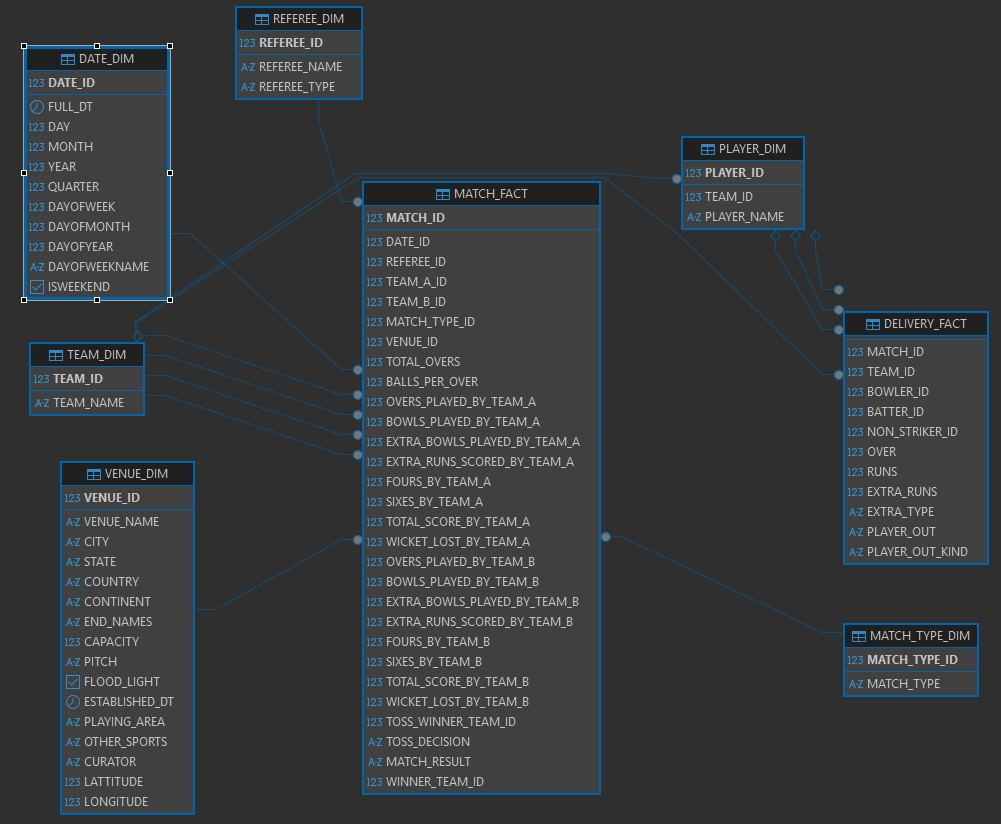